# **Importing Data**, **Libraries** & **Inital Checks**

In [1]:
pip install kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 13.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import os, time
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix)
import xgboost as xgb
from sklearn.inspection import permutation_importance
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")
RND = 42
np.random.seed(RND)

# Optional: SHAP for XGBoost explanations (install if needed)
try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

In [3]:
import plotly.io as pio
import plotly.express as px

# Set the default renderer to png for all subsequent plots
pio.renderers.default = "png"

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
TRAIN_PATH = "/content/drive/MyDrive/Colab Notebooks/Final Project/hour_train_final_clean.csv"
TEST_PATH  = "/content/drive/MyDrive/Colab Notebooks/Final Project/hour_test_final_clean.csv"

In [6]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

**Training** Set

In [7]:
train_df

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,...,rolling_std_6h,rolling_mean_12h,rolling_std_12h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h,temp_x_workingday,temp_x_season,temp_x_hour
0,2011,1,0,1,0,6,0,1,0.24,0.2879,...,12.220202,17.166667,16.017699,18.500000,18.213382,47.142857,41.338492,0.0,0.24,0.00
1,2011,1,1,1,0,6,0,1,0.22,0.2727,...,12.893797,15.000000,15.705625,23.538462,25.181393,47.564706,41.275338,0.0,0.22,0.22
2,2011,1,2,1,0,6,0,1,0.22,0.2727,...,15.565989,13.500000,15.146900,28.571429,30.658703,49.476744,44.699185,0.0,0.22,0.44
3,2011,1,3,1,0,6,0,1,0.24,0.2879,...,16.017699,12.888889,14.286746,33.733333,35.672051,51.000000,46.654594,0.0,0.24,0.72
4,2011,1,4,1,0,6,0,1,0.24,0.2879,...,17.197868,13.000000,13.474255,38.500000,39.385276,51.693182,46.839260,0.0,0.24,0.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8401,2011,12,19,1,0,6,0,1,0.42,0.4242,...,50.898592,142.454545,105.204908,137.823529,99.953261,113.752809,84.243192,0.0,0.42,7.98
8402,2011,12,20,1,0,6,0,1,0.42,0.4242,...,32.676699,125.400000,93.503654,145.250000,98.268001,113.795455,84.724999,0.0,0.42,8.40
8403,2011,12,21,1,0,6,0,1,0.40,0.4091,...,26.738861,106.000000,74.844840,151.666667,98.186169,112.609195,84.477926,0.0,0.40,8.40
8404,2011,12,22,1,0,6,0,1,0.38,0.3939,...,24.913852,87.625000,54.121391,156.071429,100.342846,111.720930,84.563746,0.0,0.38,8.36


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               8406 non-null   int64  
 1   month              8406 non-null   int64  
 2   hour               8406 non-null   int64  
 3   season             8406 non-null   int64  
 4   holiday            8406 non-null   int64  
 5   weekday            8406 non-null   int64  
 6   workingday         8406 non-null   int64  
 7   weathersit         8406 non-null   int64  
 8   temp               8406 non-null   float64
 9   atemp              8406 non-null   float64
 10  hum                8406 non-null   float64
 11  windspeed          8406 non-null   float64
 12  cnt                8406 non-null   int64  
 13  hour_sin           8406 non-null   float64
 14  hour_cos           8406 non-null   float64
 15  month_sin          8406 non-null   float64
 16  month_cos          8406 

**Testing** Set

In [9]:
test_df

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,...,rolling_std_6h,rolling_mean_12h,rolling_std_12h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h,temp_x_workingday,temp_x_season,temp_x_hour
0,2012,1,0,1,0,0,0,1,0.36,0.3788,...,22.649503,46.833333,35.244385,46.000000,42.396398,95.642857,91.841881,0.00,0.36,0.00
1,2012,1,1,1,0,0,0,1,0.36,0.3485,...,21.023796,40.428571,36.363247,57.923077,59.124814,95.929412,91.331785,0.00,0.36,0.36
2,2012,1,2,1,0,0,0,1,0.32,0.3485,...,32.057760,36.250000,35.680127,69.714286,71.925633,96.186047,90.824137,0.00,0.32,0.64
3,2012,1,3,1,0,0,0,1,0.30,0.3333,...,35.244385,33.777778,34.189830,82.866667,86.014838,96.425287,90.322115,0.00,0.30,0.90
4,2012,1,4,1,0,0,0,1,0.28,0.3030,...,39.665686,34.400000,32.294478,94.250000,94.755475,96.681818,89.833760,0.00,0.28,1.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8444,2012,12,19,1,0,1,1,2,0.26,0.2576,...,48.216180,152.090909,84.187237,153.647059,72.246056,99.438202,77.971288,0.26,0.26,4.94
8445,2012,12,20,1,0,1,1,2,0.26,0.2576,...,35.624430,147.000000,86.938037,157.937500,72.344056,99.295455,78.406421,0.26,0.26,5.20
8446,2012,12,21,1,0,1,1,1,0.26,0.2576,...,29.568001,135.888889,84.345190,155.400000,74.142527,97.689655,77.391832,0.26,0.26,5.46
8447,2012,12,22,1,0,1,1,1,0.26,0.2727,...,27.437201,113.500000,54.539632,155.285714,76.939965,96.604651,77.177302,0.26,0.26,5.72


In [10]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8449 entries, 0 to 8448
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               8449 non-null   int64  
 1   month              8449 non-null   int64  
 2   hour               8449 non-null   int64  
 3   season             8449 non-null   int64  
 4   holiday            8449 non-null   int64  
 5   weekday            8449 non-null   int64  
 6   workingday         8449 non-null   int64  
 7   weathersit         8449 non-null   int64  
 8   temp               8449 non-null   float64
 9   atemp              8449 non-null   float64
 10  hum                8449 non-null   float64
 11  windspeed          8449 non-null   float64
 12  cnt                8449 non-null   int64  
 13  hour_sin           8449 non-null   float64
 14  hour_cos           8449 non-null   float64
 15  month_sin          8449 non-null   float64
 16  month_cos          8449 



---



* **Changing the Data Type** of Each Variable   

In [11]:
categorical_cols = ['year', 'month', 'hour', 'season', 'holiday', 'weekday', 'workingday', 'weathersit']

for col in categorical_cols:
    if col in train_df.columns:
        train_df[col] = train_df[col].astype('category')
    if col in test_df.columns:
        test_df[col] = test_df[col].astype('category')

print("Data types after conversion for train_df:\n")
display(train_df.info())
print("\n\nData types after conversion for test_df:\n")
display(test_df.info())

Data types after conversion for train_df:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   year               8406 non-null   category
 1   month              8406 non-null   category
 2   hour               8406 non-null   category
 3   season             8406 non-null   category
 4   holiday            8406 non-null   category
 5   weekday            8406 non-null   category
 6   workingday         8406 non-null   category
 7   weathersit         8406 non-null   category
 8   temp               8406 non-null   float64 
 9   atemp              8406 non-null   float64 
 10  hum                8406 non-null   float64 
 11  windspeed          8406 non-null   float64 
 12  cnt                8406 non-null   int64   
 13  hour_sin           8406 non-null   float64 
 14  hour_cos           8406 non-null   float64 
 15  month_sin   

None



Data types after conversion for test_df:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8449 entries, 0 to 8448
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   year               8449 non-null   category
 1   month              8449 non-null   category
 2   hour               8449 non-null   category
 3   season             8449 non-null   category
 4   holiday            8449 non-null   category
 5   weekday            8449 non-null   category
 6   workingday         8449 non-null   category
 7   weathersit         8449 non-null   category
 8   temp               8449 non-null   float64 
 9   atemp              8449 non-null   float64 
 10  hum                8449 non-null   float64 
 11  windspeed          8449 non-null   float64 
 12  cnt                8449 non-null   int64   
 13  hour_sin           8449 non-null   float64 
 14  hour_cos           8449 non-null   float64 
 15  month_sin  

None



---



# **Advanced Analysis**

* **Part 1**: Create **Labeled Supervised Dataset** using **Artificial Contamination**

In [12]:
def inject_multivariate_anomalies(df, spike_frac=0.01, dip_frac=0.01, random_state=RND, feature_injection=True, strength=4.5):
    """Inject target + feature anomalies. strength controls sigma multiplier (e.g., 4.5)."""
    np.random.seed(random_state)
    df = df.copy().reset_index(drop=True)
    n = len(df)
    spike_n = max(1, int(spike_frac * n))
    dip_n   = max(1, int(dip_frac * n))
    all_idx = np.arange(n)
    spike_idx = np.random.choice(all_idx, size=spike_n, replace=False)
    remaining = np.setdiff1d(all_idx, spike_idx)
    dip_idx = np.random.choice(remaining, size=dip_n, replace=False)
    labels = np.zeros(n, dtype=int)

    for i in spike_idx:
        # local stats by hour if available
        if 'hour' in df.columns:
            mask = df['hour'] == df.at[i,'hour']
            mu = df.loc[mask, 'cnt'].mean()
            sigma = df.loc[mask, 'cnt'].std(ddof=0)
        else:
            mu, sigma = df['cnt'].mean(), df['cnt'].std(ddof=0)
        if np.isnan(sigma) or sigma==0: sigma = df['cnt'].std(ddof=0)
        df.at[i,'cnt'] = int(max(df.at[i,'cnt'], mu + np.random.uniform(strength-0.5, strength+0.5) * sigma))
        labels[i] = 1
        if feature_injection:
            if 'temp' in df.columns: df.at[i,'temp'] = min(1.0, df.at[i,'temp'] + np.random.uniform(0.15,0.4))
            if 'hum' in df.columns: df.at[i,'hum'] = max(0.0, df.at[i,'hum'] - np.random.uniform(0.15,0.45))
            if 'windspeed' in df.columns: df.at[i,'windspeed'] = df.at[i,'windspeed'] * np.random.uniform(0.6,0.95)
    for i in dip_idx:
        if 'hour' in df.columns:
            mask = df['hour'] == df.at[i,'hour']
            mu = df.loc[mask, 'cnt'].mean()
            sigma = df.loc[mask, 'cnt'].std(ddof=0)
        else:
            mu, sigma = df['cnt'].mean(), df['cnt'].std(ddof=0)
        if np.isnan(sigma) or sigma==0: sigma = df['cnt'].std(ddof=0)
        df.at[i,'cnt'] = int(max(0, mu - np.random.uniform(strength-0.5, strength+0.5) * sigma))
        labels[i] = 1
        if feature_injection:
            if 'temp' in df.columns: df.at[i,'temp'] = max(0.0, df.at[i,'temp'] - np.random.uniform(0.15,0.45))
            if 'hum' in df.columns: df.at[i,'hum'] = min(1.0, df.at[i,'hum'] + np.random.uniform(0.15,0.45))
            if 'windspeed' in df.columns: df.at[i,'windspeed'] = df.at[i,'windspeed'] * np.random.uniform(1.2,2.5)

    df['anomaly_label'] = labels

    return df

# time-aware holdout: use last 10% of train as validation
train_sorted = train_df.sort_index().reset_index(drop=True)
n_holdout = max(1, int(0.10 * len(train_sorted)))
train_core = train_sorted.iloc[:-n_holdout].reset_index(drop=True)
train_holdout = train_sorted.iloc[-n_holdout:].reset_index(drop=True)

# Build supervised training set: add a small fraction of anomalies into train_core
train_supervised = inject_multivariate_anomalies(train_core, spike_frac=0.015, dip_frac=0.015, random_state=RND+1, strength=4.0)

# Convert to category after summing for print statement
train_supervised['anomaly_label'] = train_supervised['anomaly_label'].astype('category')
print("Train supervised anomalies (approx):", train_supervised['anomaly_label'].astype(int).sum())

# Contaminate validation and test (for tuning & final eval)
val_contaminated = inject_multivariate_anomalies(train_holdout, spike_frac=0.02, dip_frac=0.02, random_state=RND+2, strength=4.5)
test_contaminated = inject_multivariate_anomalies(test_df, spike_frac=0.02, dip_frac=0.02, random_state=RND+3, strength=4.5)

# Convert to category after summing for print statement
val_contaminated['anomaly_label'] = val_contaminated['anomaly_label'].astype('category')
test_contaminated['anomaly_label'] = test_contaminated['anomaly_label'].astype('category')

print("Val anomalies:", val_contaminated['anomaly_label'].astype(int).sum(), "Test anomalies:", test_contaminated['anomaly_label'].astype(int).sum())

Train supervised anomalies (approx): 226
Val anomalies: 32 Test anomalies: 336




---



* **Part 2**: Check the Distribution of **anomaly_label**

In [13]:
train_supervised

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,...,rolling_mean_12h,rolling_std_12h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h,temp_x_workingday,temp_x_season,temp_x_hour,anomaly_label
0,2011,1,0,1,0,6,0,1,0.24,0.2879,...,17.166667,16.017699,18.500000,18.213382,47.142857,41.338492,0.00,0.24,0.00,0
1,2011,1,1,1,0,6,0,1,0.22,0.2727,...,15.000000,15.705625,23.538462,25.181393,47.564706,41.275338,0.00,0.22,0.22,0
2,2011,1,2,1,0,6,0,1,0.22,0.2727,...,13.500000,15.146900,28.571429,30.658703,49.476744,44.699185,0.00,0.22,0.44,0
3,2011,1,3,1,0,6,0,1,0.24,0.2879,...,12.888889,14.286746,33.733333,35.672051,51.000000,46.654594,0.00,0.24,0.72,0
4,2011,1,4,1,0,6,0,1,0.24,0.2879,...,13.000000,13.474255,38.500000,39.385276,51.693182,46.839260,0.00,0.24,0.96,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7561,2011,11,16,4,0,5,1,1,0.50,0.4848,...,201.416667,78.719823,118.875000,102.178153,117.571429,103.918702,0.50,2.00,8.00,0
7562,2011,11,17,4,0,5,1,1,0.50,0.4848,...,194.416667,87.705559,118.750000,102.322699,117.672619,103.816657,0.50,2.00,8.50,0
7563,2011,11,18,4,0,5,1,1,0.46,0.4545,...,178.333333,98.427946,118.666667,102.420135,118.083333,103.564115,0.46,1.84,8.28,0
7564,2011,11,19,4,0,5,1,1,0.42,0.4242,...,159.583333,100.374262,118.541667,102.556444,119.666667,104.941082,0.42,1.68,7.98,0


In [14]:
train_supervised.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7566 entries, 0 to 7565
Data columns (total 42 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   year               7566 non-null   category
 1   month              7566 non-null   category
 2   hour               7566 non-null   category
 3   season             7566 non-null   category
 4   holiday            7566 non-null   category
 5   weekday            7566 non-null   category
 6   workingday         7566 non-null   category
 7   weathersit         7566 non-null   category
 8   temp               7566 non-null   float64 
 9   atemp              7566 non-null   float64 
 10  hum                7566 non-null   float64 
 11  windspeed          7566 non-null   float64 
 12  cnt                7566 non-null   int64   
 13  hour_sin           7566 non-null   float64 
 14  hour_cos           7566 non-null   float64 
 15  month_sin          7566 non-null   float64 
 16  month_

In [15]:
test_contaminated

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,...,rolling_mean_12h,rolling_std_12h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h,temp_x_workingday,temp_x_season,temp_x_hour,anomaly_label
0,2012,1,0,1,0,0,0,1,0.36,0.3788,...,46.833333,35.244385,46.000000,42.396398,95.642857,91.841881,0.00,0.36,0.00,0
1,2012,1,1,1,0,0,0,1,0.36,0.3485,...,40.428571,36.363247,57.923077,59.124814,95.929412,91.331785,0.00,0.36,0.36,0
2,2012,1,2,1,0,0,0,1,0.32,0.3485,...,36.250000,35.680127,69.714286,71.925633,96.186047,90.824137,0.00,0.32,0.64,0
3,2012,1,3,1,0,0,0,1,0.30,0.3333,...,33.777778,34.189830,82.866667,86.014838,96.425287,90.322115,0.00,0.30,0.90,0
4,2012,1,4,1,0,0,0,1,0.28,0.3030,...,34.400000,32.294478,94.250000,94.755475,96.681818,89.833760,0.00,0.28,1.12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8444,2012,12,19,1,0,1,1,2,0.26,0.2576,...,152.090909,84.187237,153.647059,72.246056,99.438202,77.971288,0.26,0.26,4.94,0
8445,2012,12,20,1,0,1,1,2,0.26,0.2576,...,147.000000,86.938037,157.937500,72.344056,99.295455,78.406421,0.26,0.26,5.20,0
8446,2012,12,21,1,0,1,1,1,0.26,0.2576,...,135.888889,84.345190,155.400000,74.142527,97.689655,77.391832,0.26,0.26,5.46,0
8447,2012,12,22,1,0,1,1,1,0.26,0.2727,...,113.500000,54.539632,155.285714,76.939965,96.604651,77.177302,0.26,0.26,5.72,0


In [16]:
val_contaminated

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,...,rolling_mean_12h,rolling_std_12h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h,temp_x_workingday,temp_x_season,temp_x_hour,anomaly_label
0,2011,11,21,4,0,5,1,1,0.36,0.3788,...,117.666667,94.184860,117.208333,103.554640,119.750000,105.670528,0.36,1.44,7.56,0
1,2011,11,22,4,0,5,1,1,0.34,0.3485,...,93.250000,76.018090,116.708333,103.695406,118.553571,105.472746,0.34,1.36,7.48,0
2,2011,11,23,4,0,5,1,1,0.34,0.3485,...,71.833333,58.688443,116.666667,103.685002,117.815476,105.790361,0.34,1.36,7.82,0
3,2011,11,0,4,0,6,0,1,0.34,0.3485,...,56.750000,49.830850,116.833333,103.871437,117.160714,106.066996,0.00,1.36,0.00,0
4,2011,11,1,4,0,6,0,1,0.32,0.3333,...,44.833333,41.045060,118.375000,106.515487,116.327381,106.262386,0.00,1.28,0.32,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,2011,12,19,1,0,6,0,1,0.42,0.4242,...,142.454545,105.204908,137.823529,99.953261,113.752809,84.243192,0.00,0.42,7.98,0
836,2011,12,20,1,0,6,0,1,0.42,0.4242,...,125.400000,93.503654,145.250000,98.268001,113.795455,84.724999,0.00,0.42,8.40,0
837,2011,12,21,1,0,6,0,1,0.40,0.4091,...,106.000000,74.844840,151.666667,98.186169,112.609195,84.477926,0.00,0.40,8.40,0
838,2011,12,22,1,0,6,0,1,0.38,0.3939,...,87.625000,54.121391,156.071429,100.342846,111.720930,84.563746,0.00,0.38,8.36,0




---



Pie Chart of **Anomaly Type**

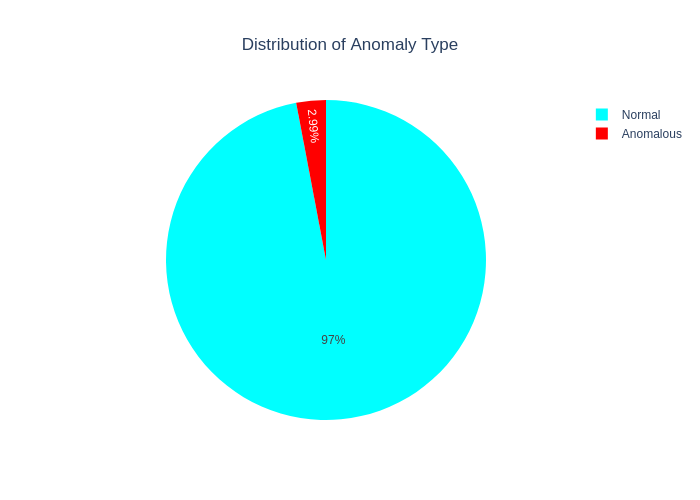

In [17]:
# Counts
anomalyCounts = train_supervised['anomaly_label'].value_counts().reset_index()
anomalyCounts.columns = ['anomaly_label', 'Count']

# Map numerical labels to descriptive strings
label_map = {0: 'Normal', 1: 'Anomalous'}
anomalyCounts['anomaly_label_str'] = anomalyCounts['anomaly_label'].map(label_map)

# Plot
fig14 = px.pie(
    anomalyCounts,
    names='anomaly_label_str',
    values='Count',
    title='Distribution of Anomaly Type',
    labels={'anomaly_label_str': 'Anomaly Type', 'Count': 'No. of Bikes'},
    color='anomaly_label_str',
    color_discrete_map={'Normal': 'cyan', 'Anomalous': 'red'}
)

fig14.update_layout(
    title_x=0.5
)

fig14.show()



---



* **Part 3**: Applying **SMOTENC** (Synthetic Minority Over-sampling Technique for Nominal and Continuous)

In [18]:
from imblearn.over_sampling import SMOTENC

# Exclude target and label
exclude_cols = ['cnt', 'anomaly_label']
feature_cols = [c for c in train_supervised.columns if c not in exclude_cols and train_supervised[c].dtype in ['category', np.float64, np.float32, np.int32, np.int64]]
print("Feature columns used:", len(feature_cols), feature_cols[:20])

# Removed .fillna(0) as per error and info() output
X_train = train_supervised[feature_cols].copy()
y_train = train_supervised['anomaly_label'].astype(int).values
X_val   = val_contaminated[feature_cols].copy()
y_val   = val_contaminated['anomaly_label'].astype(int).values
X_test  = test_contaminated[feature_cols].copy()
y_test  = test_contaminated['anomaly_label'].astype(int).values

categorical_cols_smote = [col for col in feature_cols if train_supervised[col].dtype == 'category']
quantitative_cols_smote = [col for col in feature_cols if col not in categorical_cols_smote]

# Prepare data for SMOTENC using the X_train and y_train from the previous step
X_train_df_smote = pd.DataFrame(X_train, columns=feature_cols)
y_train_smote = y_train

# Get column indices of categorical columns in X_train_df_smote
categorical_indices_smote = [X_train_df_smote.columns.get_loc(col) for col in categorical_cols_smote]

# Apply SMOTENC to balance the training data
print("Original training data shape:", X_train_df_smote.shape, y_train_smote.shape)
print("Original training data anomaly label distribution:\n", pd.Series(y_train_smote).value_counts())

if len(np.unique(y_train_smote)) > 1: # Check if there are at least two classes to balance
    smote_nc = SMOTENC(categorical_features=categorical_indices_smote, random_state=42)
    X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train_df_smote, y_train_smote)

    # Convert resampled data back to DataFrame/Series (optional but good practice)
    X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=feature_cols)
    y_train_resampled_series = pd.Series(y_train_resampled, name='anomaly_label')

    print("\nResampled training data shape:", X_train_resampled_df.shape, y_train_resampled_series.shape)
    print("Resampled training data anomaly label distribution:\n", y_train_resampled_series.value_counts())
else:
    print("\nSMOTENC not applied: Only one class found in y_train.")
    X_train_resampled_df = X_train_df_smote
    y_train_resampled_series = pd.Series(y_train_smote, name='anomaly_label')

Feature columns used: 40 ['year', 'month', 'hour', 'season', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'lag_1h', 'lag_2h']
Original training data shape: (7566, 40) (7566,)
Original training data anomaly label distribution:
 0    7340
1     226
Name: count, dtype: int64

Resampled training data shape: (14680, 40) (14680,)
Resampled training data anomaly label distribution:
 anomaly_label
0    7340
1    7340
Name: count, dtype: int64




---



* **Part 4**: Check the Distribution of **anomaly_label** After Applying SMOTENC

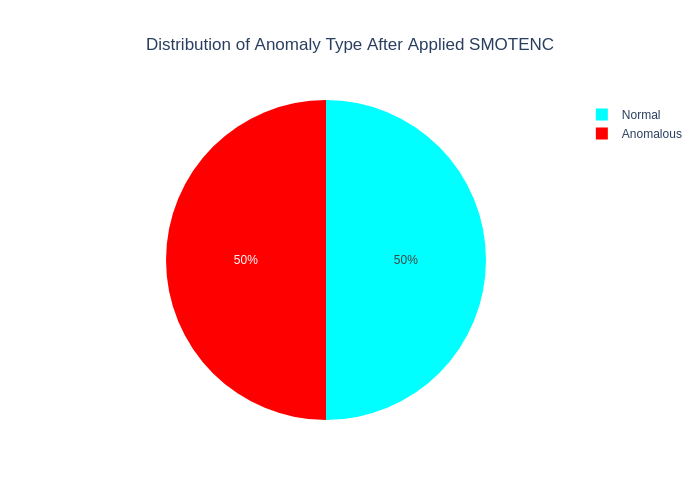

In [19]:
# Counts
anomalyCounts = y_train_resampled_series.value_counts().reset_index()
anomalyCounts.columns = ['anomaly_label', 'Count']

# Map numerical labels to descriptive strings
label_map = {0: 'Normal', 1: 'Anomalous'}
anomalyCounts['anomaly_label_str'] = anomalyCounts['anomaly_label'].map(label_map)

# Plot
fig14 = px.pie(
    anomalyCounts,
    names='anomaly_label_str',
    values='Count',
    title='Distribution of Anomaly Type After Applied SMOTENC',
    labels={'anomaly_label_str': 'Anomaly Type', 'Count': 'No. of Bikes'},
    color='anomaly_label_str', # Explicitly set color based on the mapped column
    color_discrete_map={'Normal': 'cyan', 'Anomalous': 'red'}
)

fig14.update_layout(
    title_x=0.5
)

fig14.show()

* **Part 5**: Preprocessing for Advanced Analysis

In [20]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTENC

# Identify categorical columns for encoding - now looking for 'category' dtype
categorical_cols = [col for col in X_train_resampled_df.columns if X_train_resampled_df[col].dtype == 'category']

# Standardize numeric features (important for Logistic) - Fit on resampled training data
scaler = StandardScaler()
# Separate numerical columns for scaling
numerical_cols = [col for col in X_train_resampled_df.columns if col not in categorical_cols]

X_train_resampled_s = X_train_resampled_df.copy()
X_val_s = X_val.copy()
X_test_s = X_test.copy()

if numerical_cols: # Only scale if there are numerical columns
    X_train_resampled_s[numerical_cols] = scaler.fit_transform(X_train_resampled_s[numerical_cols])
    X_val_s[numerical_cols] = scaler.transform(X_val_s[numerical_cols])
    X_test_s[numerical_cols] = scaler.transform(X_test_s[numerical_cols])


# One-hot encode training data for linear models - Use resampled data
X_train_resampled_encoded = pd.get_dummies(X_train_resampled_s, columns=categorical_cols, dummy_na=False)
X_val_encoded = pd.get_dummies(X_val_s, columns=categorical_cols, dummy_na=False)
X_test_encoded = pd.get_dummies(X_test_s, columns=categorical_cols, dummy_na=False)

# Reindex test and validation columns to match training columns after encoding
X_val_encoded = X_val_encoded.reindex(columns=X_train_resampled_encoded.columns, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=X_train_resampled_encoded.columns, fill_value=0)


# Ordinal encode for tree-based models - Use resampled data for fitting
class RobustOrdinalEncoder:
    def __init__(self):
        self.encoders = {}
        self.categories = {}

    def fit(self, X, cols):
        for col in cols:
            # Handle potential NaN values or unseen categories gracefully
            unique_values = [v for v in X[col].unique() if pd.notna(v)]
            self.categories[col] = unique_values
            value_to_int = {v: i for i, v in enumerate(unique_values)}
            self.encoders[col] = value_to_int
        return self

    def transform(self, X, cols):
        X_transformed = X.copy()
        for col in cols:
            # Convert to object type before mapping and filling to avoid TypeError
            X_transformed[col] = X[col].astype('object').map(self.encoders.get(col, {})).fillna(-1).astype(int)
        return X_transformed

ordinal_encoder = RobustOrdinalEncoder().fit(X_train_resampled_df, categorical_cols) # Fit on resampled data
X_train_resampled_ordinal = ordinal_encoder.transform(X_train_resampled_df, categorical_cols) # Transform resampled data
X_val_ordinal = ordinal_encoder.transform(X_val, categorical_cols) # Transform validation data
X_test_ordinal = ordinal_encoder.transform(X_test, categorical_cols) # Transform test data


# Target variable: already handled as integer by .astype(int) earlier
y_train_processed = y_train_resampled_series.values # Use resampled target values
y_val_processed = y_val # Use original validation target values
y_test_processed = y_test # Use original test target values


# A helper for metrics
def compute_metrics(y_true, y_pred, y_score=None):
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    acc  = accuracy_score(y_true, y_pred)
    # Check if there is more than one class before computing AUC and AUPR
    if len(np.unique(y_true)) > 1:
        auc_roc = roc_auc_score(y_true, y_score) if y_score is not None else np.nan
        prec_r, rec_r, _ = precision_recall_curve(y_true, y_score) if y_score is not None else (None,None,None)
        aupr = auc(rec_r, prec_r) if (prec_r is not None) else np.nan
    else:
        auc_roc = np.nan
        aupr = np.nan

    return {'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1, 'auc_roc':auc_roc, 'aupr':aupr}

# Plotly helpers
def plot_confusion_matrix(y_true, y_pred, title):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    z = [[tn, fp],[fn, tp]]
    annotations = [[f"TN\n{tn}", f"FP\n{fp}"], [f"FN\n{fn}", f"TP\n{tp}"]]
    fig = go.Figure(data=go.Heatmap(z=z, x=['Pred Normal','Pred Anom'], y=['True Normal','True Anom'],
                                    text=annotations, texttemplate="%{text}", colorscale='Blues'))
    fig.update_layout(title=title, height=450)
    fig.show()

def plot_roc_pr_curves(y_train, score_train, y_test, score_test, model_name):
    # Check if there is more than one class in both train and test before plotting
    if len(np.unique(y_train)) > 1 and len(np.unique(y_test)) > 1:
        # ROC
        fpr_tr, tpr_tr, _ = roc_curve(y_train, score_train)
        fpr_te, tpr_te, _ = roc_curve(y_test, score_test)
        auc_tr = roc_auc_score(y_train, score_train)
        auc_te = roc_auc_score(y_test, score_test)
        # PR
        prec_tr, rec_tr, _ = precision_recall_curve(y_train, score_train)
        prec_te, rec_te, _ = precision_recall_curve(y_test, score_test)
        aupr_tr = auc(rec_tr, prec_tr)
        aupr_te = auc(rec_te, prec_te)

        fig = make_subplots(rows=1, cols=2, subplot_titles=(f"ROC - {model_name} (AUC train:{auc_tr:.3f}, test:{auc_te:.3f})",
                                                            f"PR - {model_name} (AUPR train:{aupr_tr:.3f}, test:{aupr_te:.3f})"))
        fig.add_trace(go.Scatter(x=fpr_tr, y=tpr_tr, name='ROC train'), row=1, col=1)
        fig.add_trace(go.Scatter(x=fpr_te, y=tpr_te, name='ROC test'), row=1, col=1)
        fig.add_trace(go.Scatter(x=rec_tr, y=prec_tr, name='PR train'), row=1, col=2)
        fig.add_trace(go.Scatter(x=rec_te, y=prec_te, name='PR test'), row=1, col=2)
        fig.update_xaxes(title_text='FPR', row=1, col=1)
        fig.update_yaxes(title_text='TPR', row=1, col=1)
        fig.update_xaxes(title_text='Recall', row=1, col=2)
        fig.update_yaxes(title_text='Precision', row=1, col=2)
        fig.update_layout(height=500, width=1000)
        fig.show()
        return {'auc_train':auc_tr, 'auc_test':auc_te, 'aupr_train':aupr_tr, 'aupr_test':aupr_te}
    else:
        print(f"Skipping ROC/PR plots for {model_name}: Only one class present in train or test data.")
        return {'auc_train':np.nan, 'auc_test':np.nan, 'aupr_train':np.nan, 'aupr_test':np.nan}



---



* **Part 6**: Candidate Models & Grids

In [21]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix
import numpy as np
import pandas as pd


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

# Define models with hyperparameter grids
models = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=RND, max_iter=1000),
        'params': {
            'C': [0.1, 1, 10],
            'penalty': ['l2'],
            'solver': ['liblinear']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=RND),
        'params': {
            'max_depth': [3, 5, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'criterion': ['gini']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=RND),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(random_state=RND, eval_metric='mlogloss', use_label_encoder=False),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 4, 5, 6],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 0.9, 1.0]
        }
    }
}

# Container to store results and best estimators
model_results = {}

# 3.1 Logistic Regression
print("\nTuning Logistic Regression ...")
lr = LogisticRegression(class_weight='balanced', random_state=RND, solver='liblinear', max_iter=2000)

# Use the param grid from the models dictionary
lr_gs = GridSearchCV(lr, models['Logistic Regression']['params'], scoring='f1', cv=cv, n_jobs=-1, verbose=0)

# Use one-hot encoded and scaled training data for Logistic Regression
lr_gs.fit(X_train_resampled_encoded, y_train_processed)
best_lr = lr_gs.best_estimator_
print("Best Logistic params:", lr_gs.best_params_, "Best CV F1:", lr_gs.best_score_)

# Predictions & scores
train_pred_lr = best_lr.predict(X_train_resampled_encoded); train_score_lr = best_lr.predict_proba(X_train_resampled_encoded)[:,1]
test_pred_lr  = best_lr.predict(X_test_encoded);  test_score_lr  = best_lr.predict_proba(X_test_encoded)[:,1]
model_results['LogisticRegression'] = {'estimator':best_lr, 'train_pred':train_pred_lr, 'train_score':train_score_lr,
                                      'test_pred':test_pred_lr, 'test_score':test_score_lr, 'best_params':lr_gs.best_params_}


# 3.2 Decision Tree
print("\nTuning Decision Tree ...")
dt = DecisionTreeClassifier(class_weight='balanced', random_state=RND)

# Use the param grid from the models dictionary
dt_gs = GridSearchCV(dt, models['Decision Tree']['params'], scoring='f1', cv=cv, n_jobs=-1)

# Use ordinal encoded training data for Decision Tree
dt_gs.fit(X_train_resampled_ordinal, y_train_processed)
best_dt = dt_gs.best_estimator_
print("Best Tree params:", dt_gs.best_params_, "Best CV F1:", dt_gs.best_score_)

# Predictions & scores
train_pred_dt = best_dt.predict(X_train_resampled_ordinal); train_score_dt = best_dt.predict_proba(X_train_resampled_ordinal)[:,1]
test_pred_dt  = best_dt.predict(X_test_ordinal);  test_score_dt  = best_dt.predict_proba(X_test_ordinal)[:,1]
model_results['DecisionTree'] = {'estimator':best_dt, 'train_pred':train_pred_dt, 'train_score':train_score_dt,
                                'test_pred':test_pred_dt, 'test_score':test_score_dt, 'best_params':dt_gs.best_params_}


# 3.3 Random Forest
print("\nTuning Random Forest ...")
rf = RandomForestClassifier(class_weight='balanced', random_state=RND, n_jobs=-1)

# Use the param grid from the models dictionary
rf_gs = GridSearchCV(rf, models['Random Forest']['params'], scoring='f1', cv=cv, n_jobs=-1)

# Use ordinal encoded training data for Random Forest
rf_gs.fit(X_train_resampled_ordinal, y_train_processed)
best_rf = rf_gs.best_estimator_
print("Best RF params:", rf_gs.best_params_, "Best CV F1:", rf_gs.best_score_)

# Predictions & scores
train_pred_rf = best_rf.predict(X_train_resampled_ordinal); train_score_rf = best_rf.predict_proba(X_train_resampled_ordinal)[:,1]
test_pred_rf  = best_rf.predict(X_test_ordinal);  test_score_rf  = best_rf.predict_proba(X_test_ordinal)[:,1]
model_results['RandomForest'] = {'estimator':best_rf, 'train_pred':train_pred_rf, 'train_score':train_score_rf,
                                'test_pred':test_pred_rf, 'test_score':test_score_rf, 'best_params':rf_gs.best_params_}


# 3.4 XGBoost
print("\nTuning XGBoost ...")
xgb_clf = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=RND, n_jobs=-1)

# Use the param grid from the models dictionary
xgb_gs = GridSearchCV(xgb_clf, models['XGBoost']['params'], scoring='f1', cv=cv, n_jobs=-1)

# Use ordinal encoded training data for XGBoost
xgb_gs.fit(X_train_resampled_ordinal, y_train_processed)
best_xgb = xgb_gs.best_estimator_
print("Best XGBoost params:", xgb_gs.best_params_, "Best CV F1:", xgb_gs.best_score_)

# Predictions & scores
train_pred_xgb = best_xgb.predict(X_train_resampled_ordinal); train_score_xgb = best_xgb.predict_proba(X_train_resampled_ordinal)[:,1]
test_pred_xgb  = best_xgb.predict(X_test_ordinal);  test_score_xgb  = best_xgb.predict_proba(X_test_ordinal)[:,1]
model_results['XGBoost'] = {'estimator':best_xgb, 'train_pred':train_pred_xgb, 'train_score':train_score_xgb,
                           'test_pred':test_pred_xgb, 'test_score':test_score_xgb, 'best_params':xgb_gs.best_params_}


Tuning Logistic Regression ...
Best Logistic params: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'} Best CV F1: 0.7361829899607681

Tuning Decision Tree ...
Best Tree params: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5} Best CV F1: 0.9635179440315887

Tuning Random Forest ...
Best RF params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200} Best CV F1: 0.9905289134370963

Tuning XGBoost ...
Best XGBoost params: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0} Best CV F1: 0.9987724942588926




---



* **Part 7**: Evaluate Each Model (Metrics: Confusion Matrices, ROC Curves, Feature Importance)


---- Results for LogisticRegression ----
Train:  acc:0.735, prec:0.729, rec:0.748, f1:0.739, AUC:0.814, AUPR:0.802
Test:   acc:0.331, prec:0.041, rec:0.702, f1:0.077, AUC:0.512, AUPR:0.045


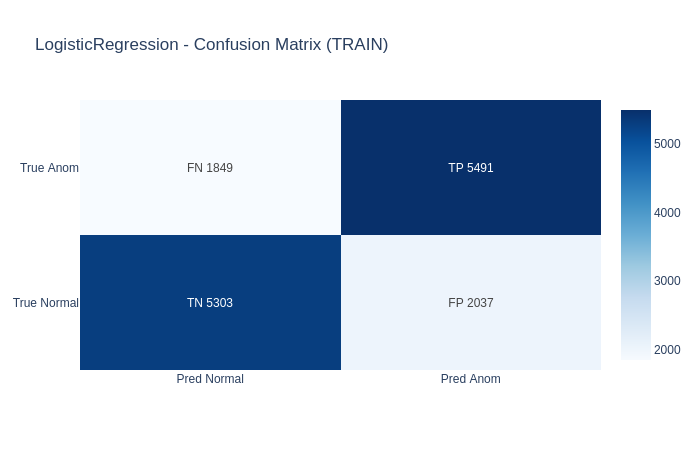

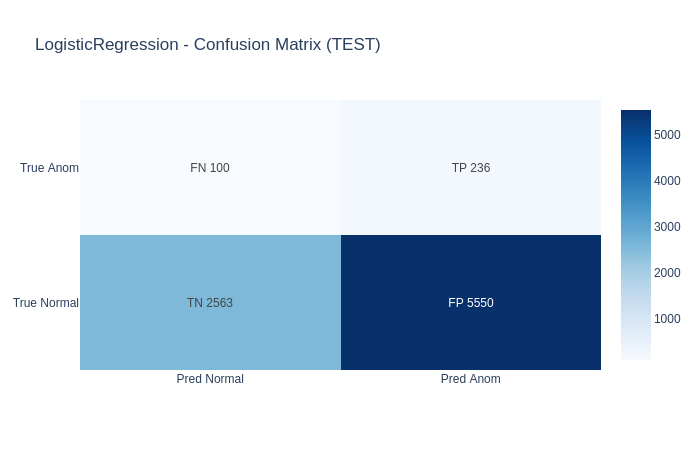

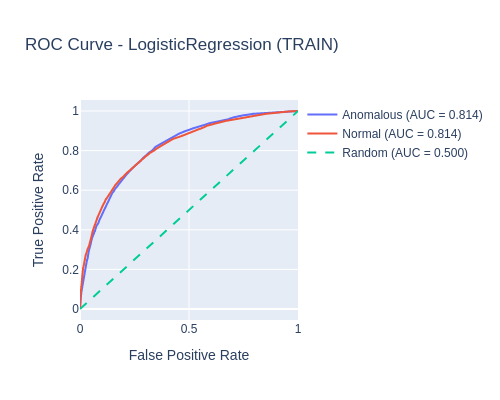

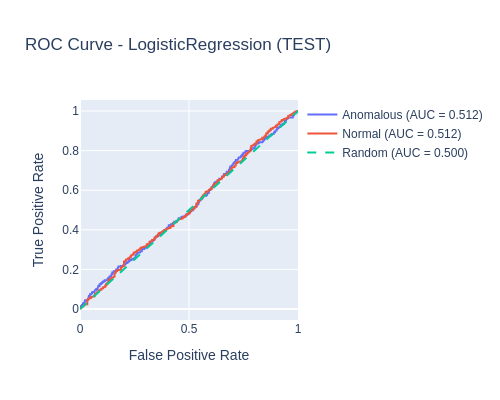

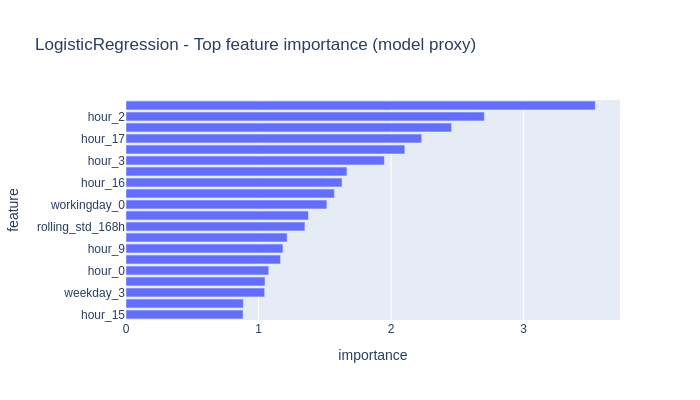


---- Results for DecisionTree ----
Train:  acc:0.981, prec:0.987, rec:0.975, f1:0.981, AUC:0.996, AUPR:0.997
Test:   acc:0.804, prec:0.150, rec:0.839, f1:0.254, AUC:0.822, AUPR:0.504


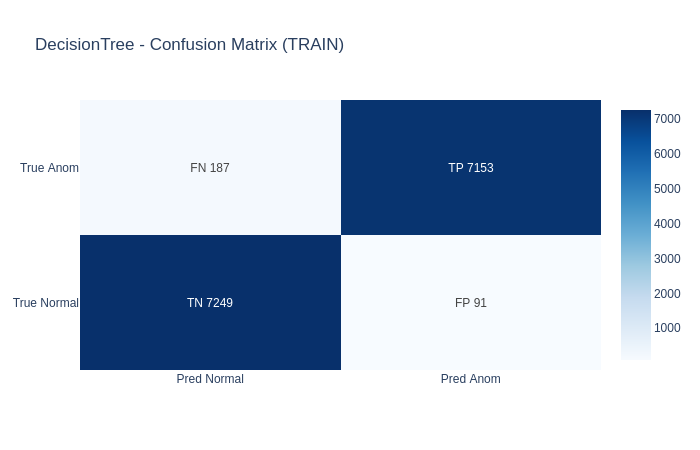

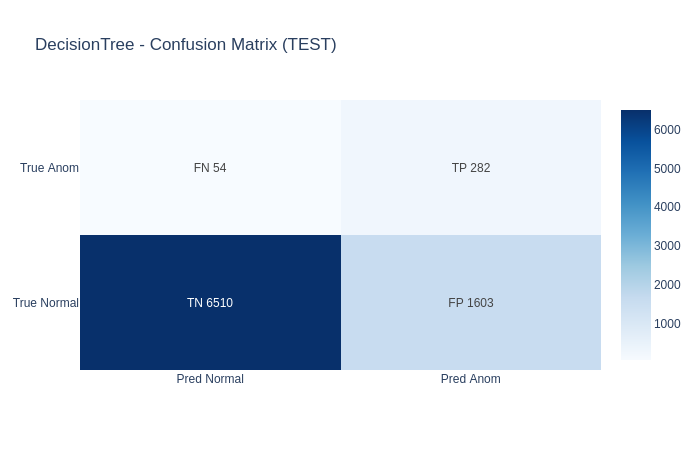

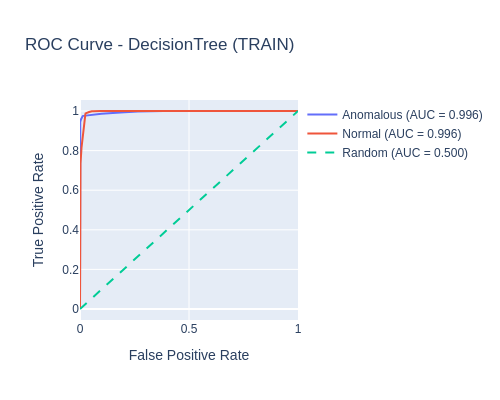

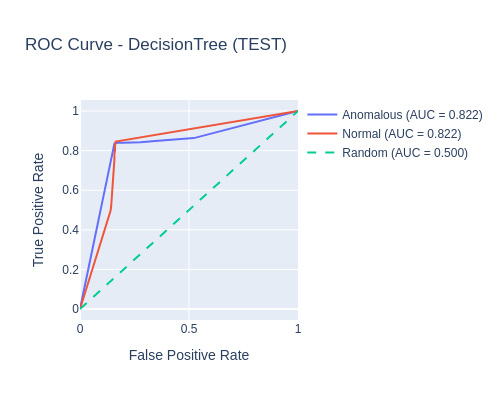

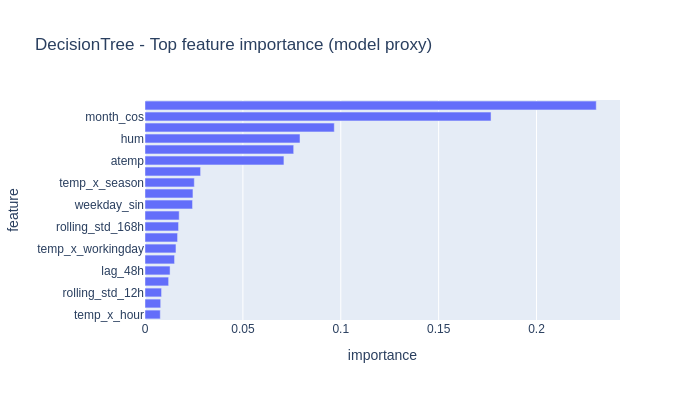


---- Results for RandomForest ----
Train:  acc:0.996, prec:1.000, rec:0.993, f1:0.996, AUC:1.000, AUPR:1.000
Test:   acc:0.973, prec:0.991, rec:0.318, f1:0.482, AUC:0.922, AUPR:0.681


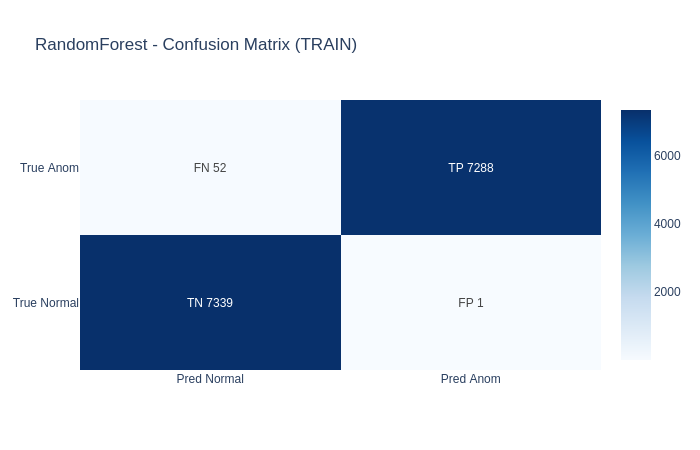

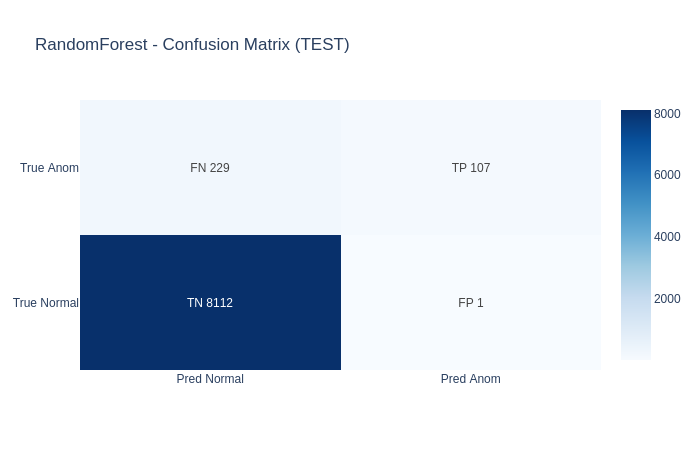

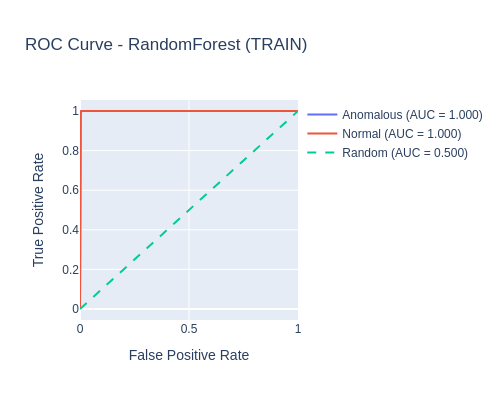

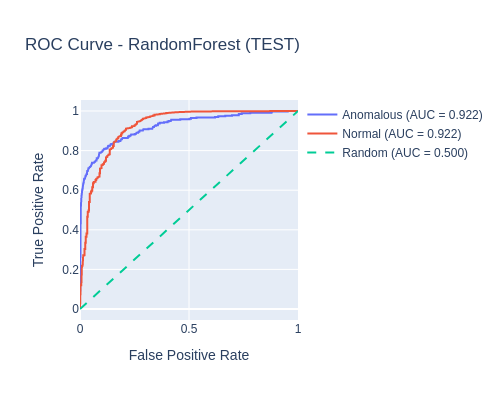

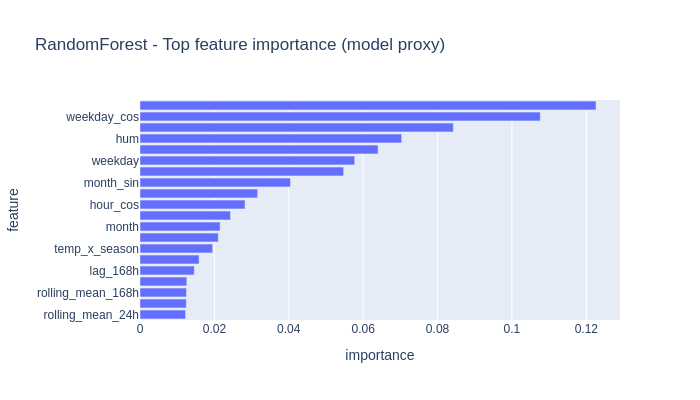


---- Results for XGBoost ----
Train:  acc:1.000, prec:1.000, rec:1.000, f1:1.000, AUC:1.000, AUPR:1.000
Test:   acc:0.991, prec:0.992, rec:0.771, f1:0.868, AUC:0.995, AUPR:0.968


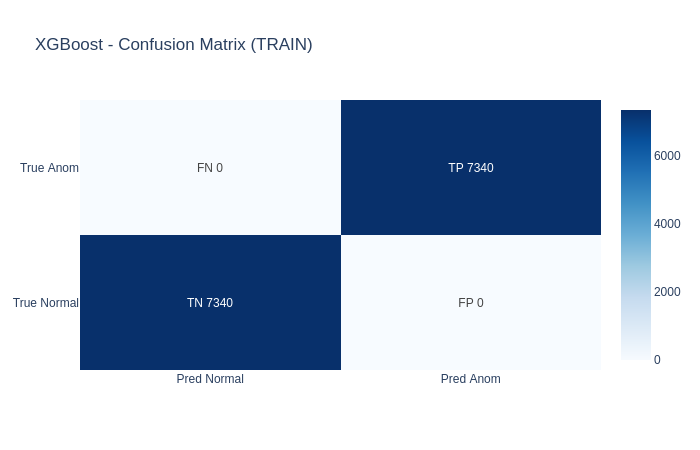

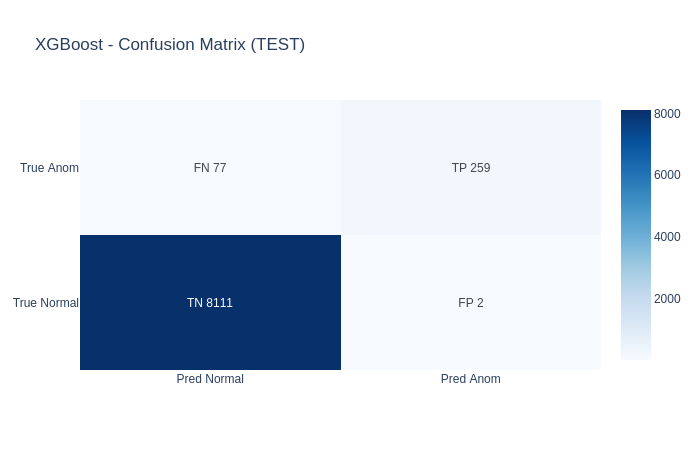

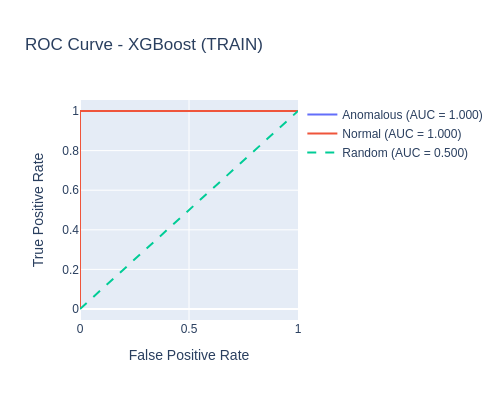

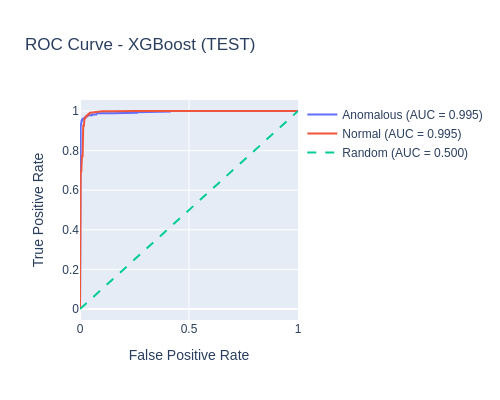

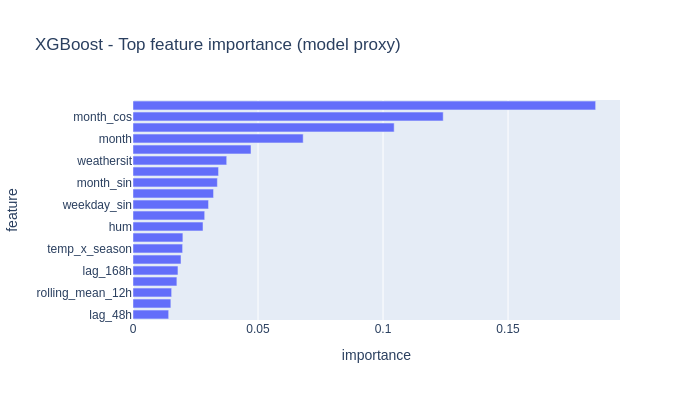


MODEL PERFORMANCE COMPARISON
             Model  Train_Accuracy  Train_Precision  Train_Recall  Train_F1  Train_AUC  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_AUC
LogisticRegression          0.7353           0.7294        0.7481    0.7386     0.8145         0.3313          0.0408       0.7024   0.0771    0.5124
      DecisionTree          0.9811           0.9874        0.9745    0.9809     0.9964         0.8039          0.1496       0.8393   0.2539    0.8215
      RandomForest          0.9964           0.9999        0.9929    0.9964     1.0000         0.9728          0.9907       0.3185   0.4820    0.9215
           XGBoost          1.0000           1.0000        1.0000    1.0000     1.0000         0.9906          0.9923       0.7708   0.8677    0.9949

BEST MODEL: XGBoost
Test Accuracy: 0.9906
Test Precision: 0.9923
Test Recall: 0.7708
Test F1 Score: 0.8677
Test AUC: 0.9949


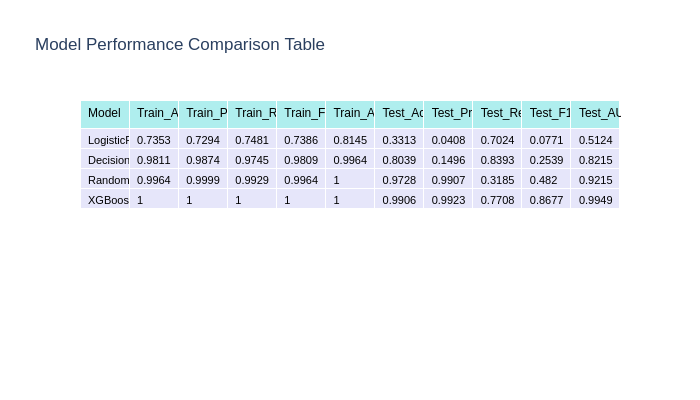

In [22]:
# Get unique classes from the target variable for plotting labels. Use the processed target variable from the training set as it's balanced
classes = sorted(np.unique(y_train_processed))

# Map numerical classes to descriptive labels for plots if needed
class_labels = {0: 'Normal', 1: 'Anomalous'}

def plot_roc_pr_curves(y_train, score_train, y_test, score_test, model_name):
    # Check if there is more than one class in both train and test before plotting
    if len(np.unique(y_train)) > 1 and len(np.unique(y_test)) > 1:
        # ROC Train
        # For Anomalous (class 1) as positive
        fpr_tr_anom, tpr_tr_anom, _ = roc_curve(y_train, score_train, pos_label=1)
        auc_tr_anom = roc_auc_score(y_train, score_train)

        # For Normal (class 0) as positive - need to invert the scores
        fpr_tr_norm, tpr_tr_norm, _ = roc_curve(y_train, 1 - score_train, pos_label=0)
        auc_tr_norm = roc_auc_score(1 - y_train, 1 - score_train)

        fig_roc_train = go.Figure()
        fig_roc_train.add_trace(go.Scatter(x=fpr_tr_anom, y=tpr_tr_anom, mode='lines',
                                          name=f'Anomalous (AUC = {auc_tr_anom:.3f})'))
        fig_roc_train.add_trace(go.Scatter(x=fpr_tr_norm, y=tpr_tr_norm, mode='lines',
                                          name=f'Normal (AUC = {auc_tr_norm:.3f})'))
        fig_roc_train.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines',
                                          name='Random (AUC = 0.500)', line=dict(dash='dash')))
        fig_roc_train.update_layout(title=f"ROC Curve - {model_name} (TRAIN)",
                                    xaxis_title='False Positive Rate',
                                    yaxis_title='True Positive Rate',
                                    showlegend=True, width=500, height=400)
        fig_roc_train.show()

        # ROC Test
        # For Anomalous (class 1) as positive
        fpr_te_anom, tpr_te_anom, _ = roc_curve(y_test, score_test, pos_label=1)
        auc_te_anom = roc_auc_score(y_test, score_test)

        # For Normal (class 0) as positive - need to invert the scores
        fpr_te_norm, tpr_te_norm, _ = roc_curve(y_test, 1 - score_test, pos_label=0)
        auc_te_norm = roc_auc_score(1 - y_test, 1 - score_test)

        fig_roc_test = go.Figure()
        fig_roc_test.add_trace(go.Scatter(x=fpr_te_anom, y=tpr_te_anom, mode='lines',
                                         name=f'Anomalous (AUC = {auc_te_anom:.3f})'))
        fig_roc_test.add_trace(go.Scatter(x=fpr_te_norm, y=tpr_te_norm, mode='lines',
                                         name=f'Normal (AUC = {auc_te_norm:.3f})'))
        fig_roc_test.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines',
                                         name='Random (AUC = 0.500)', line=dict(dash='dash')))
        fig_roc_test.update_layout(title=f"ROC Curve - {model_name} (TEST)",
                                   xaxis_title='False Positive Rate',
                                   yaxis_title='True Positive Rate',
                                   showlegend=True, width=500, height=400)
        fig_roc_test.show()

        return {'auc_train':auc_tr_anom, 'auc_test':auc_te_anom}
    else:
        print(f"Skipping ROC/PR plots for {model_name}: Only one class present in train or test data.")
        return {'auc_train':np.nan, 'auc_test':np.nan}


# Generate plots and metrics for each model
summary_rows = []

# Iterate through the trained models and results stored in model_results
for name, res in model_results.items():
    print(f"\n---- Results for {name} ----")

    # Use the compute_metrics function defined earlier
    tr_metrics = compute_metrics(y_train_processed, res['train_pred'], res['train_score'])
    te_metrics = compute_metrics(y_test_processed, res['test_pred'], res['test_score'])

    print("Train:  acc:{:.3f}, prec:{:.3f}, rec:{:.3f}, f1:{:.3f}, AUC:{:.3f}, AUPR:{:.3f}".format(
        tr_metrics['accuracy'], tr_metrics['precision'], tr_metrics['recall'], tr_metrics['f1'],
        tr_metrics['auc_roc'] if not np.isnan(tr_metrics['auc_roc']) else 0, tr_metrics['aupr'] if not np.isnan(tr_metrics['aupr']) else 0))
    print("Test:   acc:{:.3f}, prec:{:.3f}, rec:{:.3f}, f1:{:.3f}, AUC:{:.3f}, AUPR:{:.3f}".format(
        te_metrics['accuracy'], te_metrics['precision'], te_metrics['recall'], te_metrics['f1'],
        te_metrics['auc_roc'] if not np.isnan(te_metrics['auc_roc']) else 0, te_metrics['aupr'] if not np.isnan(te_metrics['aupr']) else 0))

    # Save summary row
    summary_rows.append({
        'model': name,
        'train_accuracy': tr_metrics['accuracy'],
        'train_precision': tr_metrics['precision'],
        'train_recall': tr_metrics['recall'],
        'train_f1': tr_metrics['f1'],
        'train_auc': tr_metrics['auc_roc'],
        #'train_aupr': tr_metrics['aupr'],
        'test_accuracy': te_metrics['accuracy'],
        'test_precision': te_metrics['precision'],
        'test_recall': te_metrics['recall'],
        'test_f1': te_metrics['f1'],
        'test_auc': te_metrics['auc_roc'],
        #'test_aupr': te_metrics['aupr'],
        #'best_params': res['best_params']
    })

    # Confusion matrices (Plotly) - Using the function defined in K_y5tYYfc9z0
    plot_confusion_matrix(y_train_processed, res['train_pred'], f"{name} - Confusion Matrix (TRAIN)")
    plot_confusion_matrix(y_test_processed, res['test_pred'], f"{name} - Confusion Matrix (TEST)")

    # ROC curves (Plotly) - Using the updated function
    plot_roc_pr_curves(y_train_processed, res['train_score'], y_test_processed, res['test_score'], name)

    # Feature importance:
    # Need to use the correct feature names based on the encoding used for each model
    if name == 'LogisticRegression':
        # use absolute coefficients
        coefs = np.abs(res['estimator'].coef_[0])
        # Use column names from the one-hot encoded data for Logistic Regression
        imp_df = pd.DataFrame({'feature':X_train_resampled_encoded.columns, 'importance':coefs}).sort_values('importance', ascending=False)
    elif name in ['DecisionTree', 'RandomForest', 'XGBoost']:
        # Tree-based models and XGBoost used ordinal encoding (or original features)
        imp = res['estimator'].feature_importances_
        # Use feature_cols from preprocessing step (original feature names)
        imp_df = pd.DataFrame({'feature':feature_cols, 'importance':imp}).sort_values('importance', ascending=False)
    else:
        # Handle other potential models if added later
        imp_df = pd.DataFrame({'feature':feature_cols, 'importance':[0]*len(feature_cols)})

    # Plot top 20 features
    if not imp_df.empty: # Check if importance data is available
        imp_top = imp_df.head(20).iloc[::-1]
        fig = px.bar(imp_top, x='importance', y='feature', orientation='h', title=f"{name} - Top feature importance (model proxy)")
        fig.update_layout(height=max(400, len(imp_top) * 20)); fig.show()
    else:
        print(f"Feature importance plot skipped for {name}: No importance data available.")


# Create comparison DataFrame with formatted column names
comparison_df = pd.DataFrame(summary_rows)

# Rename columns to match the desired format
comparison_df = comparison_df.rename(columns={
    'model': 'Model',
    'train_accuracy': 'Train_Accuracy',
    'train_precision': 'Train_Precision',
    'train_recall': 'Train_Recall',
    'train_f1': 'Train_F1',
    'train_auc': 'Train_AUC',
    #'train_aupr': 'Train_AUPR',
    'test_accuracy': 'Test_Accuracy',
    'test_precision': 'Test_Precision',
    'test_recall': 'Test_Recall',
    'test_f1': 'Test_F1',
    'test_auc': 'Test_AUC',
    #'test_aupr': 'Test_AUPR',
    #'best_params': 'Best_Params'
})

# Select and reorder columns (excluding best_params for cleaner display)
display_cols = ['Model', 'Train_Accuracy', 'Train_Precision', 'Train_Recall', 'Train_F1', 'Train_AUC',
                'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_AUC']
comparison_df_display = comparison_df[display_cols].fillna(value=np.nan)

# Round to 4 decimal places
numeric_cols = [col for col in comparison_df_display.columns if col != 'Model']
comparison_df_display[numeric_cols] = comparison_df_display[numeric_cols].round(4)

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df_display.to_string(index=False))

# Find best model based on test recall
if not comparison_df_display.empty and 'Test_F1' in comparison_df_display.columns:
    best_model_idx = comparison_df_display['Test_F1'].idxmax()
    best_model_name = comparison_df_display.loc[best_model_idx, 'Model']

    print(f"\n" + "="*50)
    print(f"BEST MODEL: {best_model_name}")
    print("="*50)
    print(f"Test Accuracy: {comparison_df_display.loc[best_model_idx, 'Test_Accuracy']:.4f}")
    print(f"Test Precision: {comparison_df_display.loc[best_model_idx, 'Test_Precision']:.4f}")
    print(f"Test Recall: {comparison_df_display.loc[best_model_idx, 'Test_Recall']:.4f}")
    print(f"Test F1 Score: {comparison_df_display.loc[best_model_idx, 'Test_F1']:.4f}")
    print(f"Test AUC: {comparison_df_display.loc[best_model_idx, 'Test_AUC']:.4f}")
else:
    print("\nCould not determine best model: Comparison table is empty or missing 'Test_Recall' column.")

# Display final comparison table as an interactive plot
fig_comparison = go.Figure(data=[go.Table(
    header=dict(values=list(comparison_df_display.columns),
                fill_color='paleturquoise',
                align='left',
                font=dict(size=12, color='black')),
    cells=dict(values=[comparison_df_display[col] for col in comparison_df_display.columns],
               fill_color='lavender',
               align='left',
               font=dict(size=11, color='black'))
)])

fig_comparison.update_layout(
    title="Model Performance Comparison Table",
    height=max(400, len(comparison_df_display) * 40 + 100)
)
fig_comparison.show()



---



* **Part 8**: Selecting Features Covering **90% Importance**

In [23]:
# Get the best performing model (XGBoost from previous analysis)
if 'XGBoost' in model_results:
    best_model = model_results['XGBoost']['estimator']
    # Use the feature names from the data used to train XGBoost
    feature_names = X_train_resampled_ordinal.columns

    # Get feature importances
    importances = best_model.feature_importances_

    # Create a DataFrame and sort
    importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    importance_df = importance_df.sort_values('importance', ascending=False).reset_index(drop=True)

    # Calculate cumulative importance
    importance_df['cumulative_importance'] = importance_df['importance'].cumsum()

    # Select features covering 90% cumulative importance
    selected_features_90 = importance_df[importance_df['cumulative_importance'] <= 0.9]['feature'].tolist()

    print("Features covering 90% cumulative importance (based on XGBoost):")
    print(selected_features_90)

else:
    print("XGBoost model not found in model_results. Cannot select features based on importance.")

Features covering 90% cumulative importance (based on XGBoost):
['weekday_cos', 'month_cos', 'weekday', 'month', 'temp_x_workingday', 'weathersit', 'hour', 'month_sin', 'temp', 'weekday_sin', 'windspeed', 'hum', 'season', 'temp_x_season', 'hour_sin', 'lag_168h', 'hour_cos', 'rolling_mean_12h', 'atemp', 'lag_48h']




---



* **Part 9**: Retrain the **XGBoost** Model with **Selected Features** and **Best Hyperparameters**

Retraining XGBoost with 90% most important features...

---- Results for XGBoost (Reduced Features) ----
Train:  acc:1.000, prec:1.000, rec:1.000, f1:1.000, AUC:1.000, AUPR:1.000
Test:   acc:0.993, prec:0.993, rec:0.842, f1:0.911, AUC:0.999, AUPR:0.988


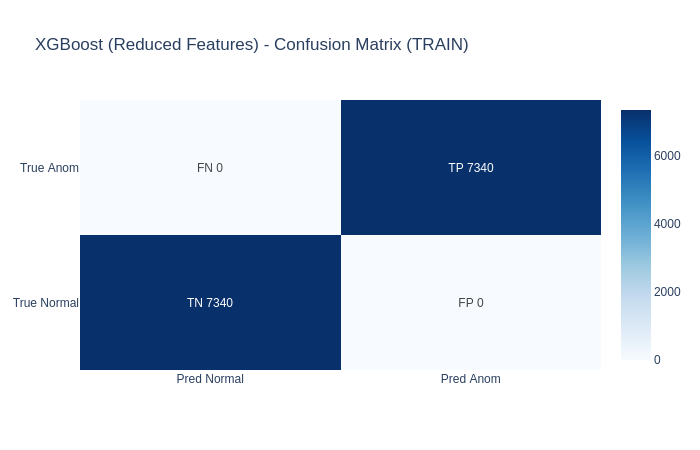

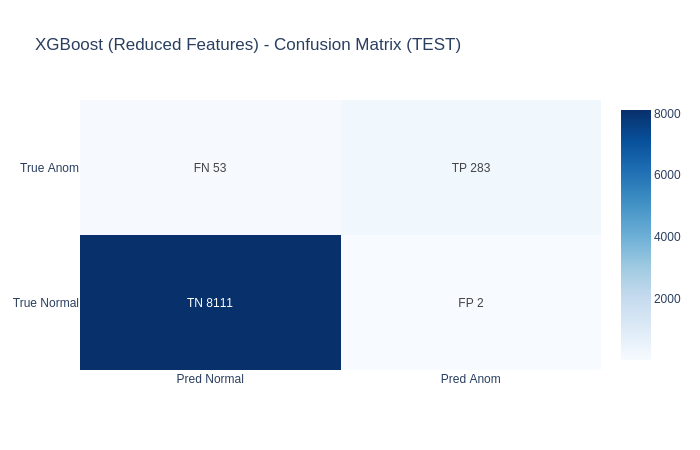

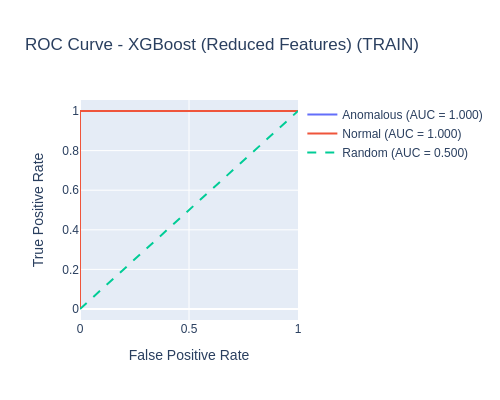

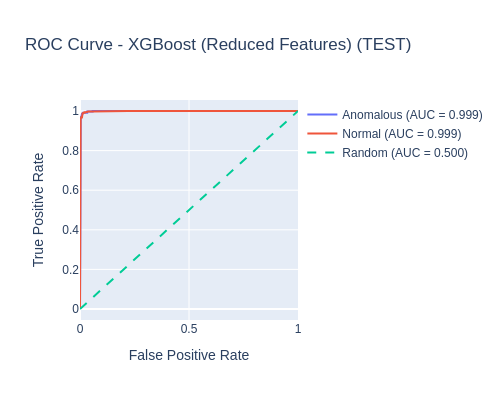

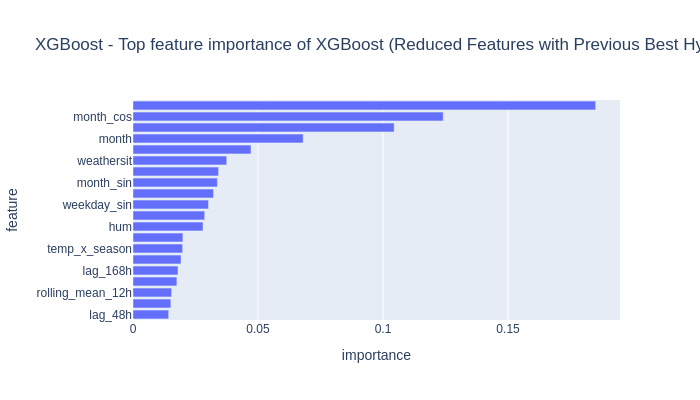


XGBoost Model Comparison (Full vs Reduced Features):


,Model,Num_Features,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Train_AUC,Train_AUPR,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC,Test_AUPR
0,XGBoost (Reduced Features),20,1.0,1.0,1.0,1.0,1.0,1.0,0.9935,0.9930,0.8423,0.9114,0.9993,0.9880
1,XGBoost (Full Features),40,1.0,1.0,1.0,1.0,1.0,1.0,0.9906,0.9923,0.7708,0.8677,0.9949,0.9681


In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np

print("Retraining XGBoost with 90% most important features...")

# Prepare Reduced Feature Data. Use the selected_features_90 from the feature importance analysis
if 'selected_features_90' in locals() and selected_features_90:
    # For tree-based models (using ordinal encoded data)
    X_train_reduced = X_train_resampled_ordinal[selected_features_90]
    X_test_reduced = X_test_ordinal[selected_features_90]

    # Train Reduced Feature XGBoost Model (Use same hyperparameters as best original model)
    if 'XGBoost' in model_results and 'best_params' in model_results['XGBoost']:
        best_params = model_results['XGBoost']['best_params']

        reduced_xgb = XGBClassifier(**best_params, random_state=RND, eval_metric='logloss', use_label_encoder=False, n_jobs=-1) # Use logloss for binary:logistic
        reduced_xgb.fit(X_train_reduced, y_train_processed)

        # Make predictions
        y_train_pred_reduced = reduced_xgb.predict(X_train_reduced)
        y_test_pred_reduced = reduced_xgb.predict(X_test_reduced)
        y_train_proba_reduced = reduced_xgb.predict_proba(X_train_reduced)[:, 1] # Get probability for the positive class (1)
        y_test_proba_reduced = reduced_xgb.predict_proba(X_test_reduced)[:, 1] # Get probability for the positive class (1)

        # Generate Evaluation Metrics and Plots

        print("\n---- Results for XGBoost (Reduced Features) ----")

        # Use the compute_metrics function defined earlier
        tr_metrics_reduced = compute_metrics(y_train_processed, y_train_pred_reduced, y_train_proba_reduced)
        te_metrics_reduced = compute_metrics(y_test_processed, y_test_pred_reduced, y_test_proba_reduced)

        print("Train:  acc:{:.3f}, prec:{:.3f}, rec:{:.3f}, f1:{:.3f}, AUC:{:.3f}, AUPR:{:.3f}".format(
            tr_metrics_reduced['accuracy'], tr_metrics_reduced['precision'], tr_metrics_reduced['recall'], tr_metrics_reduced['f1'],
            tr_metrics_reduced['auc_roc'] if not np.isnan(tr_metrics_reduced['auc_roc']) else 0, tr_metrics_reduced['aupr'] if not np.isnan(tr_metrics_reduced['aupr']) else 0))
        print("Test:   acc:{:.3f}, prec:{:.3f}, rec:{:.3f}, f1:{:.3f}, AUC:{:.3f}, AUPR:{:.3f}".format(
            te_metrics_reduced['accuracy'], te_metrics_reduced['precision'], te_metrics_reduced['recall'], te_metrics_reduced['f1'],
            te_metrics_reduced['auc_roc'] if not np.isnan(te_metrics_reduced['auc_roc']) else 0, te_metrics_reduced['aupr'] if not np.isnan(te_metrics_reduced['aupr']) else 0))

        # Confusion matrices (Plotly)
        plot_confusion_matrix(y_train_processed, y_train_pred_reduced, "XGBoost (Reduced Features) - Confusion Matrix (TRAIN)")
        plot_confusion_matrix(y_test_processed, y_test_pred_reduced, "XGBoost (Reduced Features) - Confusion Matrix (TEST)")

        # ROC & PR curves (Plotly)
        plot_roc_pr_curves(y_train_processed, y_train_proba_reduced, y_test_processed, y_test_proba_reduced, "XGBoost (Reduced Features)")

        # Feature importance:
        # Need to use the correct feature names based on the encoding used for each model
        if name == 'LogisticRegression':
            # use absolute coefficients
            coefs = np.abs(res['estimator'].coef_[0])
            # Use column names from the one-hot encoded data for Logistic Regression
            imp_df = pd.DataFrame({'feature':X_train_resampled_encoded.columns, 'importance':coefs}).sort_values('importance', ascending=False)
        elif name in ['DecisionTree', 'RandomForest', 'XGBoost']:
            # Tree-based models and XGBoost used ordinal encoding (or original features)
            imp = res['estimator'].feature_importances_
            # Use feature_cols from preprocessing step (original feature names)
            imp_df = pd.DataFrame({'feature':feature_cols, 'importance':imp}).sort_values('importance', ascending=False)
        else:
            # Handle other potential models if added later
            imp_df = pd.DataFrame({'feature':feature_cols, 'importance':[0]*len(feature_cols)})

        # Plot top 20 features
        if not imp_df.empty: # Check if importance data is available
            imp_top = imp_df.head(20).iloc[::-1]
            fig = px.bar(imp_top, x='importance', y='feature', orientation='h', title=f"{name} - Top feature importance of XGBoost (Reduced Features with Previous Best Hyperparameters)")
            fig.update_layout(height=max(400, len(imp_top) * 20)); fig.show()
        else:
            print(f"Feature importance plot skipped for {name}: No importance data available.")

        # Create comprehensive comparison table for Full vs Reduced XGBoost
        comparison_rows = []

        # Add Full XGBoost results from model_results
        if 'XGBoost' in model_results:
            full_xgb_results = model_results['XGBoost']
            full_tr_metrics = compute_metrics(y_train_processed, full_xgb_results['train_pred'], full_xgb_results['train_score'])
            full_te_metrics = compute_metrics(y_test_processed, full_xgb_results['test_pred'], full_xgb_results['test_score'])
            comparison_rows.append({
                'Model': 'XGBoost (Full Features)',
                'Train_Accuracy': full_tr_metrics['accuracy'],
                'Train_Precision': full_tr_metrics['precision'],
                'Train_Recall': full_tr_metrics['recall'],
                'Train_F1': full_tr_metrics['f1'],
                'Train_AUC': full_tr_metrics['auc_roc'],
                'Train_AUPR': full_tr_metrics['aupr'],
                'Test_Accuracy': full_te_metrics['accuracy'],
                'Test_Precision': full_te_metrics['precision'],
                'Test_Recall': full_te_metrics['recall'],
                'Test_F1': full_te_metrics['f1'],
                'Test_AUC': full_te_metrics['auc_roc'],
                'Test_AUPR': full_te_metrics['aupr'],
                'Num_Features': X_train_resampled_ordinal.shape[1]
            })

        # Add Reduced XGBoost results
        comparison_rows.append({
            'Model': 'XGBoost (Reduced Features)',
            'Train_Accuracy': tr_metrics_reduced['accuracy'],
            'Train_Precision': tr_metrics_reduced['precision'],
            'Train_Recall': tr_metrics_reduced['recall'],
            'Train_F1': tr_metrics_reduced['f1'],
            'Train_AUC': tr_metrics_reduced['auc_roc'],
            'Train_AUPR': tr_metrics_reduced['aupr'],
            'Test_Accuracy': te_metrics_reduced['accuracy'],
            'Test_Precision': te_metrics_reduced['precision'],
            'Test_Recall': te_metrics_reduced['recall'],
            'Test_F1': te_metrics_reduced['f1'],
            'Test_AUC': te_metrics_reduced['auc_roc'],
            'Test_AUPR': te_metrics_reduced['aupr'],
            'Num_Features': X_train_reduced.shape[1]
        })

        full_comparison = pd.DataFrame(comparison_rows)

        print("\nXGBoost Model Comparison (Full vs Reduced Features):")
        # Select and reorder columns for display
        display_cols = ['Model', 'Num_Features', 'Train_Accuracy', 'Train_Precision', 'Train_Recall', 'Train_F1', 'Train_AUC', 'Train_AUPR',
                        'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_AUC', 'Test_AUPR']
        full_comparison_display = full_comparison[display_cols].fillna(value=np.nan)
        # Round numeric columns
        numeric_cols = [col for col in full_comparison_display.columns if col not in ['Model']]
        full_comparison_display[numeric_cols] = full_comparison_display[numeric_cols].round(4)

        display(full_comparison_display.sort_values('Test_F1', ascending=False).reset_index(drop=True))


    else:
        print("XGBoost model or its best parameters not found in model_results. Cannot retrain with reduced features.")

else:
    print("Selected features list (selected_features_90) not found or is empty. Cannot retrain with reduced features.")



---



* **Part 10**: Retrain the **XGBoost** Model with **Selected Features** and **Previous Hyperparameter Grid**

Performing GridSearchCV for XGBoost on selected 90% important features...
Best XGBoost params (Tuned on Reduced Features): {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8} Best CV F1: 0.9988409631477534

---- Results for XGBoost (Tuned on Reduced Features) ----
Train:  acc:1.000, prec:1.000, rec:1.000, f1:1.000, AUC:1.000, AUPR:1.000
Test:   acc:0.993, prec:1.000, rec:0.836, f1:0.911, AUC:1.000, AUPR:0.990


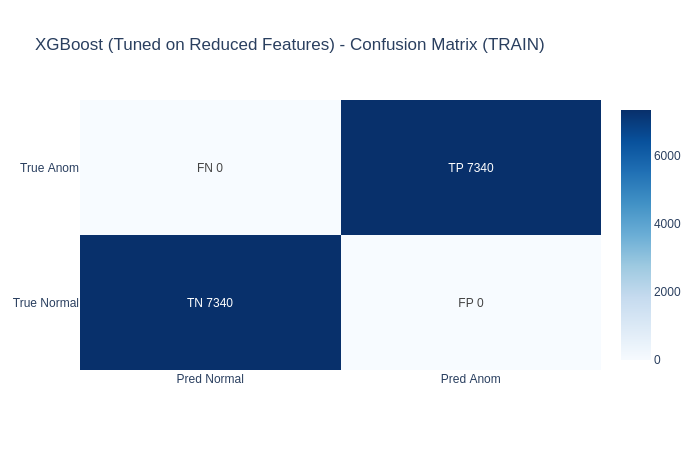

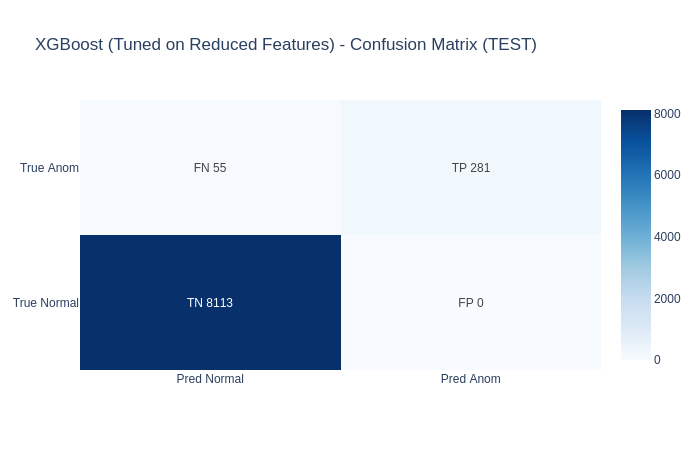

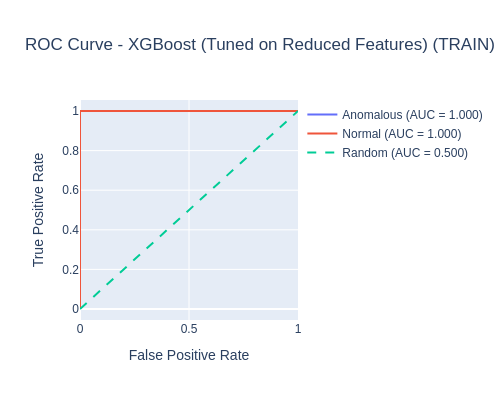

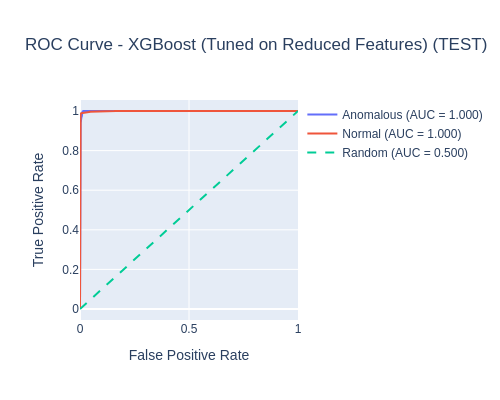

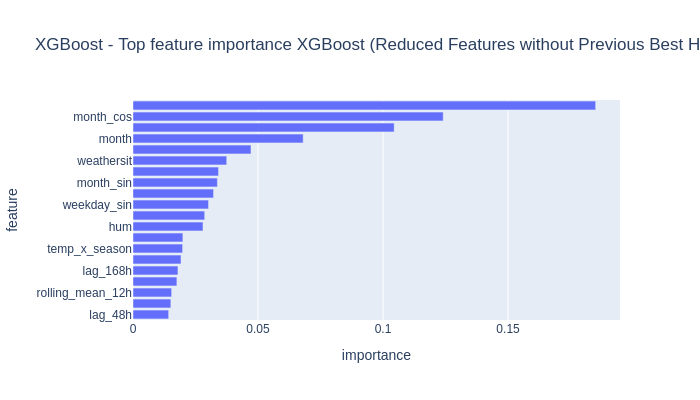


XGBoost Model Comparison (Full vs Reduced Features - Tuned):


,Model,Num_Features,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Train_AUC,Train_AUPR,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC,Test_AUPR
0,XGBoost (Reduced Features - Prev. Best Params),20,1.0,1.0,1.0,1.0,1.0,1.0,0.9935,0.9930,0.8423,0.9114,0.9993,0.9880
1,XGBoost (Reduced Features - Tuned),20,1.0,1.0,1.0,1.0,1.0,1.0,0.9935,1.0000,0.8363,0.9109,0.9995,0.9897
2,XGBoost (Full Features - Tuned),40,1.0,1.0,1.0,1.0,1.0,1.0,0.9906,0.9923,0.7708,0.8677,0.9949,0.9681


In [25]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np

print("Performing GridSearchCV for XGBoost on selected 90% important features...")

# Define CV split for tuning
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

# Get the initial XGBoost hyperparameter grid
if 'models' in locals() and 'XGBoost' in models and 'params' in models['XGBoost']:
    xgb_initial_params = models['XGBoost']['params']

    # Initialize XGBoost classifier for tuning on reduced features
    xgb_clf_tuned_reduced = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=RND, n_jobs=-1)

    # Perform GridSearchCV on the reduced feature set
    xgb_gs_tuned_reduced = GridSearchCV(xgb_clf_tuned_reduced, xgb_initial_params, scoring='f1', cv=cv, n_jobs=-1)

    # Fit GridSearchCV on the reduced training data
    if 'X_train_reduced' in locals() and 'y_train_processed' in locals():
        xgb_gs_tuned_reduced.fit(X_train_reduced, y_train_processed)
        best_xgb_tuned_reduced = xgb_gs_tuned_reduced.best_estimator_

        print("Best XGBoost params (Tuned on Reduced Features):", xgb_gs_tuned_reduced.best_params_, "Best CV F1:", xgb_gs_tuned_reduced.best_score_)

        # Make predictions with the newly tuned model
        y_train_pred_tuned_reduced = best_xgb_tuned_reduced.predict(X_train_reduced)
        y_test_pred_tuned_reduced = best_xgb_tuned_reduced.predict(X_test_reduced)
        y_train_proba_tuned_reduced = best_xgb_tuned_reduced.predict_proba(X_train_reduced)[:, 1]
        y_test_proba_tuned_reduced = best_xgb_tuned_reduced.predict_proba(X_test_reduced)[:, 1]


        # Generate Evaluation Metrics and Plots for the newly tuned model

        print("\n---- Results for XGBoost (Tuned on Reduced Features) ----")

        tr_metrics_tuned_reduced = compute_metrics(y_train_processed, y_train_pred_tuned_reduced, y_train_proba_tuned_reduced)
        te_metrics_tuned_reduced = compute_metrics(y_test_processed, y_test_pred_tuned_reduced, y_test_proba_tuned_reduced)

        print("Train:  acc:{:.3f}, prec:{:.3f}, rec:{:.3f}, f1:{:.3f}, AUC:{:.3f}, AUPR:{:.3f}".format(
            tr_metrics_tuned_reduced['accuracy'], tr_metrics_tuned_reduced['precision'], tr_metrics_tuned_reduced['recall'], tr_metrics_tuned_reduced['f1'],
            tr_metrics_tuned_reduced['auc_roc'] if not np.isnan(tr_metrics_tuned_reduced['auc_roc']) else 0, tr_metrics_tuned_reduced['aupr'] if not np.isnan(tr_metrics_tuned_reduced['aupr']) else 0))
        print("Test:   acc:{:.3f}, prec:{:.3f}, rec:{:.3f}, f1:{:.3f}, AUC:{:.3f}, AUPR:{:.3f}".format(
            te_metrics_tuned_reduced['accuracy'], te_metrics_tuned_reduced['precision'], te_metrics_tuned_reduced['recall'], te_metrics_tuned_reduced['f1'],
            te_metrics_tuned_reduced['auc_roc'] if not np.isnan(te_metrics_tuned_reduced['auc_roc']) else 0, te_metrics_tuned_reduced['aupr'] if not np.isnan(te_metrics_tuned_reduced['aupr']) else 0))


        # Confusion matrices (Plotly)
        plot_confusion_matrix(y_train_processed, y_train_pred_tuned_reduced, "XGBoost (Tuned on Reduced Features) - Confusion Matrix (TRAIN)")
        plot_confusion_matrix(y_test_processed, y_test_pred_tuned_reduced, "XGBoost (Tuned on Reduced Features) - Confusion Matrix (TEST)")

        # ROC & PR curves (Plotly)
        plot_roc_pr_curves(y_train_processed, y_train_proba_tuned_reduced, y_test_processed, y_test_proba_tuned_reduced, "XGBoost (Tuned on Reduced Features)")

        # Feature importance:
        # Need to use the correct feature names based on the encoding used for each model
        if name == 'LogisticRegression':
            # use absolute coefficients
            coefs = np.abs(res['estimator'].coef_[0])
            # Use column names from the one-hot encoded data for Logistic Regression
            imp_df = pd.DataFrame({'feature':X_train_resampled_encoded.columns, 'importance':coefs}).sort_values('importance', ascending=False)
        elif name in ['DecisionTree', 'RandomForest', 'XGBoost']:
            # Tree-based models and XGBoost used ordinal encoding (or original features)
            imp = res['estimator'].feature_importances_
            # Use feature_cols from preprocessing step (original feature names)
            imp_df = pd.DataFrame({'feature':feature_cols, 'importance':imp}).sort_values('importance', ascending=False)
        else:
            # Handle other potential models if added later
            imp_df = pd.DataFrame({'feature':feature_cols, 'importance':[0]*len(feature_cols)})

        # Plot top 20 features
        if not imp_df.empty: # Check if importance data is available
            imp_top = imp_df.head(20).iloc[::-1]
            fig = px.bar(imp_top, x='importance', y='feature', orientation='h', title=f"{name} - Top feature importance XGBoost (Reduced Features without Previous Best Hyperparameters)")
            fig.update_layout(height=max(400, len(imp_top) * 20)); fig.show()
        else:
            print(f"Feature importance plot skipped for {name}: No importance data available.")

        # Create comprehensive comparison table including the new model
        comparison_rows = []

        # Add Full XGBoost results from model_results (tuned on full features)
        if 'XGBoost' in model_results:
            full_xgb_results = model_results['XGBoost']
            full_tr_metrics = compute_metrics(y_train_processed, full_xgb_results['train_pred'], full_xgb_results['train_score'])
            full_te_metrics = compute_metrics(y_test_processed, full_xgb_results['test_pred'], full_xgb_results['test_score'])
            comparison_rows.append({
                'Model': 'XGBoost (Full Features - Tuned)',
                'Train_Accuracy': full_tr_metrics['accuracy'],
                'Train_Precision': full_tr_metrics['precision'],
                'Train_Recall': full_tr_metrics['recall'],
                'Train_F1': full_tr_metrics['f1'],
                'Train_AUC': full_tr_metrics['auc_roc'],
                'Train_AUPR': full_tr_metrics['aupr'],
                'Test_Accuracy': full_te_metrics['accuracy'],
                'Test_Precision': full_te_metrics['precision'],
                'Test_Recall': full_te_metrics['recall'],
                'Test_F1': full_te_metrics['f1'],
                'Test_AUC': full_te_metrics['auc_roc'],
                'Test_AUPR': full_te_metrics['aupr'],
                'Num_Features': X_train_resampled_ordinal.shape[1]
            })

        # Add Reduced XGBoost (previously best params) results from tYD1x3II1mLo
        # Assuming tr_metrics_reduced and te_metrics_reduced from the last run of tYD1x3II1mLo are available
        if 'tr_metrics_reduced' in locals() and 'te_metrics_reduced' in locals() and 'X_train_reduced' in locals():
             comparison_rows.append({
                'Model': 'XGBoost (Reduced Features - Prev. Best Params)',
                'Train_Accuracy': tr_metrics_reduced['accuracy'],
                'Train_Precision': tr_metrics_reduced['precision'],
                'Train_Recall': tr_metrics_reduced['recall'],
                'Train_F1': tr_metrics_reduced['f1'],
                'Train_AUC': tr_metrics_reduced['auc_roc'],
                'Train_AUPR': tr_metrics_reduced['aupr'],
                'Test_Accuracy': te_metrics_reduced['accuracy'],
                'Test_Precision': te_metrics_reduced['precision'],
                'Test_Recall': te_metrics_reduced['recall'],
                'Test_F1': te_metrics_reduced['f1'],
                'Test_AUC': te_metrics_reduced['auc_roc'],
                'Test_AUPR': te_metrics_reduced['aupr'],
                'Num_Features': X_train_reduced.shape[1]
            })


        # Add the newly tuned reduced model results
        comparison_rows.append({
            'Model': 'XGBoost (Reduced Features - Tuned)',
            'Train_Accuracy': tr_metrics_tuned_reduced['accuracy'],
            'Train_Precision': tr_metrics_tuned_reduced['precision'],
            'Train_Recall': tr_metrics_tuned_reduced['recall'],
            'Train_F1': tr_metrics_tuned_reduced['f1'],
            'Train_AUC': tr_metrics_tuned_reduced['auc_roc'],
            'Train_AUPR': tr_metrics_tuned_reduced['aupr'],
            'Test_Accuracy': te_metrics_tuned_reduced['accuracy'],
            'Test_Precision': te_metrics_tuned_reduced['precision'],
            'Test_Recall': te_metrics_tuned_reduced['recall'],
            'Test_F1': te_metrics_tuned_reduced['f1'],
            'Test_AUC': te_metrics_tuned_reduced['auc_roc'],
            'Test_AUPR': te_metrics_tuned_reduced['aupr'],
            'Num_Features': X_train_reduced.shape[1]
        })


        full_comparison = pd.DataFrame(comparison_rows)

        print("\nXGBoost Model Comparison (Full vs Reduced Features - Tuned):")
        # Select and reorder columns for display
        display_cols = ['Model', 'Num_Features', 'Train_Accuracy', 'Train_Precision', 'Train_Recall', 'Train_F1', 'Train_AUC', 'Train_AUPR',
                        'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_AUC', 'Test_AUPR']
        full_comparison_display = full_comparison[display_cols].fillna(value=np.nan)
        # Round numeric columns
        numeric_cols = [col for col in full_comparison_display.columns if col not in ['Model']]
        full_comparison_display[numeric_cols] = full_comparison_display[numeric_cols].round(4)

        display(full_comparison_display.sort_values('Test_F1', ascending=False).reset_index(drop=True))

    else:
        print("Training data (X_train_reduced, y_train_processed) not found. Cannot perform tuning.")

else:
    print("Initial XGBoost model parameters not found in 'models' dictionary. Cannot perform tuning on reduced features.")



---



*   **Part 11**: **Best Model** Determination (Focus on **F1-Score** Because F1 Explicitly **Balances catching anomalies** (recall) and **Avoiding False Alarms** (Precision))

In [26]:
# Find the best model among the three XGBoost versions based on Test F1 Score
if 'full_comparison' in locals() and not full_comparison.empty and 'Test_F1' in full_comparison.columns:
    # Find the index of the row with the maximum 'Test_F1'
    best_model_idx = full_comparison['Test_F1'].idxmax()

    # Get the name and metrics of the best model
    best_model_name = full_comparison.loc[best_model_idx, 'Model']
    best_test_accuracy = full_comparison.loc[best_model_idx, 'Test_Accuracy']
    best_test_precision = full_comparison.loc[best_model_idx, 'Test_Precision']
    best_test_recall = full_comparison.loc[best_model_idx, 'Test_Recall']
    best_test_f1 = full_comparison.loc[best_model_idx, 'Test_F1']
    best_test_auc = full_comparison.loc[best_model_idx, 'Test_AUC']
    best_test_aupr = full_comparison.loc[best_model_idx, 'Test_AUPR']
    best_num_features = full_comparison.loc[best_model_idx, 'Num_Features']


    print(f"\n" + "="*50)
    print(f"BEST XGBOOST MODEL (based on Test F1 Score): {best_model_name}")
    print("="*50)
    print(f"Number of Features: {best_num_features}")
    print(f"Test Accuracy: {best_test_accuracy:.4f}")
    print(f"Test Precision: {best_test_precision:.4f}")
    print(f"Test Recall: {best_test_recall:.4f}")
    print(f"Test F1 Score: {best_test_f1:.4f}")
    print(f"Test AUC: {best_test_auc:.4f}")
    print(f"Test AUPR: {best_test_aupr:.4f}")

else:
    print("\nCould not determine best XGBoost model: Comparison table (full_comparison) not found or is empty.")


BEST XGBOOST MODEL (based on Test F1 Score): XGBoost (Reduced Features - Prev. Best Params)
Number of Features: 20
Test Accuracy: 0.9935
Test Precision: 0.9930
Test Recall: 0.8423
Test F1 Score: 0.9114
Test AUC: 0.9993
Test AUPR: 0.9880




---



In [ ]:
!pip install joblib

import joblib

In [ ]:
# Define the base path for saving files
SAVE_PATH_BASE = '/content/drive/MyDrive/Colab Notebooks/Final Project/'

if 'reduced_xgb' in locals():
    model_filename = SAVE_PATH_BASE + 'best_anomaly_detection_xgb_model.joblib'
    try:
        joblib.dump(reduced_xgb, model_filename)
        print(f"Best performing XGBoost model saved as '{model_filename}'")
    except Exception as e:
        print(f"Could not save the XGBoost model to {model_filename}: {e}")
else:
    print("Best performing XGBoost model ('reduced_xgb') not found. Skipping model saving.")

# Save the ordinal encoder if it was used
if 'ordinal_encoder' in locals():
    encoder_filename = SAVE_PATH_BASE + 'ordinal_encoder.joblib'
    try:
        joblib.dump(ordinal_encoder, encoder_filename)
        print(f"Ordinal encoder saved as '{encoder_filename}'")
    except Exception as e:
        print(f"Could not save the ordinal encoder to {encoder_filename}: {e}")
else:
    print("Ordinal encoder not found. Skipping encoder saving.")

# Save the list of selected features if feature selection was performed
if 'selected_features_90' in locals():
    features_filename = SAVE_PATH_BASE + 'selected_features_90_percent.joblib'
    try:
        joblib.dump(selected_features_90, features_filename)
        print(f"Selected features list saved as '{features_filename}'")
    except Exception as e:
        print(f"Could not save the selected features list to {features_filename}: {e}")
else:
    print("Selected features list ('selected_features_90') not found. Skipping features saving.")

Best performing XGBoost model saved as '/content/drive/MyDrive/Colab Notebooks/Final Project/best_anomaly_detection_xgb_model.joblib'
Ordinal encoder saved as '/content/drive/MyDrive/Colab Notebooks/Final Project/ordinal_encoder.joblib'
Selected features list saved as '/content/drive/MyDrive/Colab Notebooks/Final Project/selected_features_90_percent.joblib'




---



**Part 12**: Interpreting the XGBoost with **PDPs** (Partial Dependence Plots)

Generating Partial Dependence Plots (PDPs) for selected features...
Generating PDPs for features: ['weekday_cos', 'month_cos', 'weekday', 'month', 'temp_x_workingday', 'weathersit', 'hour', 'month_sin', 'temp', 'weekday_sin', 'windspeed', 'hum', 'season', 'temp_x_season', 'hour_sin', 'atemp', 'lag_48h']


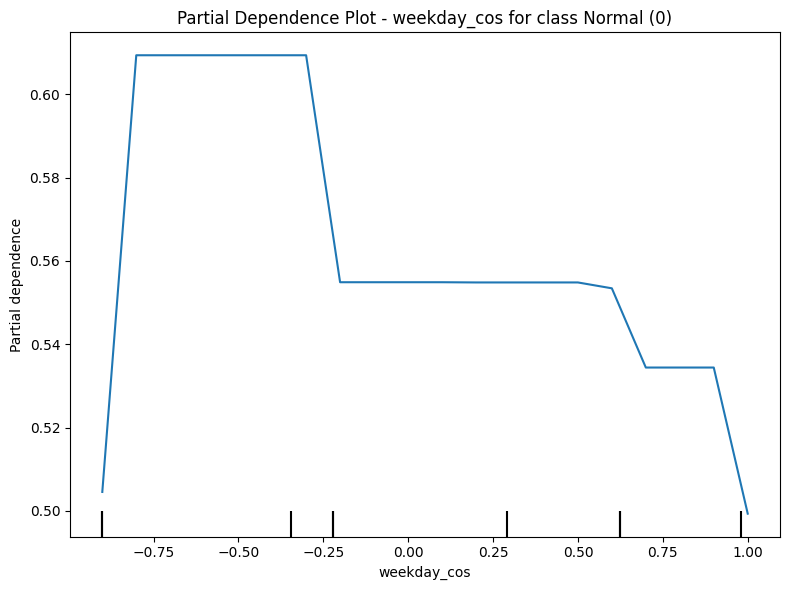

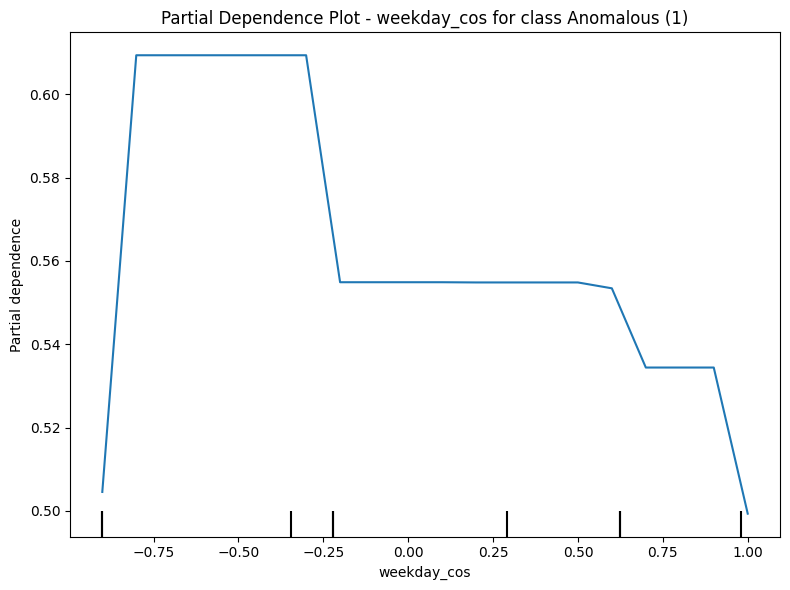

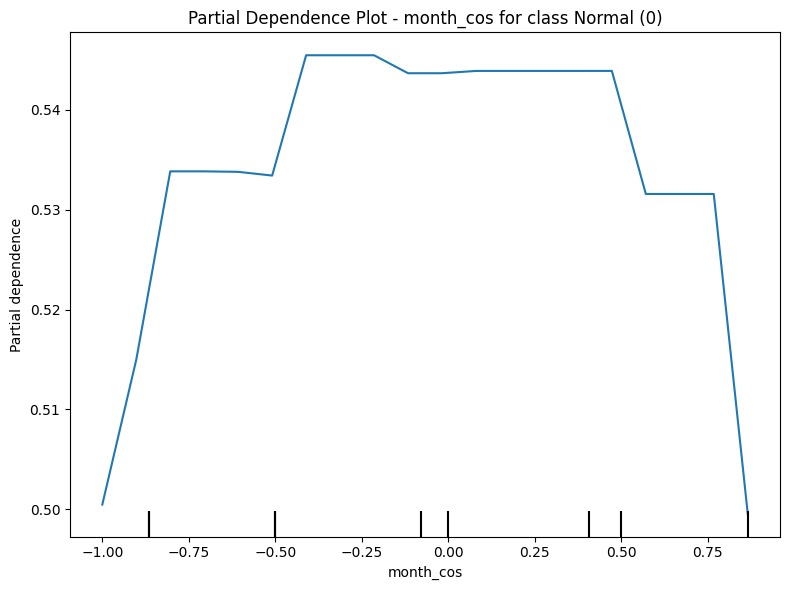

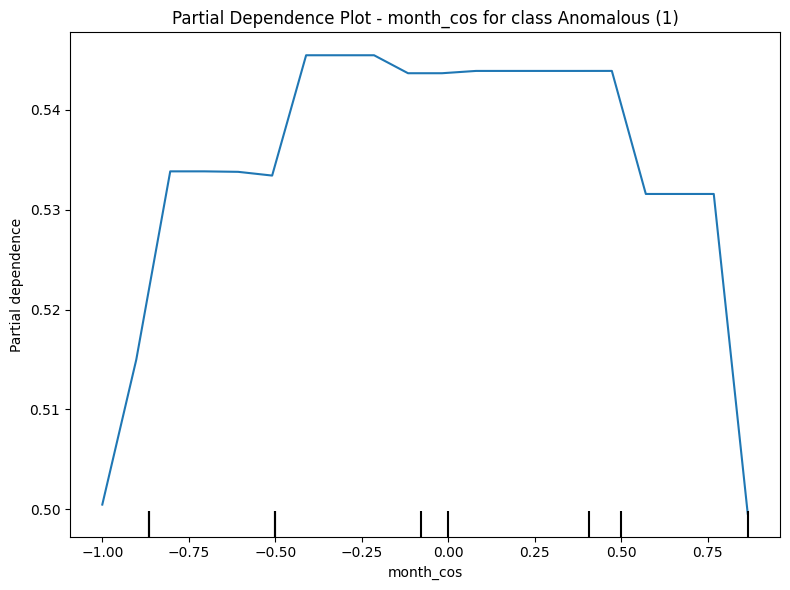

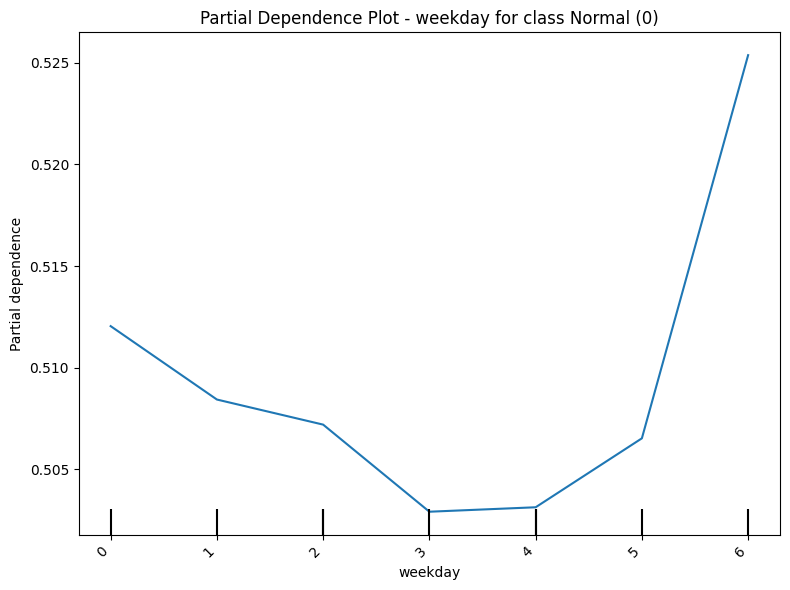

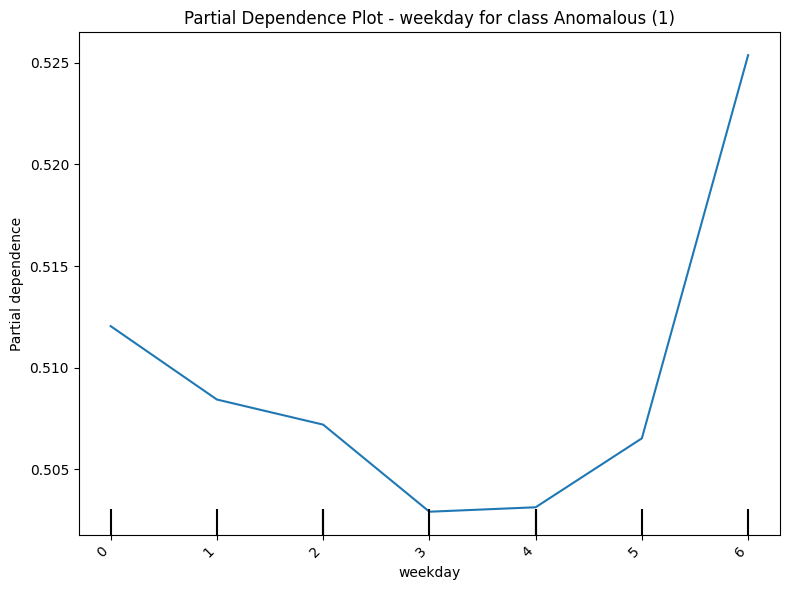

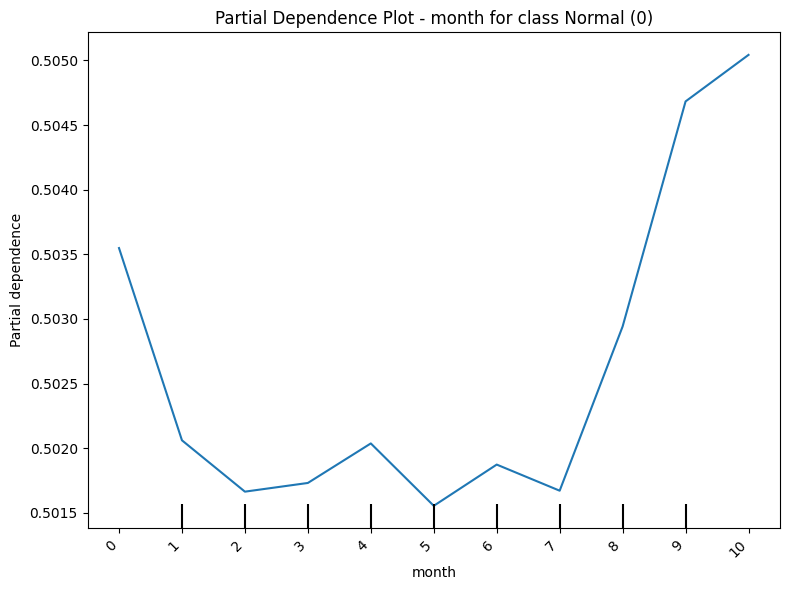

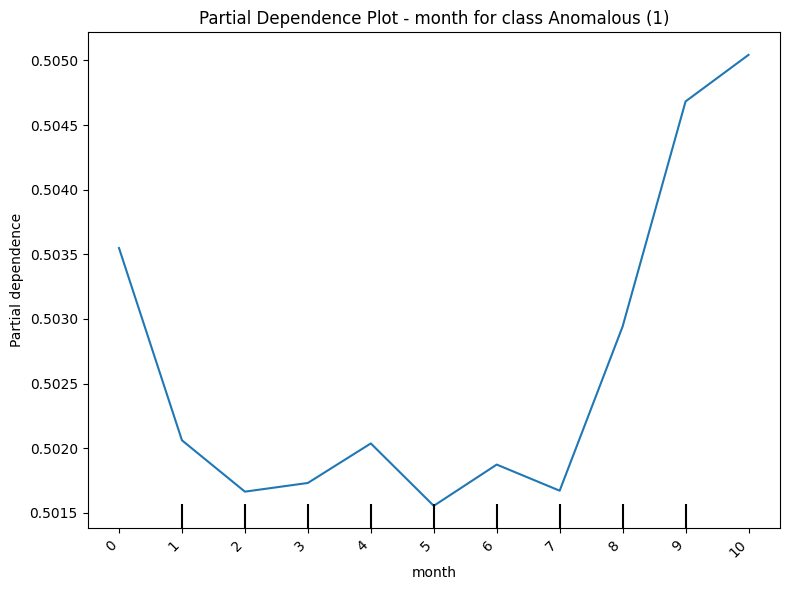

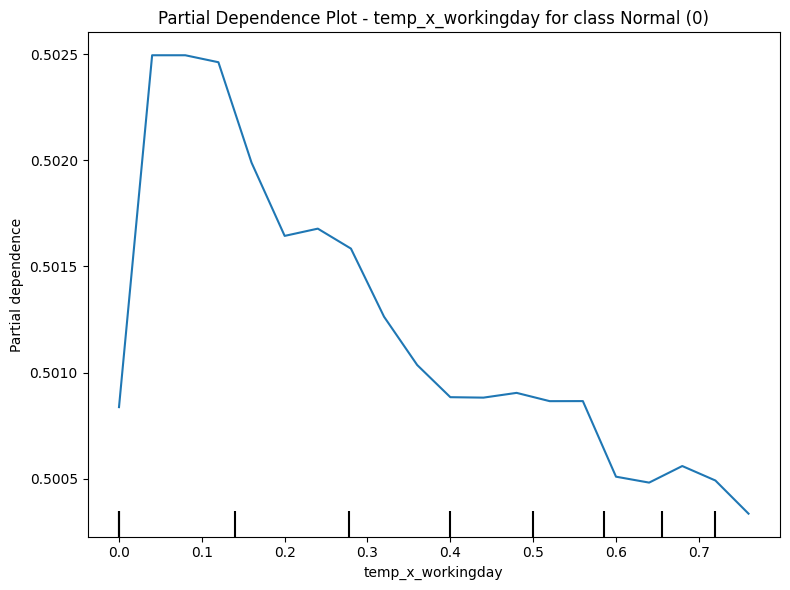

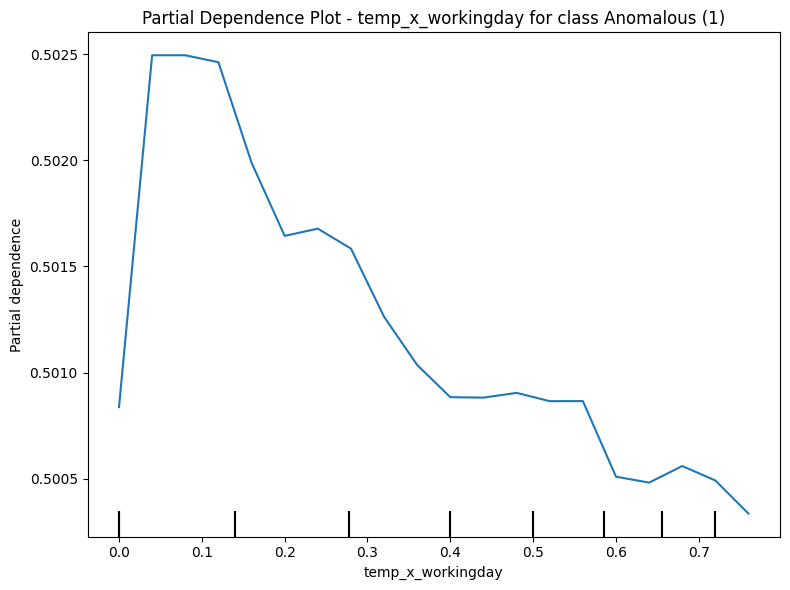

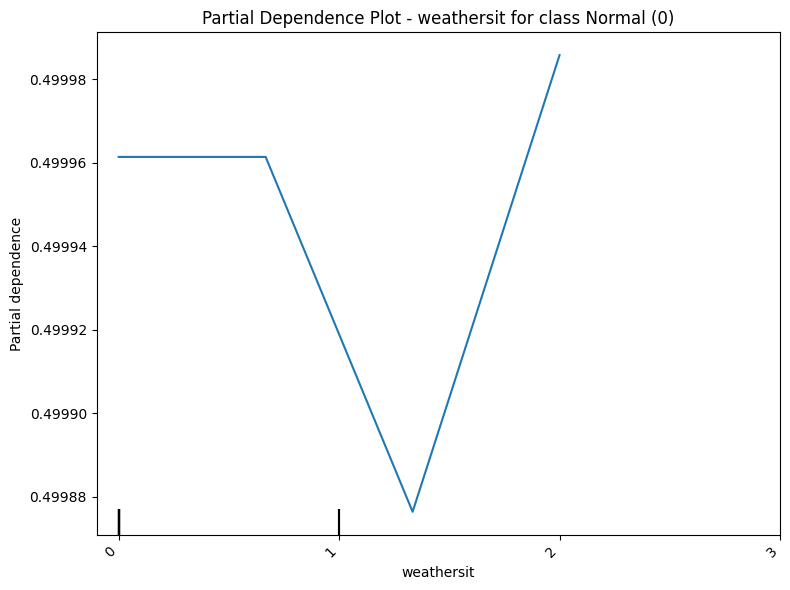

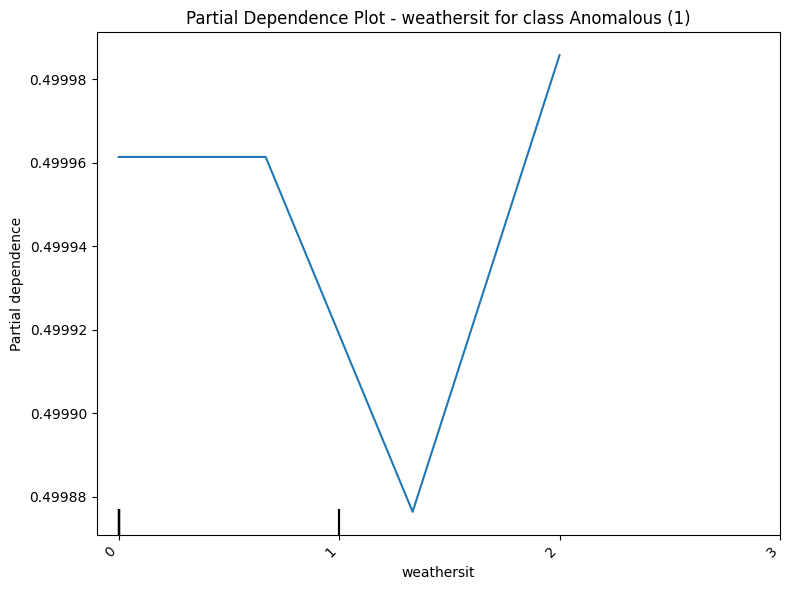

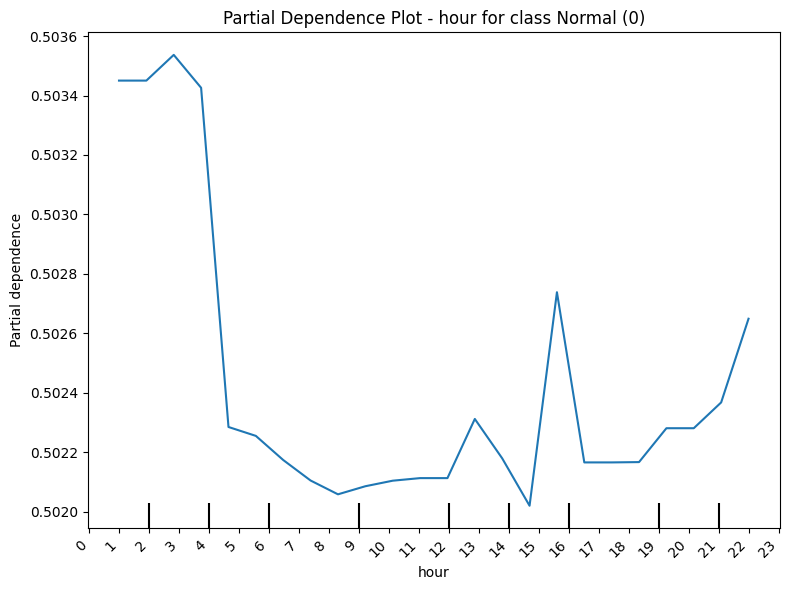

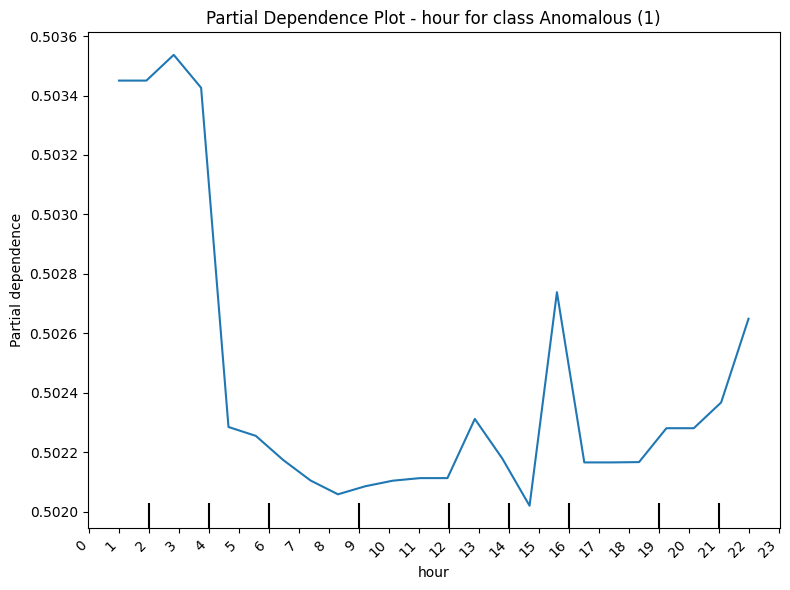

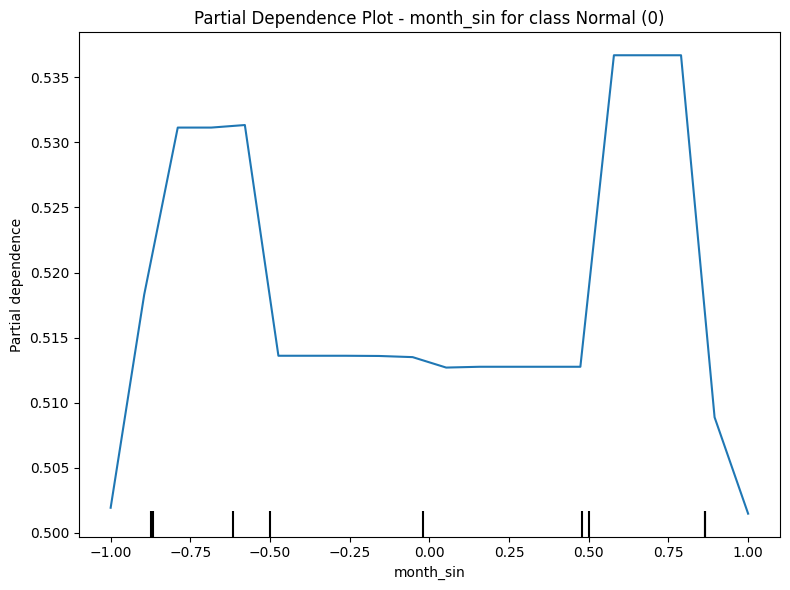

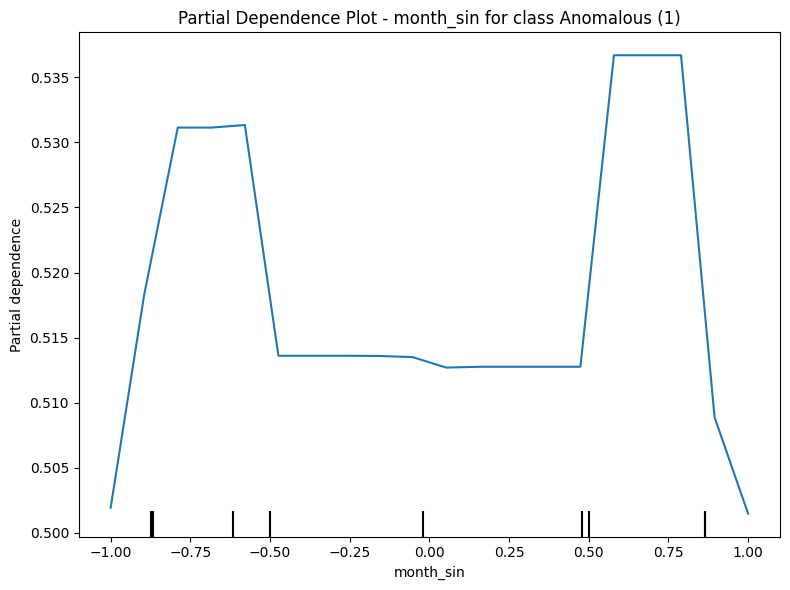

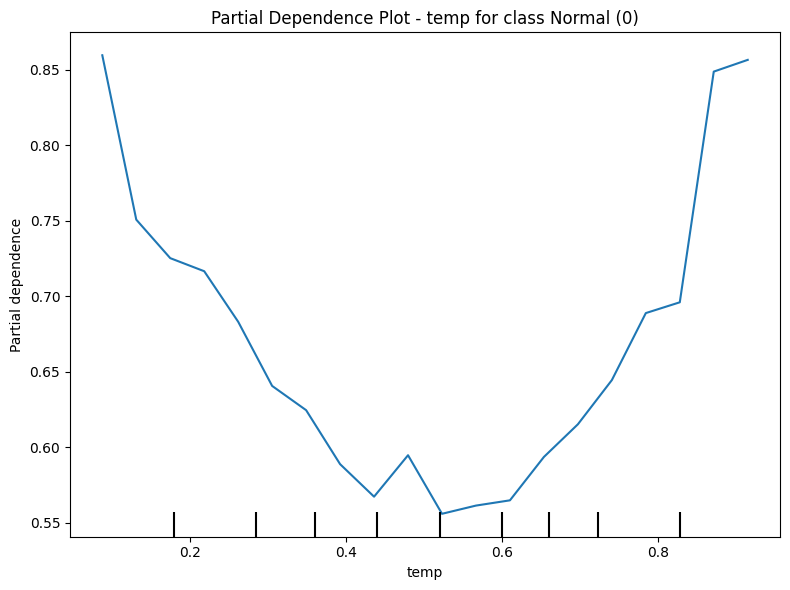

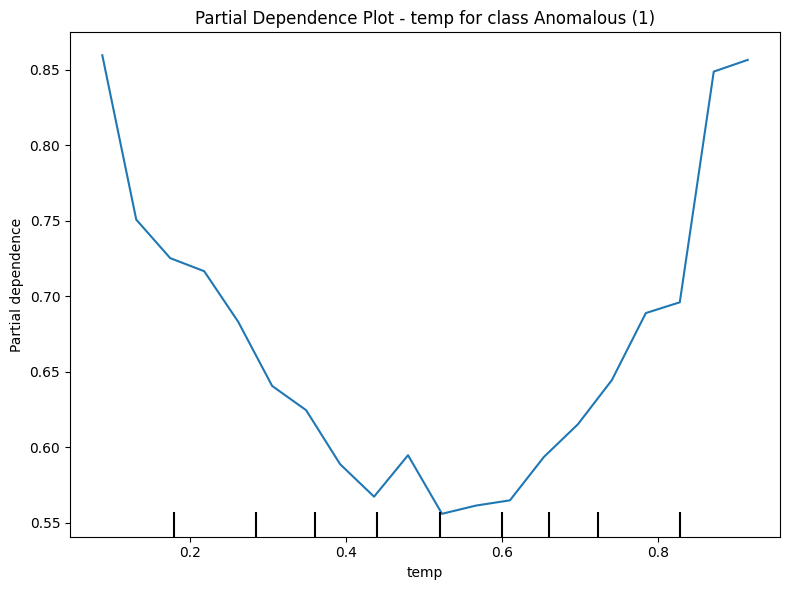

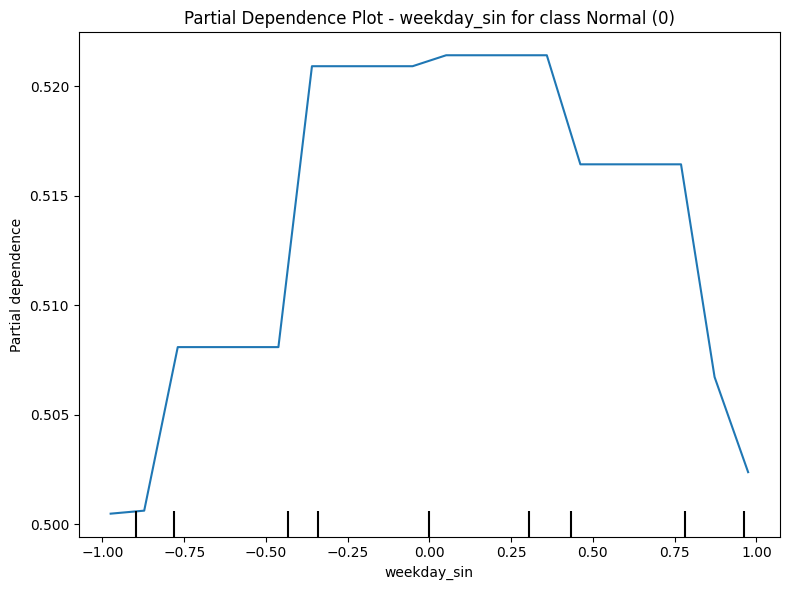

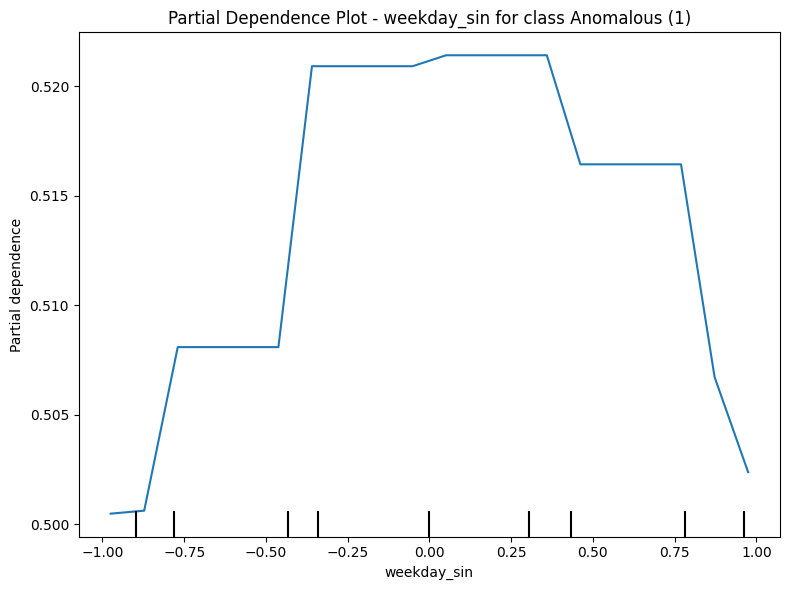

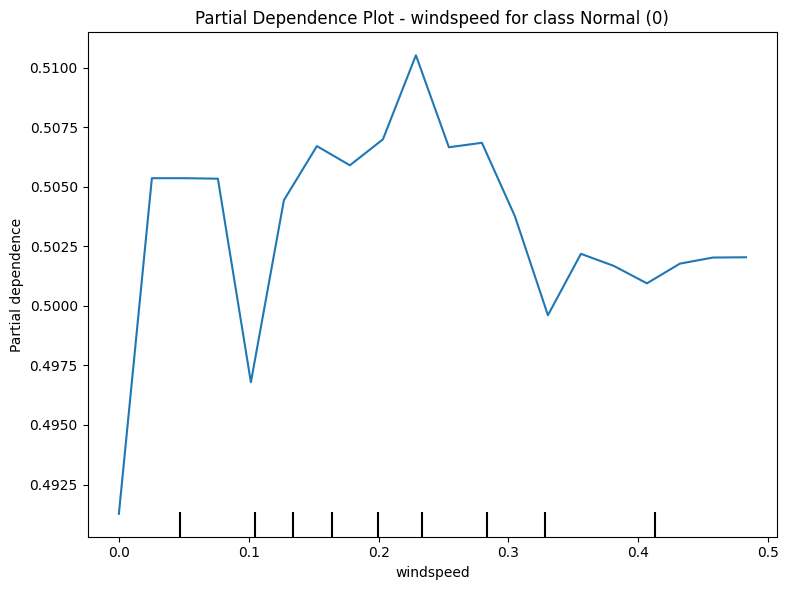

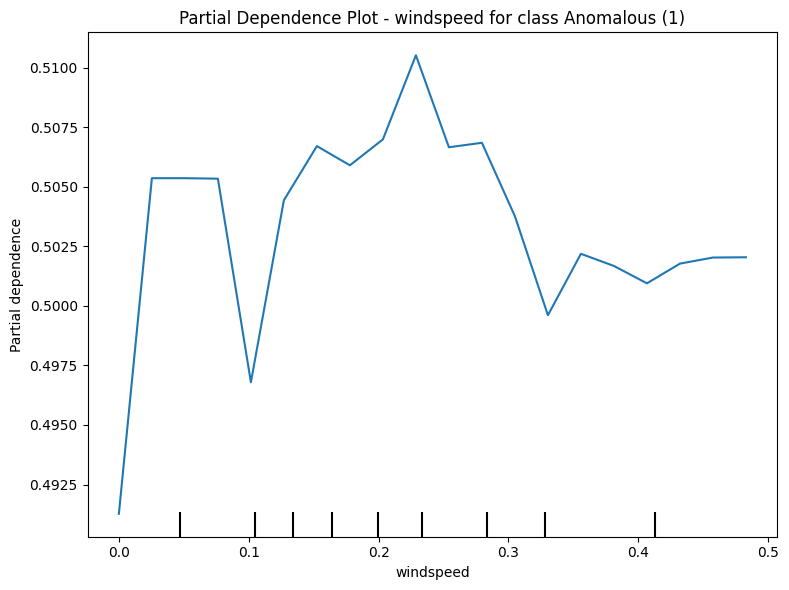

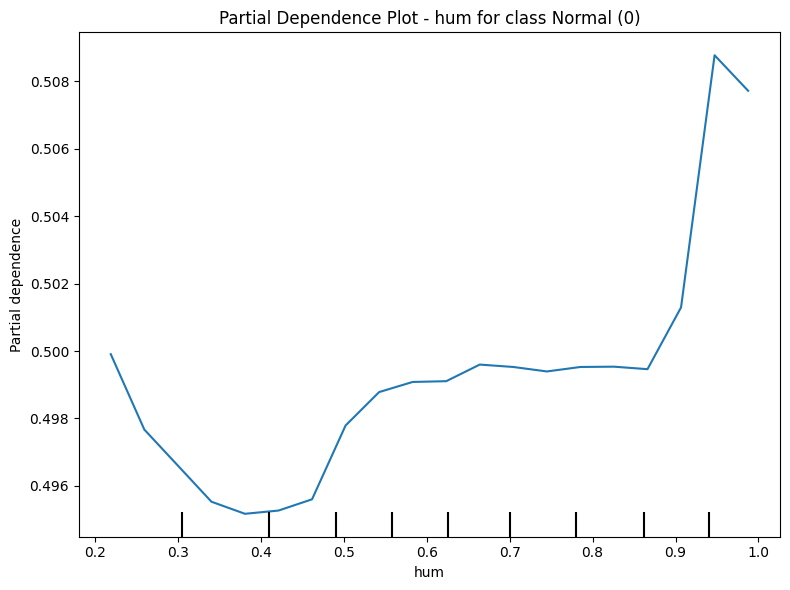

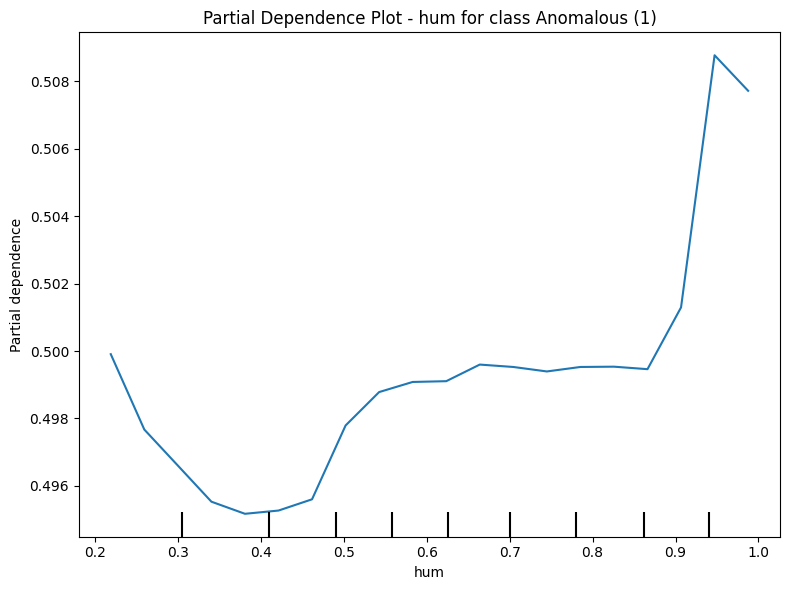

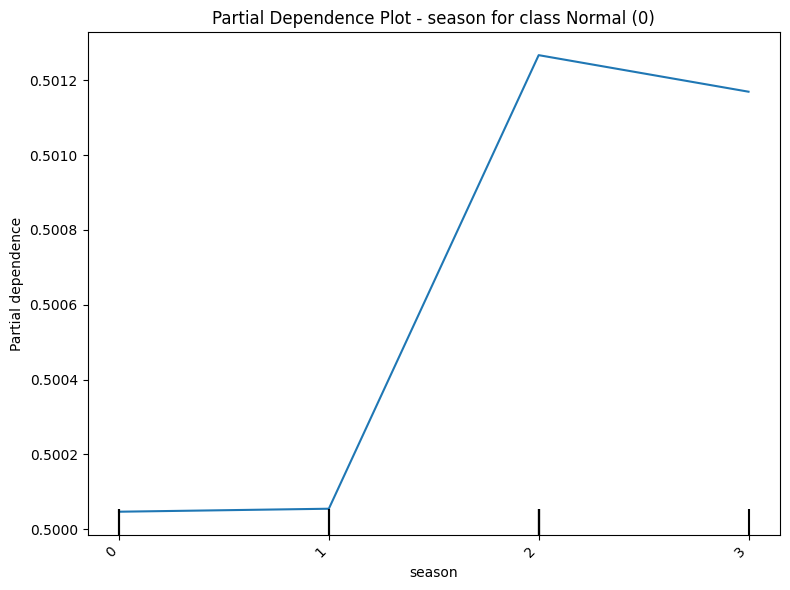

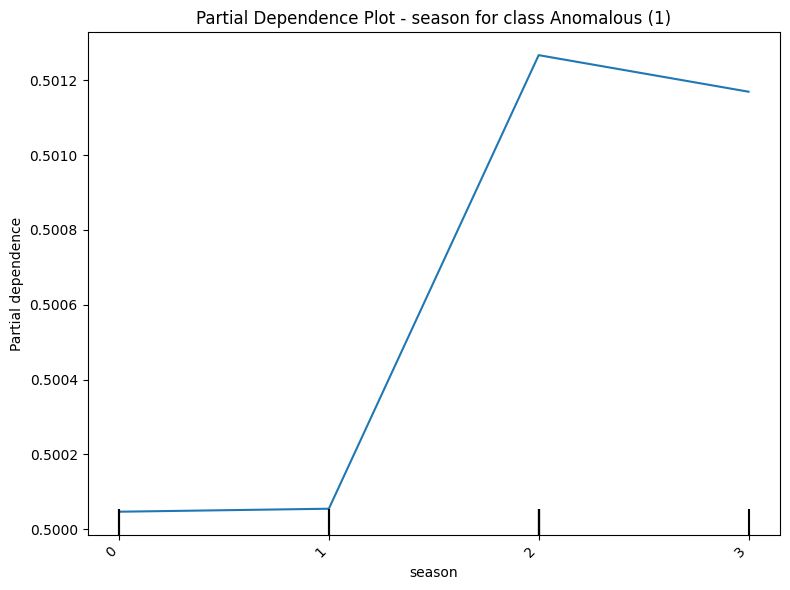

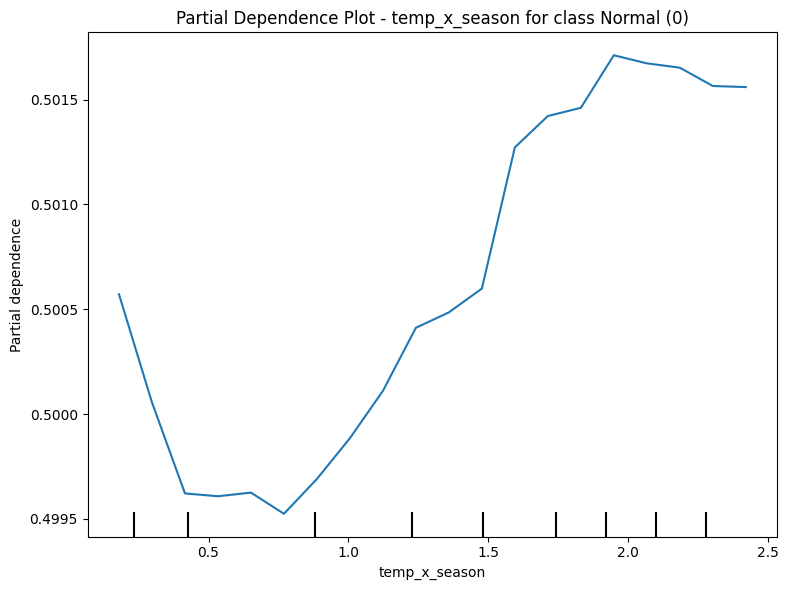

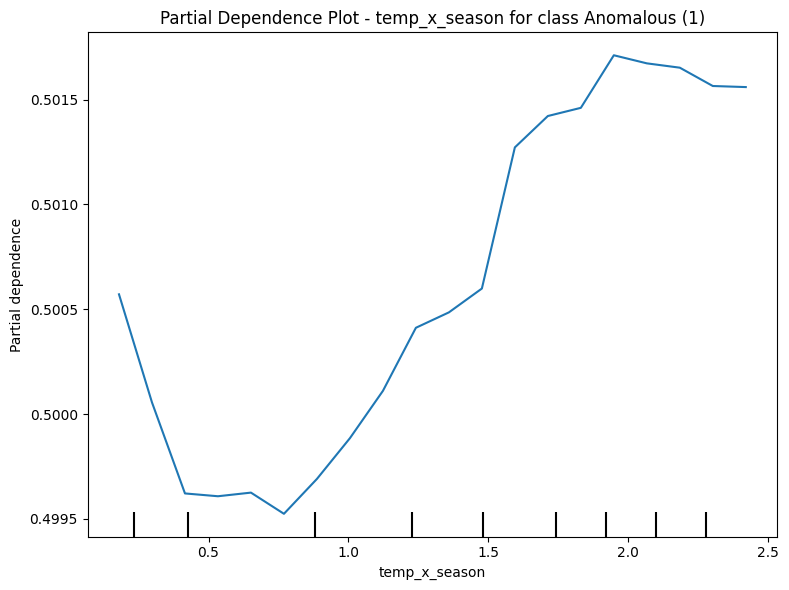

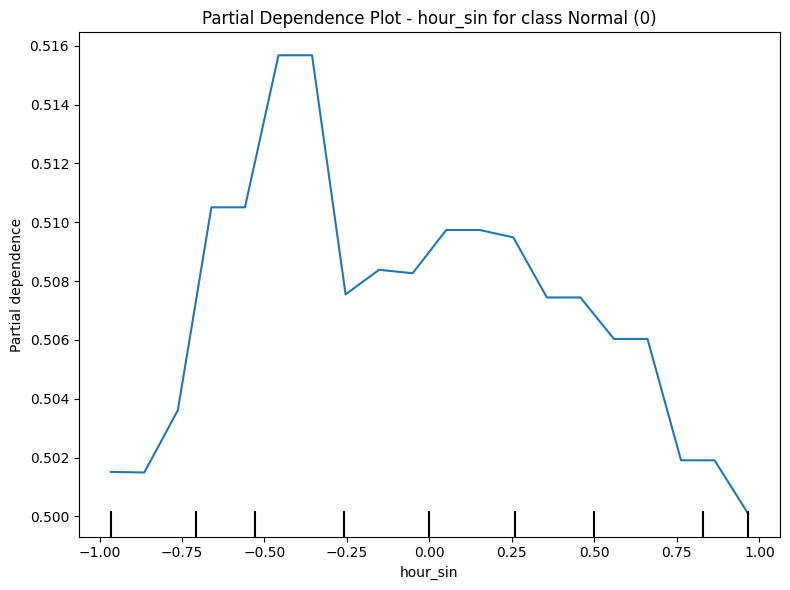

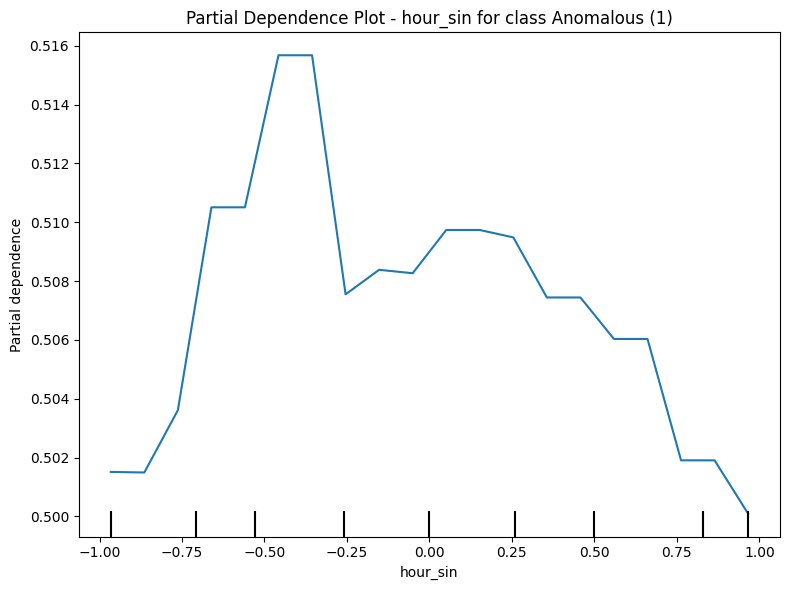

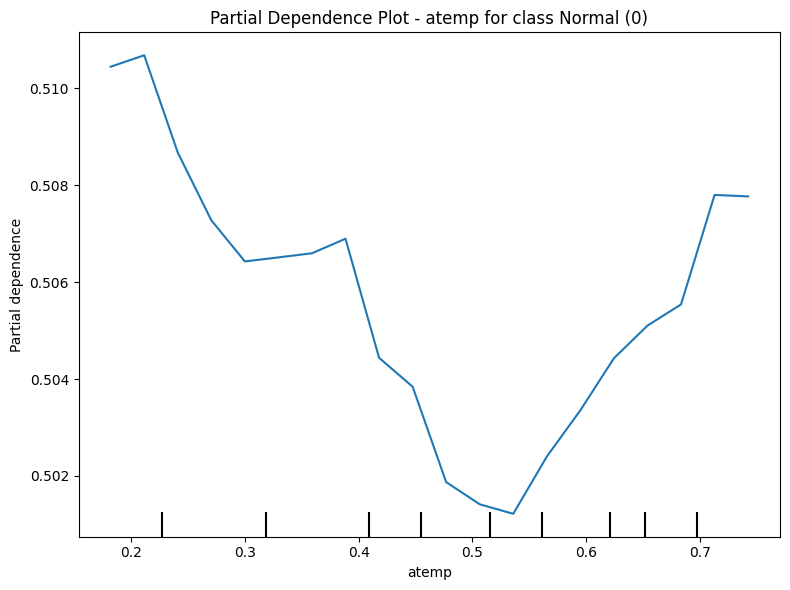

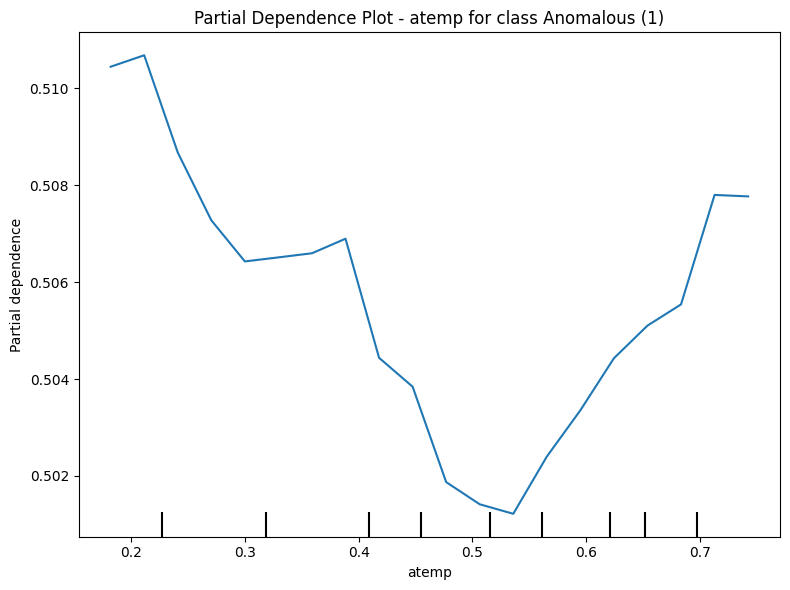

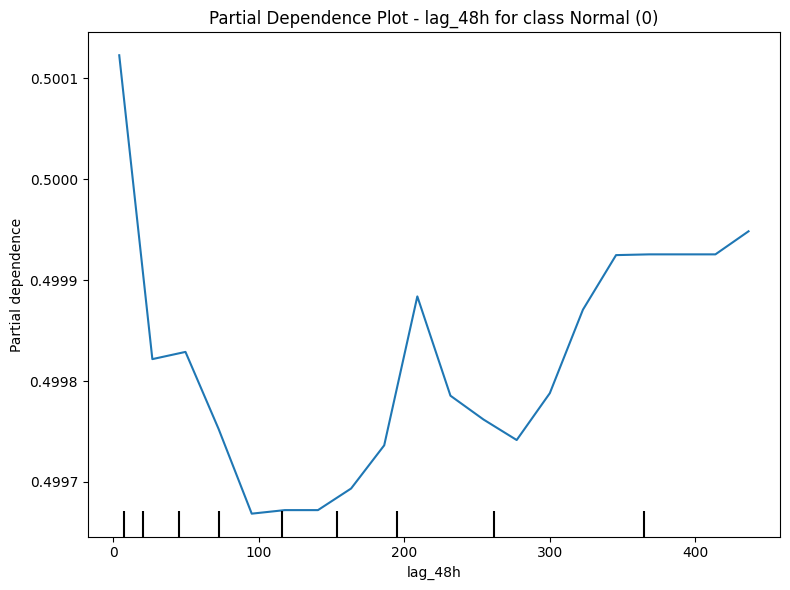

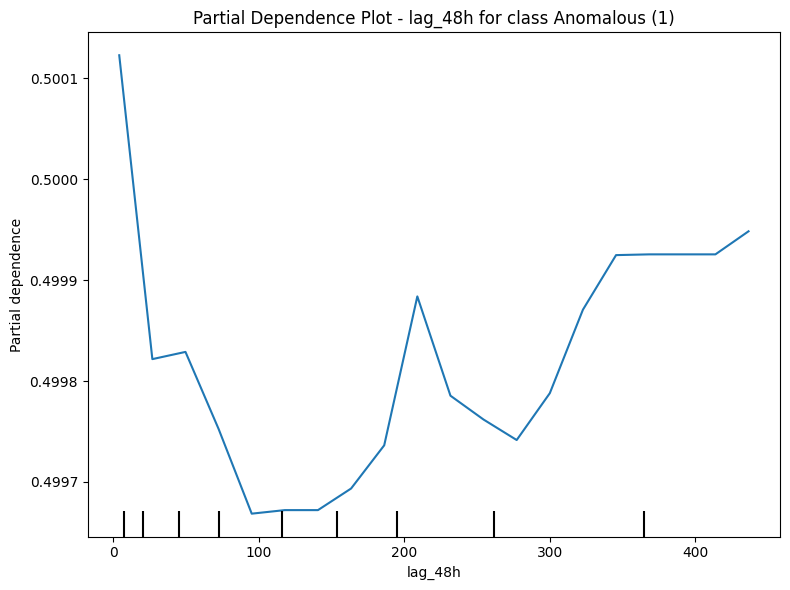

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt # Import matplotlib for plotting
import pandas as pd # Import pandas
import numpy as np # Import numpy

if 'reduced_xgb' in locals() and 'X_train_reduced' in locals() and 'selected_features_90' in locals():
    print("Generating Partial Dependence Plots (PDPs) for selected features...")

    # Select a few representative features from the important features list for PDPs
    # You can adjust this list based on which features you want to investigate further
    # Let's pick a few from the top of the selected_features_90 list and a couple from the rest
    features_for_pdp = selected_features_90[:15] + selected_features_90[-2:] # Example: top 10 and bottom 5

    # Ensure selected features are actually in the reduced training data columns
    features_for_pdp = [f for f in features_for_pdp if f in X_train_reduced.columns]

    if not features_for_pdp:
        print("No features selected for PDP plotting. Please check 'selected_features_90' and 'X_train_reduced' columns.")
    else:
        print(f"Generating PDPs for features: {features_for_pdp}")

        # Identify numerical and categorical columns within the reduced feature set
        numerical_cols_reduced = [col for col in features_for_pdp if pd.api.types.is_numeric_dtype(X_train_reduced[col])]

        # Categorical features in X_train_reduced will likely be int after ordinal encoding, but were originally categorical.
        # We need to know their original categorical nature to potentially handle them differently or interpret the integer values.
        # For PDP, we can treat the ordinally encoded features as numerical, but remember they represent categories.
        # Let's just use the list of features for plotting directly for simplicity with sklearn's PDP.

        # Generate PDPs for each selected feature and each target class (0: Normal, 1: Anomalous)
        for feature in features_for_pdp:
            # Determine the grid resolution for the plot - adjust as needed
            # For features that were originally categorical (now ordinal int), use unique values
            # For numerical features, use a fixed number of grid points
            # Corrected: Pass the number of unique values as an integer for grid_resolution
            if feature in [col for col in feature_cols if X_train_resampled_df[col].dtype == 'category']: # Check if original feature was categorical
                 grid_resolution = X_train_reduced[feature].nunique() # Use the number of unique ordinal values
                 # Also get the unique values for xticks later
                 unique_ordinal_values = sorted(X_train_reduced[feature].unique())
            else:
                 grid_resolution = 20 # Default grid points for numerical features
                 unique_ordinal_values = None # Not applicable for numerical

            # Need to ensure the data passed to PDPDisplay is numeric.
            # X_train_reduced should already be numeric (float or int) after preprocessing.
            # If errors occur, add explicit pd.to_numeric conversion here.

            try:
                # Generate PDP for class 0 (Normal)
                fig, ax = plt.subplots(figsize=(8, 6))
                display = PartialDependenceDisplay.from_estimator(
                    estimator=reduced_xgb,
                    X=X_train_reduced, # Use the reduced training data
                    features=[feature],
                    target=0, # Target class 0 (Normal)
                    feature_names=X_train_reduced.columns.tolist(), # Provide feature names
                    grid_resolution=grid_resolution,
                    ax=ax,
                    # The kind='average' is default, but can be specified
                    # kind='individual' can plot individual instances
                )
                ax.set_title(f"Partial Dependence Plot - {feature} for class Normal (0)")
                # If the feature was originally categorical, set xticks to display ordinal values
                if feature in [col for col in feature_cols if X_train_resampled_df[col].dtype == 'category']:
                     plt.xticks(ticks=unique_ordinal_values, labels=unique_ordinal_values, rotation=45, ha='right')
                plt.tight_layout()
                plt.show()

                # Generate PDP for class 1 (Anomalous)
                fig, ax = plt.subplots(figsize=(8, 6))
                display = PartialDependenceDisplay.from_estimator(
                    estimator=reduced_xgb,
                    X=X_train_reduced, # Use the reduced training data
                    features=[feature],
                    target=1, # Target class 1 (Anomalous)
                    feature_names=X_train_reduced.columns.tolist(), # Provide feature names
                    grid_resolution=grid_resolution,
                    ax=ax,
                    # kind='average'
                )
                ax.set_title(f"Partial Dependence Plot - {feature} for class Anomalous (1)")
                 # If the feature was originally categorical, set xticks to display ordinal values
                if feature in [col for col in feature_cols if X_train_resampled_df[col].dtype == 'category']:
                     plt.xticks(ticks=unique_ordinal_values, labels=unique_ordinal_values, rotation=45, ha='right')
                plt.tight_layout()
                plt.show()

            except Exception as e:
                print(f"Could not generate PDP for feature '{feature}': {e}")

else:
    print("Best XGBoost model ('reduced_xgb'), reduced training data ('X_train_reduced'), or selected features ('selected_features_90') not found. Skipping PDP plotting.")

Generating Partial Dependence Plots (PDPs) for selected features...
Generating PDPs for features: ['weekday_cos', 'month_cos', 'weekday', 'month', 'temp_x_workingday', 'weathersit', 'hour', 'month_sin', 'temp', 'weekday_sin', 'windspeed', 'hum', 'season', 'temp_x_season', 'hour_sin', 'atemp', 'lag_48h']


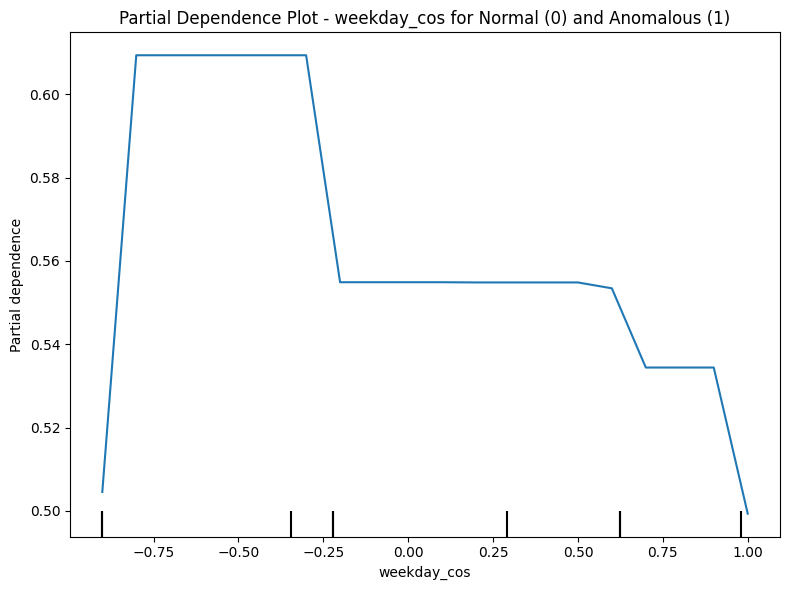

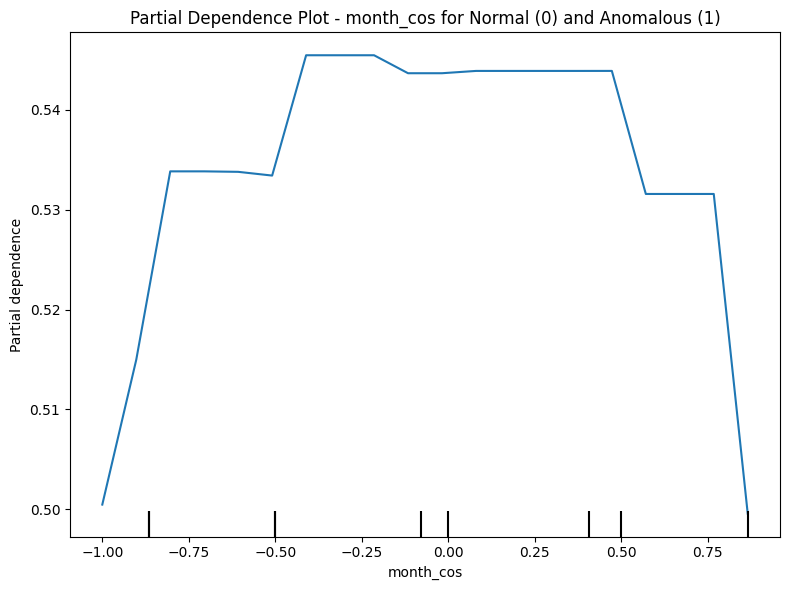

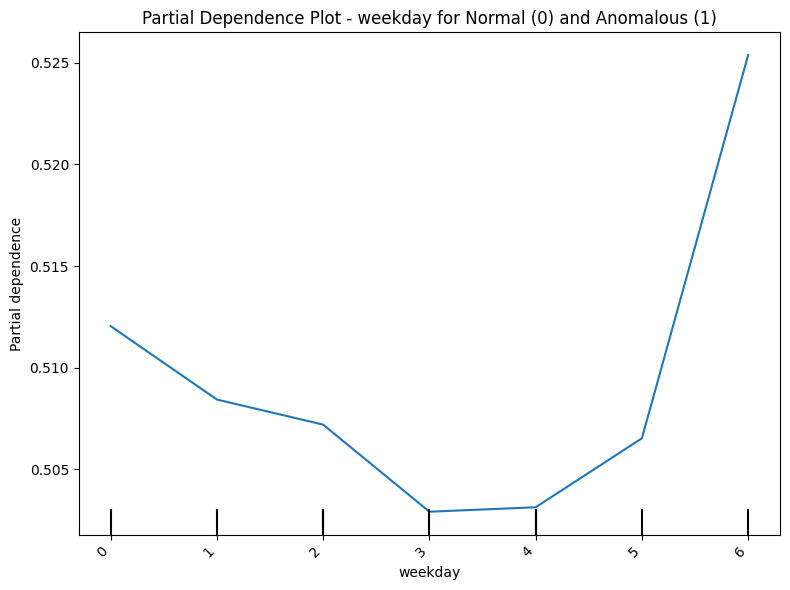

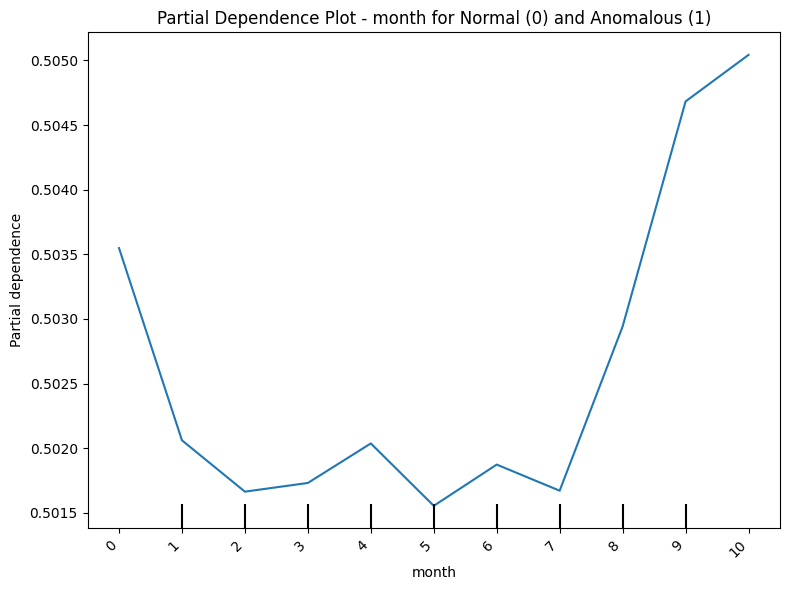

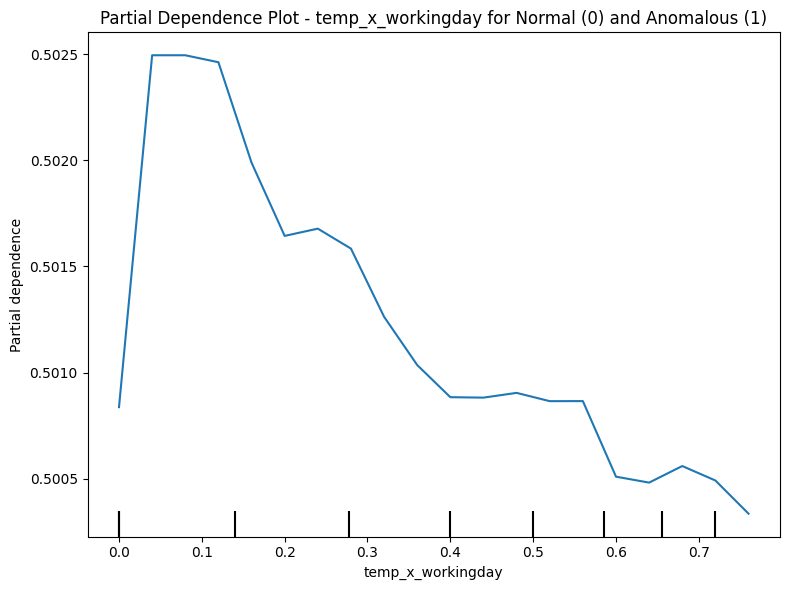

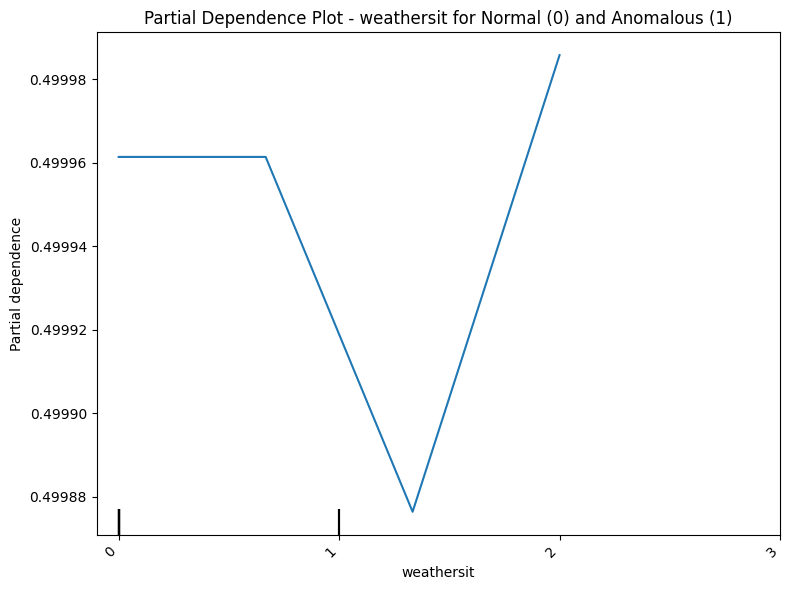

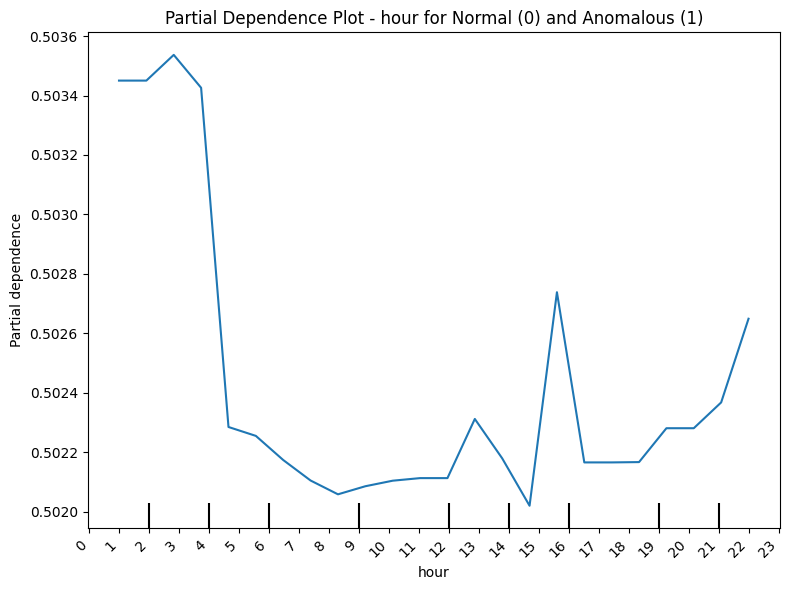

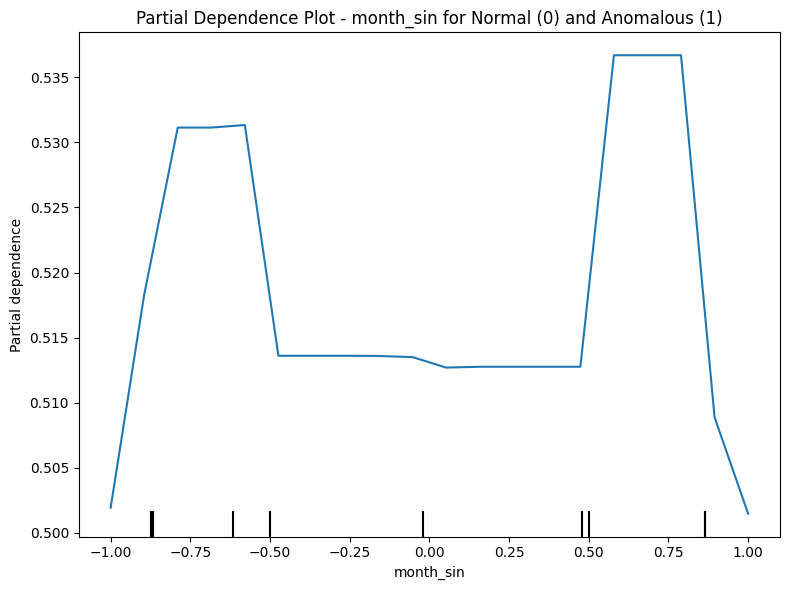

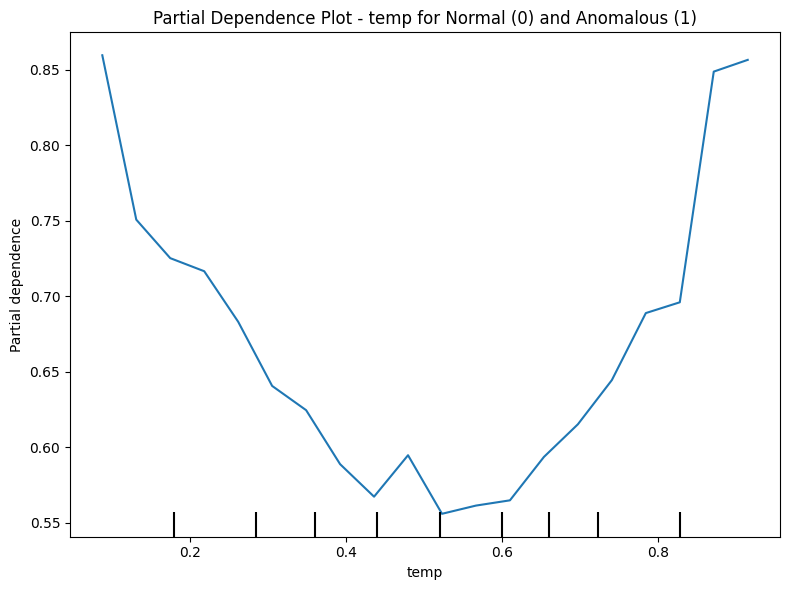

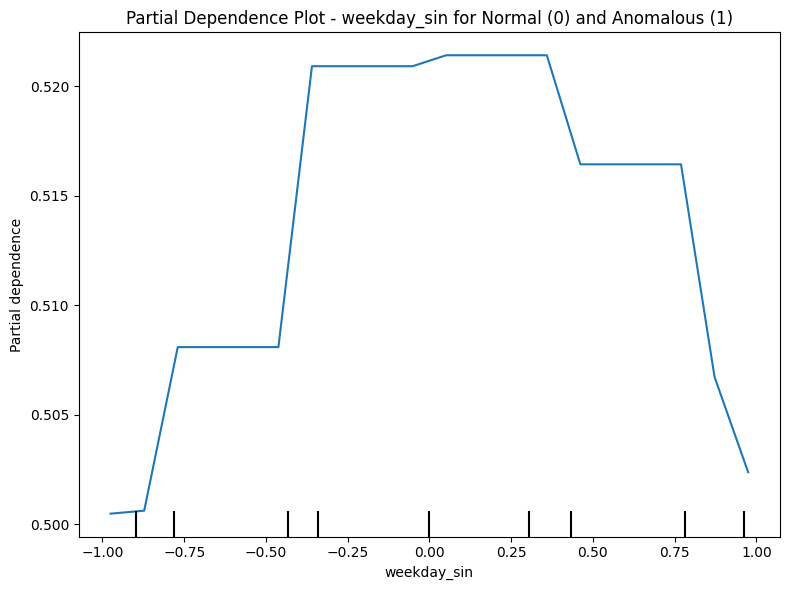

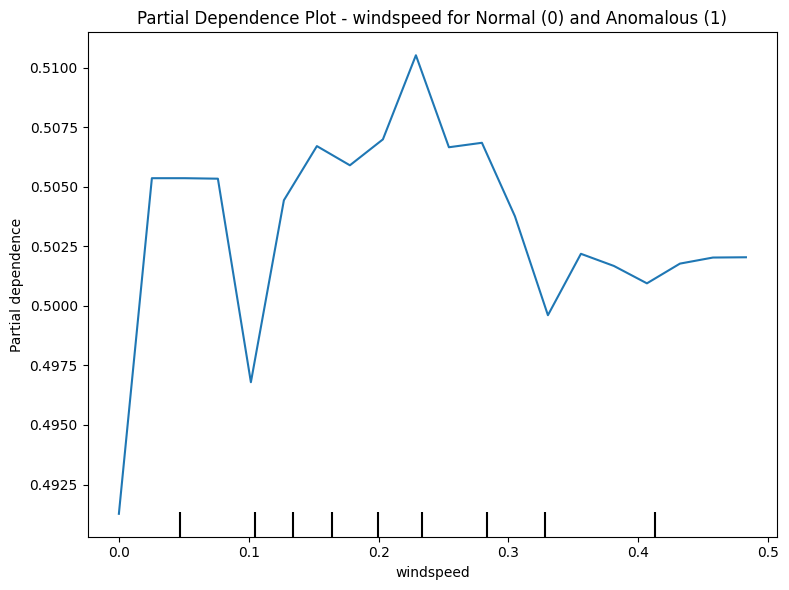

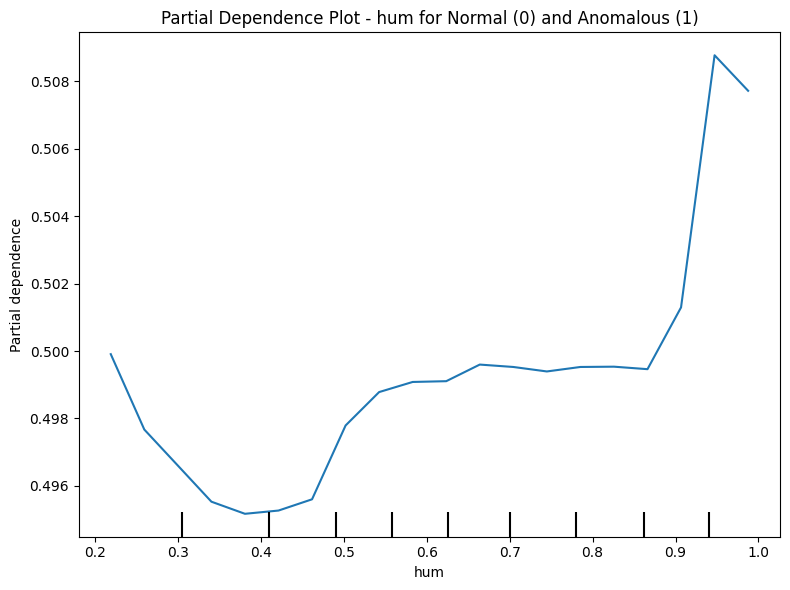

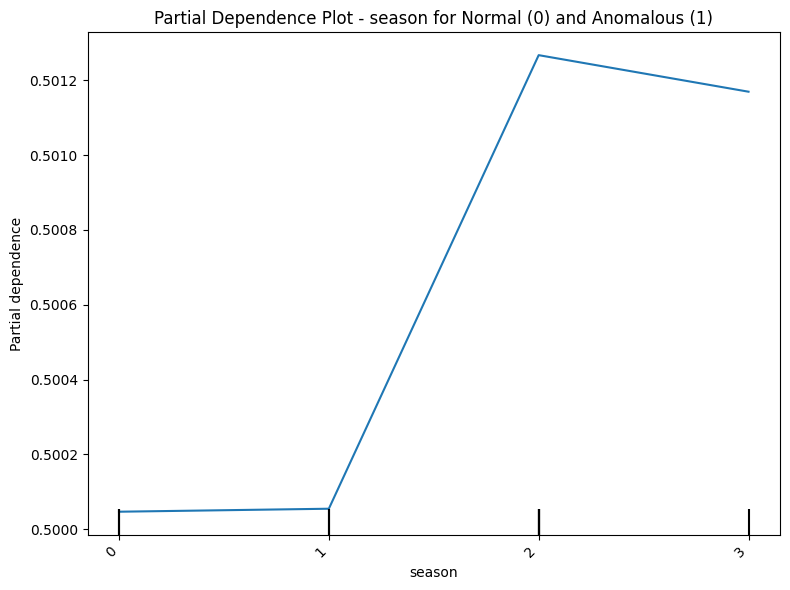

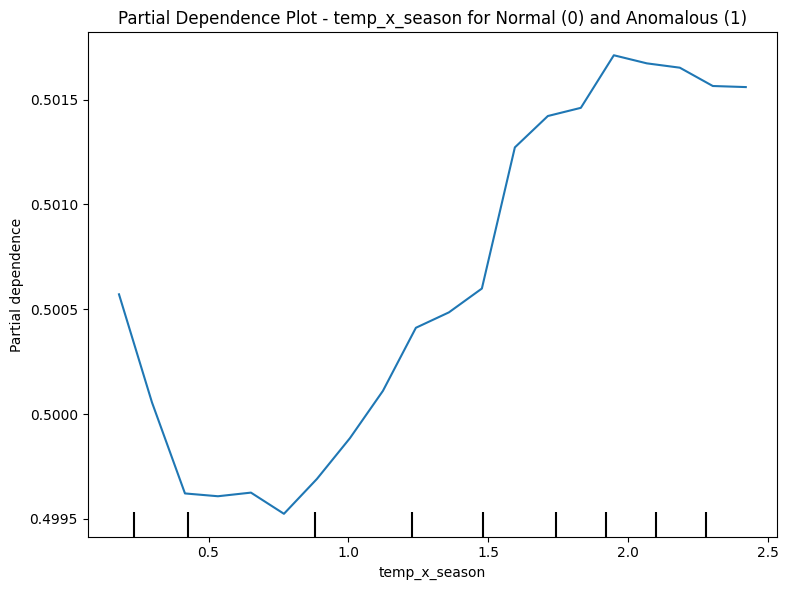

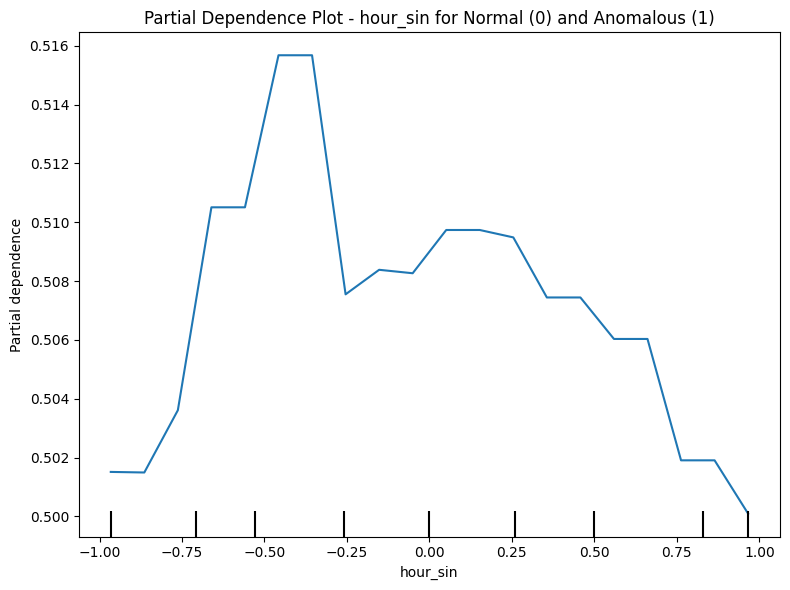

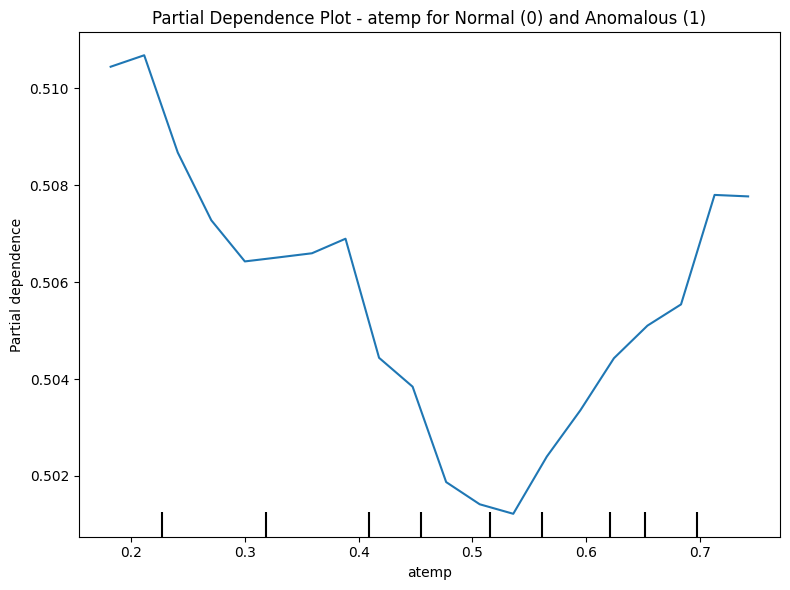

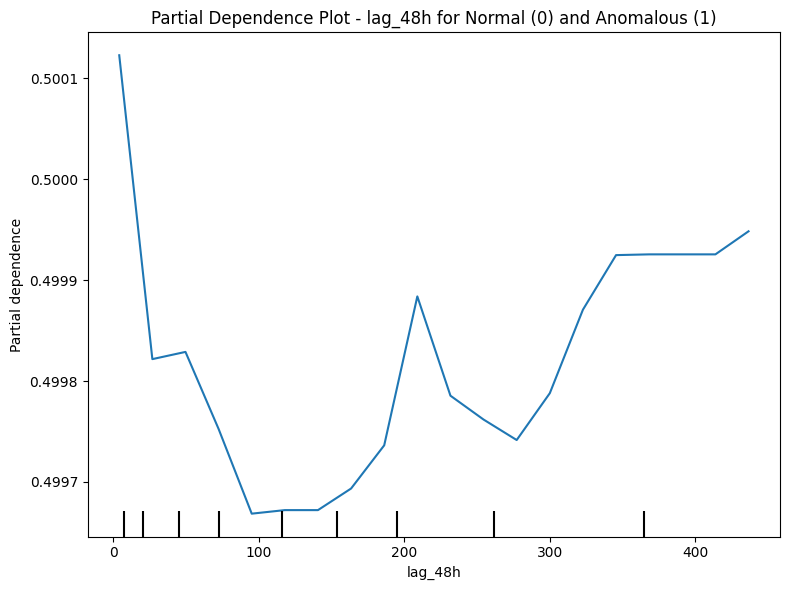

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt # Import matplotlib for plotting
import pandas as pd # Import pandas
import numpy as np # Import numpy

if 'reduced_xgb' in locals() and 'X_train_reduced' in locals() and 'selected_features_90' in locals():
    print("Generating Partial Dependence Plots (PDPs) for selected features...")

    # Select a few representative features from the important features list for PDPs
    # You can adjust this list based on which features you want to investigate further
    # Let's pick a few from the top of the selected_features_90 list and a couple from the rest
    features_for_pdp = selected_features_90[:15] + selected_features_90[-2:] # Example: top 10 and bottom 5

    # Ensure selected features are actually in the reduced training data columns
    features_for_pdp = [f for f in features_for_pdp if f in X_train_reduced.columns]

    if not features_for_pdp:
        print("No features selected for PDP plotting. Please check 'selected_features_90' and 'X_train_reduced' columns.")
    else:
        print(f"Generating PDPs for features: {features_for_pdp}")

        # Identify numerical and categorical columns within the reduced feature set
        numerical_cols_reduced = [col for col in features_for_pdp if pd.api.types.is_numeric_dtype(X_train_reduced[col])]

        # Categorical features in X_train_reduced will likely be int after ordinal encoding, but were originally categorical.
        # We need to know their original categorical nature to potentially handle them differently or interpret the integer values.
        # For PDP, we can treat the ordinally encoded features as numerical, but remember they represent categories.
        # Let's just use the list of features for plotting directly for simplicity with sklearn's PDP.

        # Generate PDPs for each selected feature on the same plot
        for feature in features_for_pdp:
            # Determine the grid resolution for the plot - adjust as needed
            # For features that were originally categorical (now ordinal int), use unique values
            # For numerical features, use a fixed number of grid points
            # Corrected: Pass the number of unique values as an integer for grid_resolution
            if feature in [col for col in feature_cols if X_train_resampled_df[col].dtype == 'category']: # Check if original feature was categorical
                 grid_resolution = X_train_reduced[feature].nunique() # Use the number of unique ordinal values
                 # Also get the unique values for xticks later
                 unique_ordinal_values = sorted(X_train_reduced[feature].unique())
            else:
                 grid_resolution = 20 # Default grid points for numerical features
                 unique_ordinal_values = None # Not applicable for numerical

            # Need to ensure the data passed to PDPDisplay is numeric.
            # X_train_reduced should already be numeric (float or int) after preprocessing.
            # If errors occur, add explicit pd.to_numeric conversion here.

            try:
                fig, ax = plt.subplots(figsize=(8, 6))
                # Generate PDP for class 0 (Normal) and class 1 (Anomalous) on the same axes
                PartialDependenceDisplay.from_estimator(
                    estimator=reduced_xgb,
                    X=X_train_reduced, # Use the reduced training data
                    features=[feature],
                    target=[0, 1], # Specify both target classes
                    feature_names=X_train_reduced.columns.tolist(), # Provide feature names
                    grid_resolution=grid_resolution,
                    ax=ax,
                    # The kind='average' is default, but can be specified
                    # kind='individual' can plot individual instances
                )
                ax.set_title(f"Partial Dependence Plot - {feature} for Normal (0) and Anomalous (1)")
                ax.legend(['Normal (0)', 'Anomalous (1)']) # Add legend
                # If the feature was originally categorical, set xticks to display ordinal values
                if feature in [col for col in feature_cols if X_train_resampled_df[col].dtype == 'category']:
                     plt.xticks(ticks=unique_ordinal_values, labels=unique_ordinal_values, rotation=45, ha='right')
                plt.tight_layout()
                plt.show()

            except Exception as e:
                print(f"Could not generate PDP for feature '{feature}': {e}")

else:
    print("Best XGBoost model ('reduced_xgb'), reduced training data ('X_train_reduced'), or selected features ('selected_features_90') not found. Skipping PDP plotting.")



---



Generating Partial Dependence Plots (PDPs) for selected features using the optimum XGBoost model...
Generating PDPs for features: ['weekday_cos', 'month_cos', 'weekday', 'month', 'temp_x_workingday', 'weathersit', 'hour', 'month_sin', 'temp', 'weekday_sin', 'windspeed', 'hum', 'season', 'temp_x_season', 'hour_sin', 'lag_168h', 'hour_cos', 'rolling_mean_12h', 'atemp', 'lag_48h']


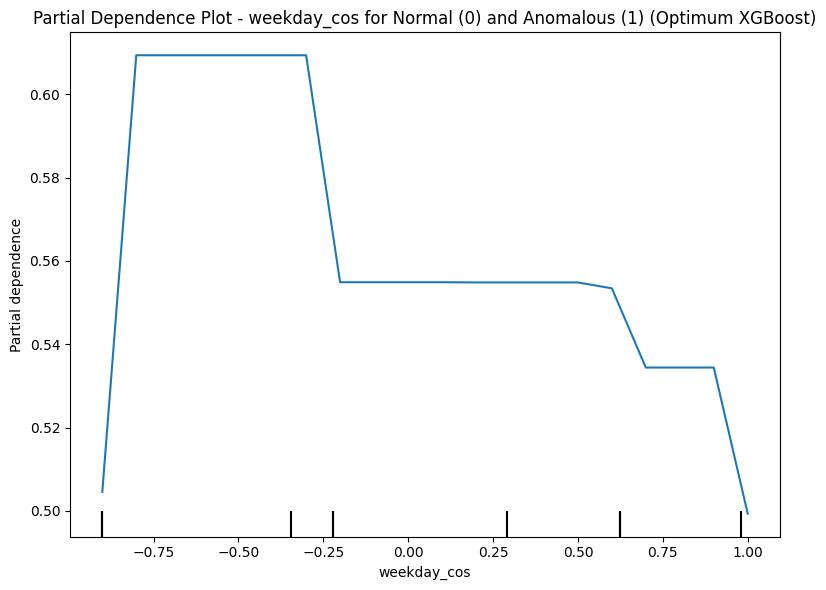

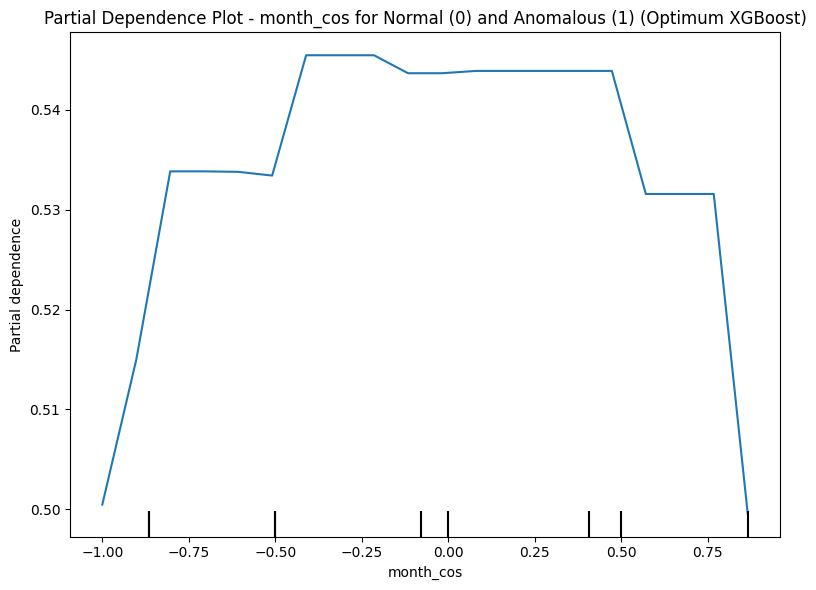

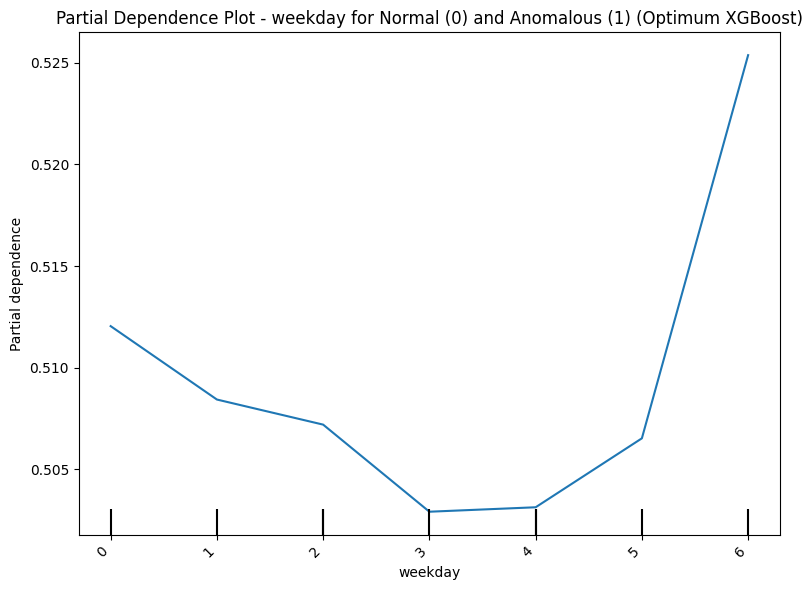

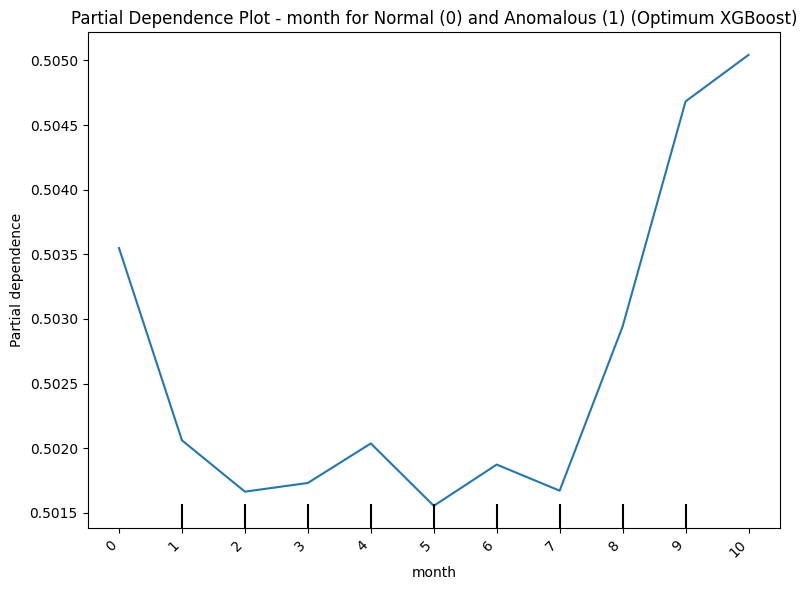

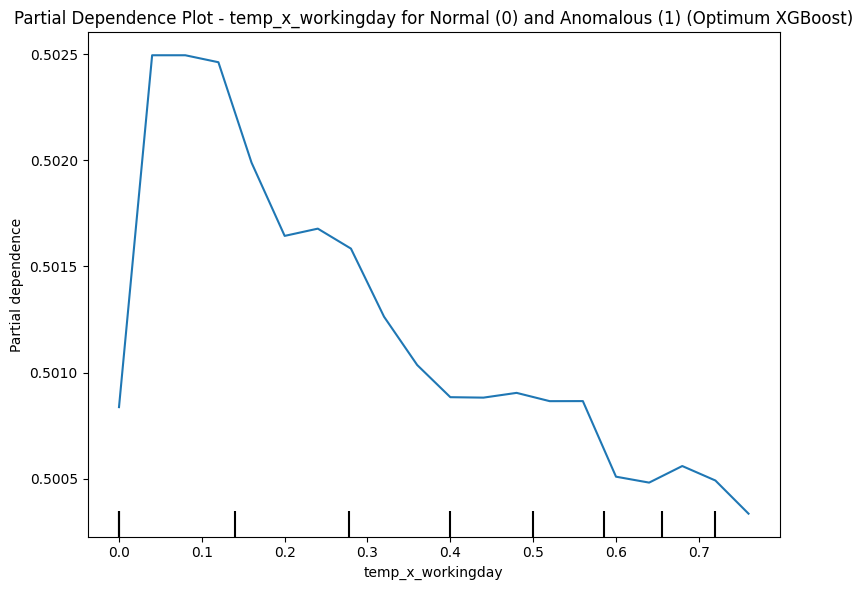

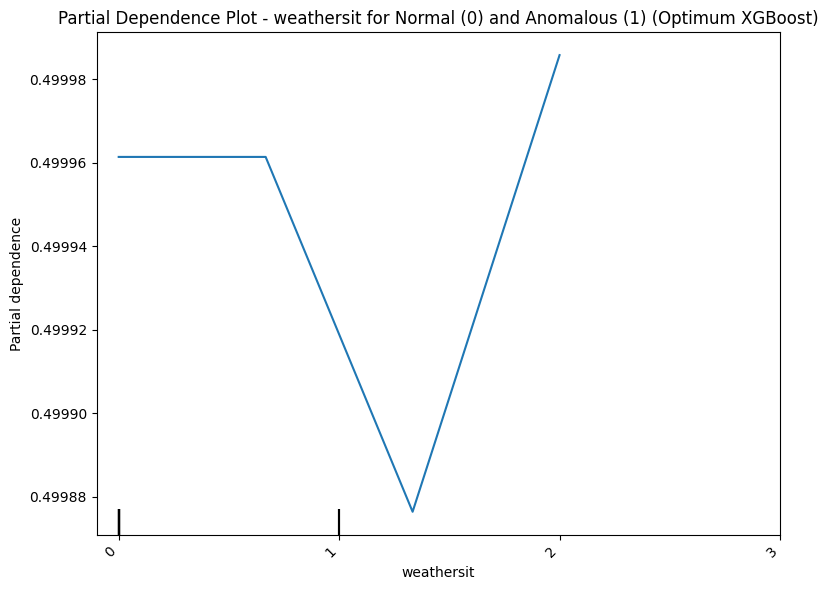

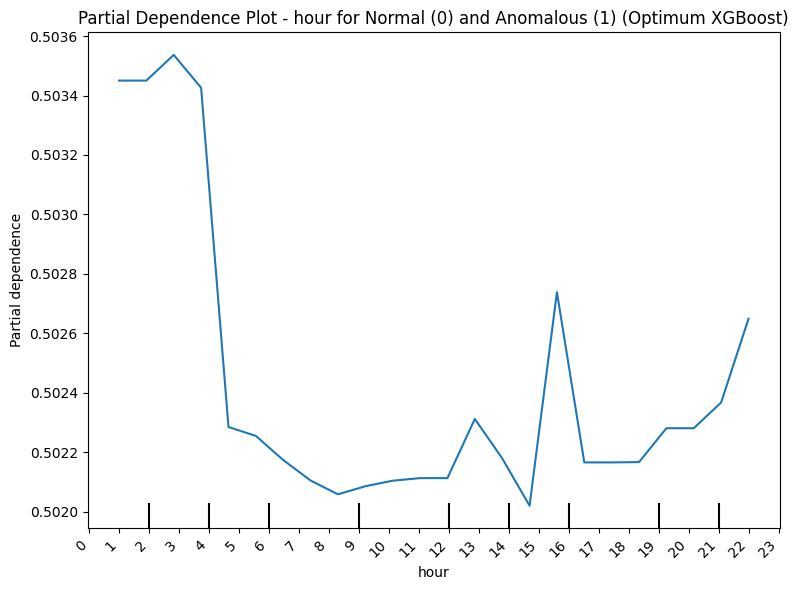

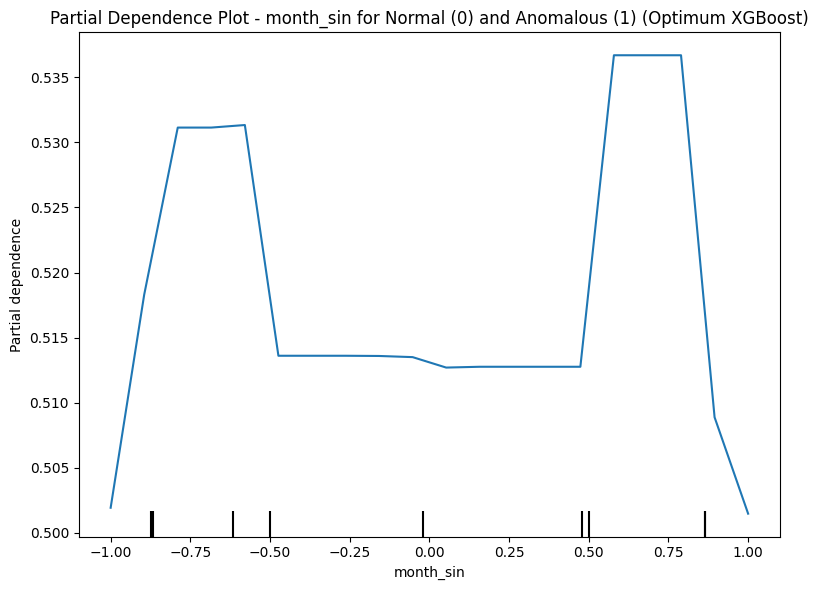

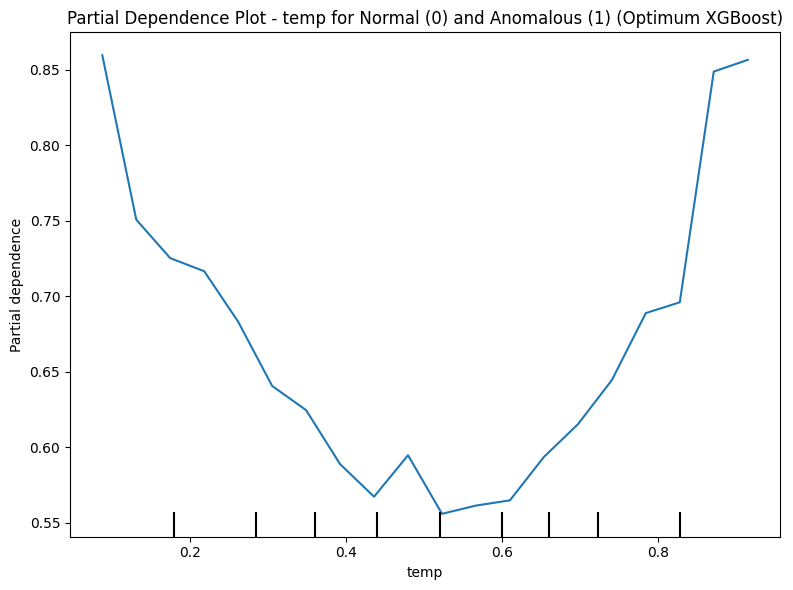

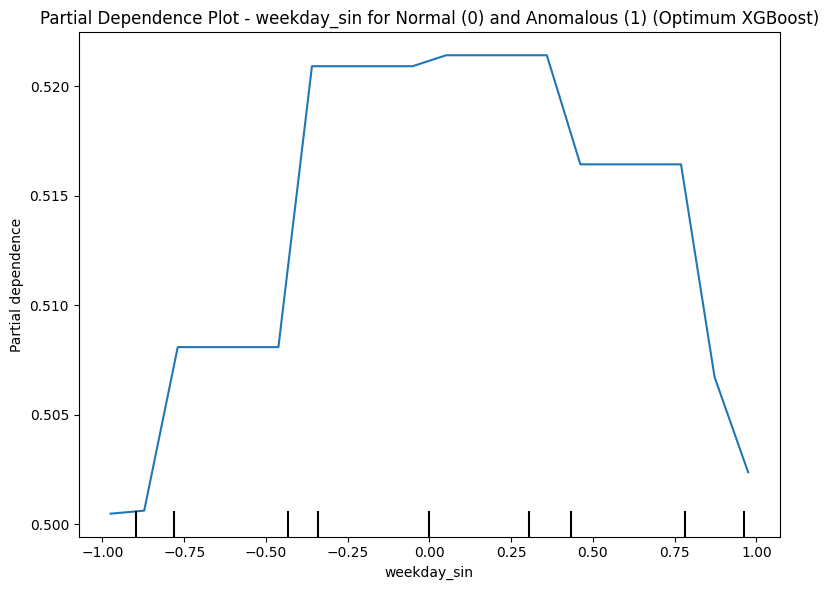

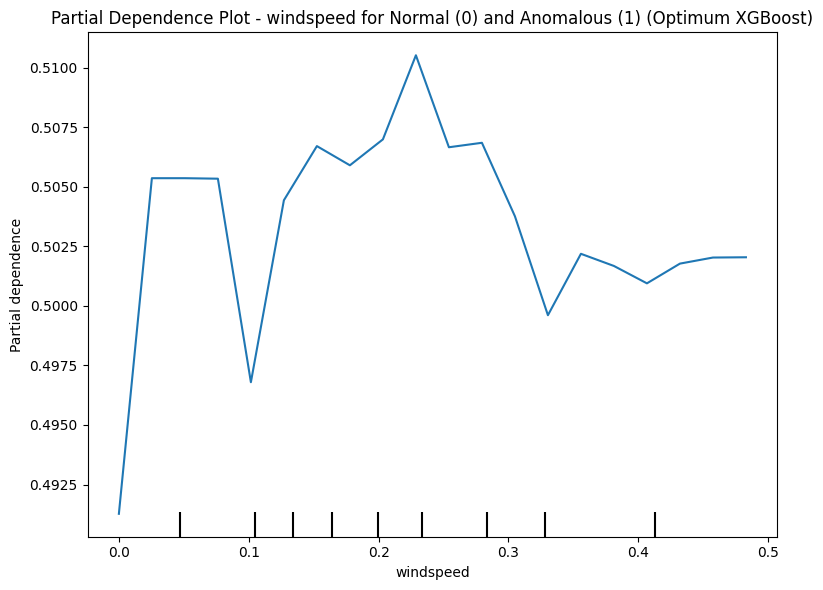

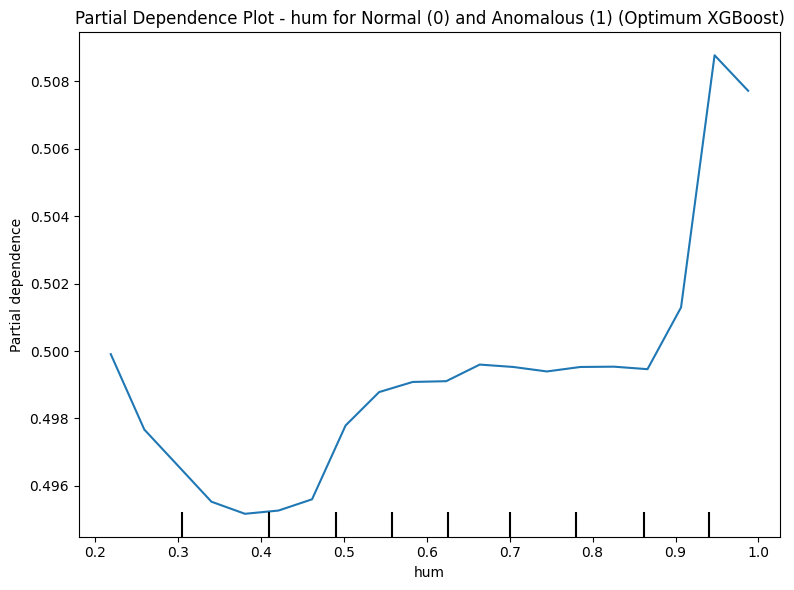

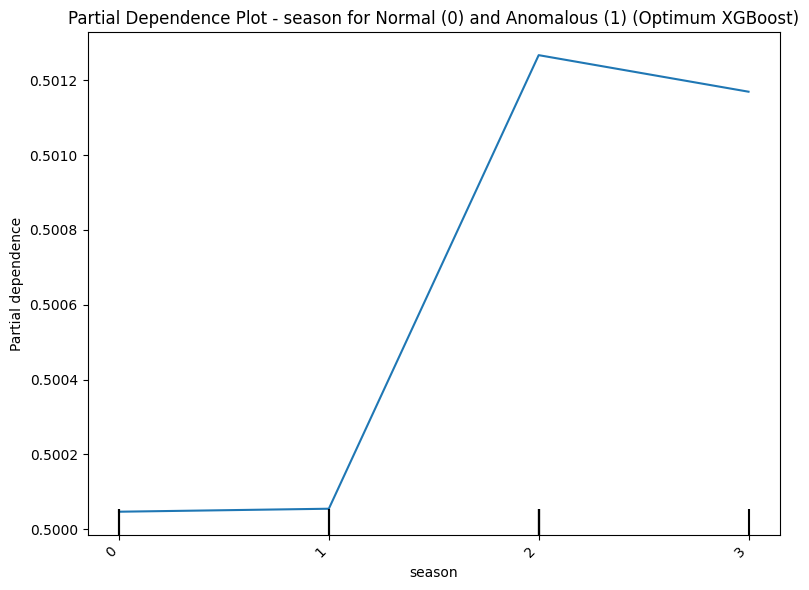

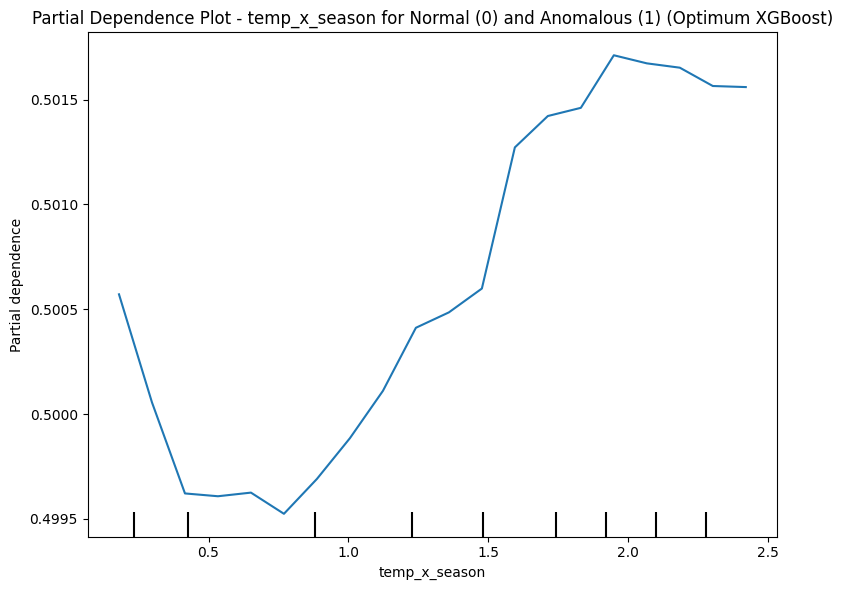

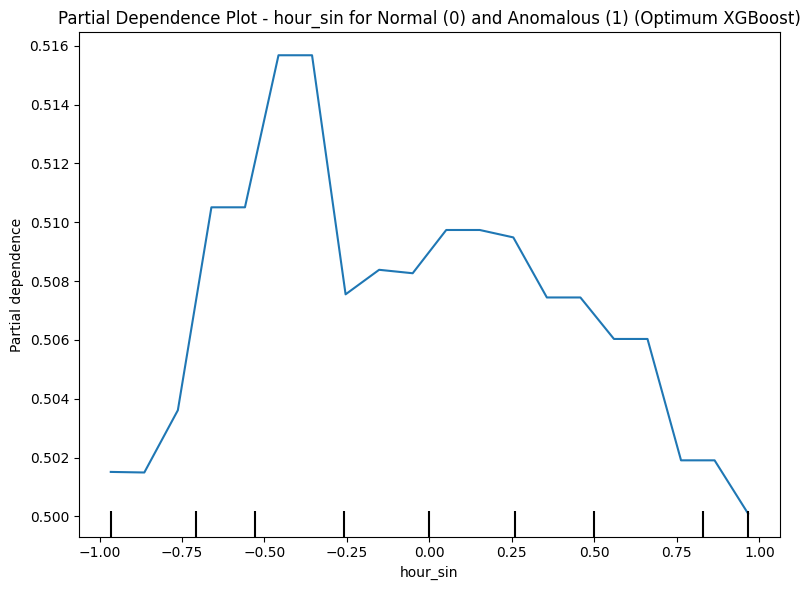

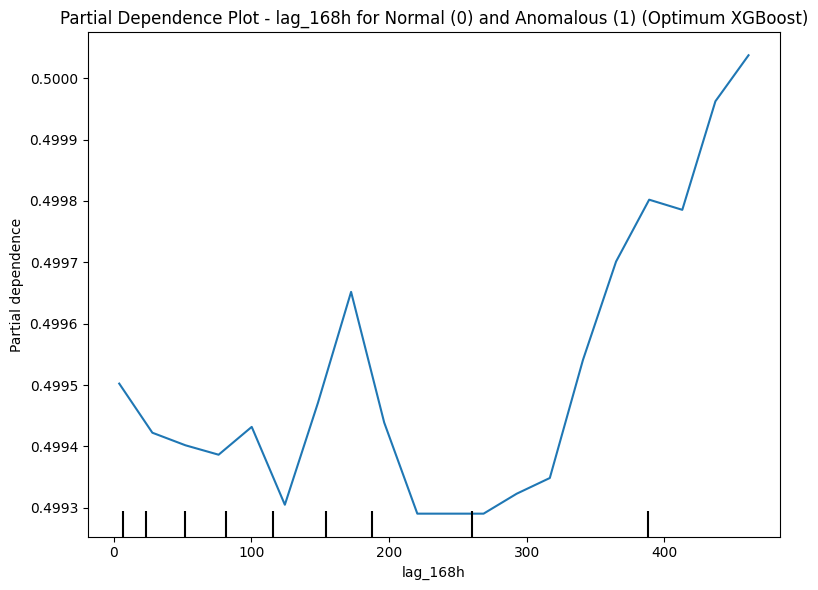

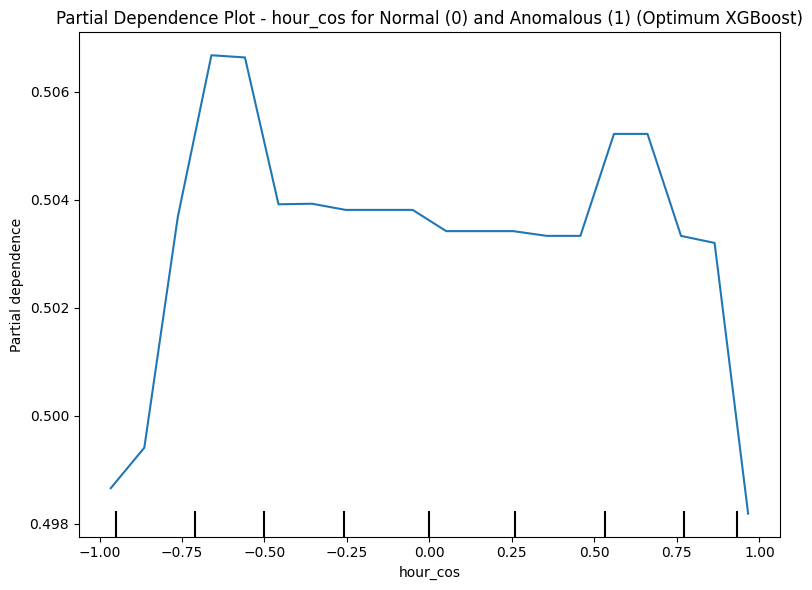

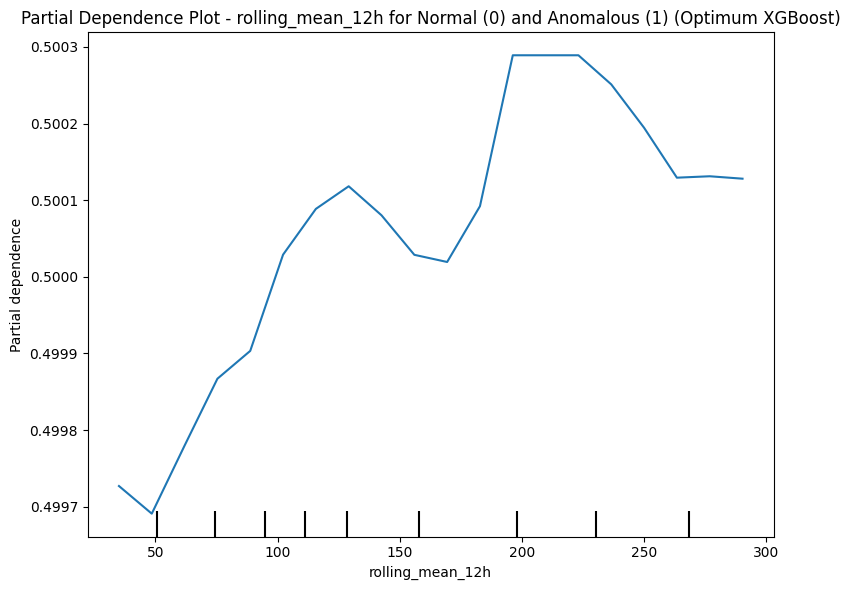

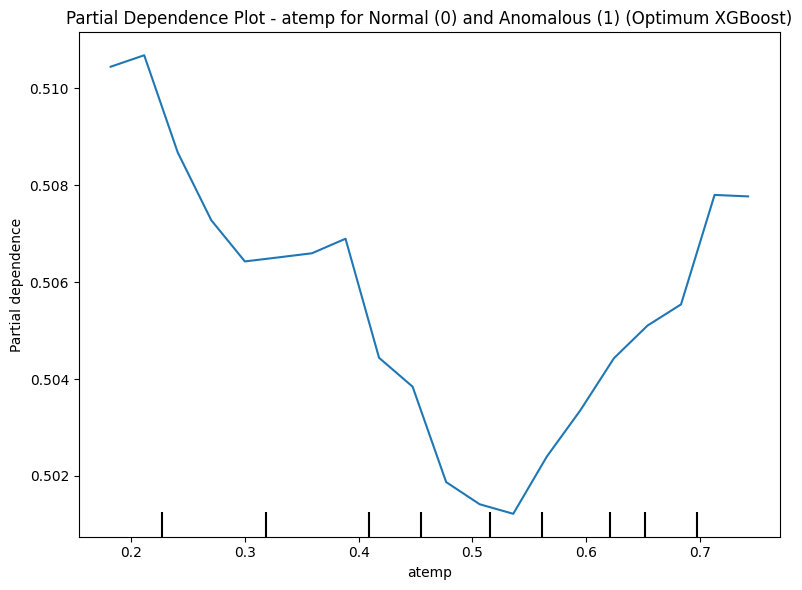

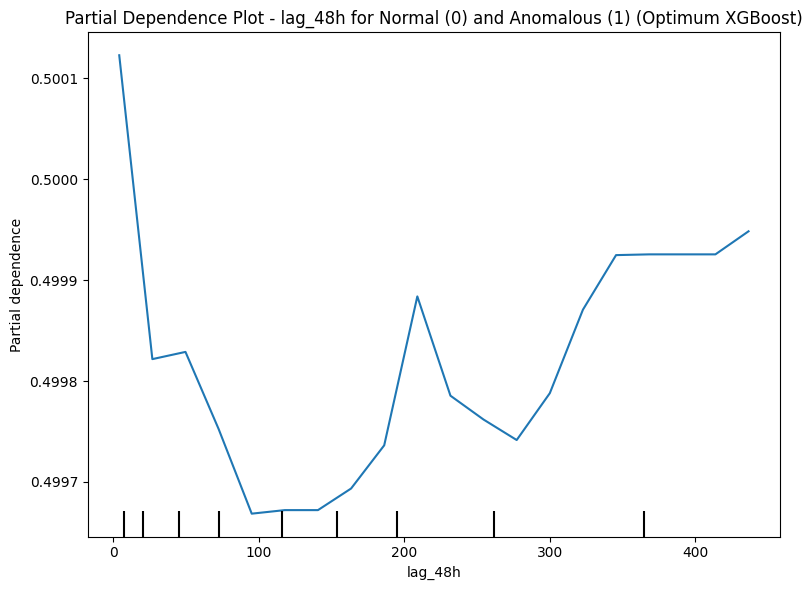

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt # Import matplotlib for plotting
import pandas as pd # Import pandas
import numpy as np # Import numpy

# Use the best performing XGBoost model (XGBoost (Reduced Features - Prev. Best Params)) and its corresponding data
# Based on previous analysis, the best model is likely 'reduced_xgb' and the data is 'X_train_reduced'
if 'reduced_xgb' in locals() and 'X_train_reduced' in locals() and 'selected_features_90' in locals():
    print("Generating Partial Dependence Plots (PDPs) for selected features using the optimum XGBoost model...")

    model_to_plot = reduced_xgb # Use the best performing reduced XGBoost model
    X_train_for_plots = X_train_reduced # Use the reduced training data
    feature_names_for_plots = X_train_reduced.columns # Use the names of the selected features

    if not selected_features_90:
        print("No features selected for PDP plotting. Please check 'selected_features_90'.")
    else:
        print(f"Generating PDPs for features: {selected_features_90}")

        # Generate PDPs for each selected feature on the same plot, showing both classes
        for feature in selected_features_90:
            # Determine the grid resolution for the plot - adjust as needed
            # For features that were originally categorical (now ordinal int), use unique values
            # For numerical features, use a fixed number of grid points
            # Check if original feature was categorical based on X_train_resampled_df (before ordinal encoding)
            if feature in [col for col in feature_cols if X_train_resampled_df[col].dtype == 'category']:
                 grid_resolution = X_train_for_plots[feature].nunique() # Use the number of unique ordinal values
                 unique_ordinal_values = sorted(X_train_for_plots[feature].unique())
            else:
                 grid_resolution = 20 # Default grid points for numerical features
                 unique_ordinal_values = None # Not applicable for numerical

            try:
                fig, ax = plt.subplots(figsize=(8, 6))
                PartialDependenceDisplay.from_estimator(
                    estimator=model_to_plot,
                    X=X_train_for_plots, # Use the reduced training data
                    features=[feature],
                    target=[0, 1], # Specify both target classes
                    feature_names=feature_names_for_plots.tolist(), # Provide feature names
                    grid_resolution=grid_resolution,
                    ax=ax,
                )
                ax.set_title(f"Partial Dependence Plot - {feature} for Normal (0) and Anomalous (1) (Optimum XGBoost)")
                ax.legend(['Normal (0)', 'Anomalous (1)']) # Add legend

                # If the feature was originally categorical, set xticks to display ordinal values
                if feature in [col for col in feature_cols if X_train_resampled_df[col].dtype == 'category']:
                     plt.xticks(ticks=unique_ordinal_values, labels=unique_ordinal_values, rotation=45, ha='right')

                plt.tight_layout()
                plt.show()

            except Exception as e:
                print(f"Could not generate PDP for feature '{feature}': {e}")

else:
    print("Optimum XGBoost model ('reduced_xgb'), reduced training data ('X_train_reduced'), or selected features ('selected_features_90') not found. Skipping PDP plotting.")